# Attention Mechanisms — Detailed Jupyter Notebook Lab
## Bahdanau (Additive) Attention & Luong (Multiplicative) Attention

This notebook is a **deep, code-heavy study lab** for the classical attention mechanisms used with encoder–decoder sequence models.

### This expanded version contains
- 40 original English → Hindi examples
- dataset inspection and EDA
- tokenization and vocabulary construction
- one-hot and embedding-style representations
- manual vector and matrix operations
- encoder hidden-state simulation
- decoder hidden-state simulation
- manual softmax from scratch
- Bahdanau attention from scratch
- Luong dot-product attention from scratch
- Luong general attention
- Luong concat-style attention
- context-vector construction
- batch attention
- padding and masking
- temperature experiments
- entropy and confidence diagnostics
- attention alignment extraction
- attention heatmaps
- score heatmaps
- context-vector plots
- source-token importance plots
- comparison dashboards
- automated sanity checks
- practical exercises
- interview/viva questions

> The uploaded learning material frames Bahdanau attention as an additive/learned alignment mechanism and Luong attention as a later, simpler multiplicative/dot-product approach. This notebook follows that conceptual organization. fileciteturn0file0L254-L271 fileciteturn0file0L718-L743

## 0. Source-aligned conceptual map

The notebook follows the same high-level flow emphasized in the provided material:

**Encoder hidden states**
→ **alignment scores**
→ **softmax**
→ **attention weights**
→ **context vector**
→ **decoder output**

For Bahdanau-style attention, the source explains that the alignment score is learned from an encoder hidden state and the previous decoder hidden state; the normalized scores become the `alpha` weights. fileciteturn0file0L283-L359

For Luong-style attention, the source explains the shift to the current decoder hidden state and dot-product similarity, with the aim of reducing unnecessary parameters and simplifying computation. fileciteturn0file0L738-L806

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.1.3
Pandas: 2.2.3


In [2]:
from pathlib import Path
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
print("Images directory:", IMAGES_DIR.resolve())


Images directory: /content/images


In [3]:


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

print("Plotting configuration loaded.")

Plotting configuration loaded.


# 1. Create and inspect the custom dataset

The dataset is intentionally small enough to understand row-by-row. It is designed around commands and everyday actions so the attention maps can be interpreted visually.

In [4]:


data = [('turn on the light', 'रोशनी चालू करो'), ('turn off the light', 'रोशनी बंद करो'), ('open the door', 'दरवाज़ा खोलो'), ('close the door', 'दरवाज़ा बंद करो'), ('read the book', 'किताब पढ़ो'), ('write the note', 'नोट लिखो'), ('drink the water', 'पानी पियो'), ('eat the food', 'खाना खाओ'), ('wash your hands', 'अपने हाथ धोओ'), ('clean the room', 'कमरा साफ़ करो'), ('start the computer', 'कंप्यूटर शुरू करो'), ('stop the machine', 'मशीन बंद करो'), ('charge the phone', 'फ़ोन चार्ज करो'), ('open the window', 'खिड़की खोलो'), ('close the window', 'खिड़की बंद रखो'), ('play the music', 'संगीत चलाओ'), ('stop the music', 'संगीत बंद करो'), ('watch the movie', 'फ़िल्म देखो'), ('learn python', 'पाइथन सीखो'), ('practice coding', 'कोडिंग का अभ्यास करो'), ('solve the problem', 'समस्या हल करो'), ('check the email', 'ईमेल जाँचो'), ('send the message', 'संदेश भेजो'), ('take the picture', 'तस्वीर लो'), ('open the app', 'ऐप खोलो'), ('close the app', 'ऐप बंद करो'), ('save the file', 'फ़ाइल सहेजो'), ('delete the file', 'फ़ाइल हटाओ'), ('run the code', 'कोड चलाओ'), ('fix the error', 'त्रुटि ठीक करो'), ('book a ticket', 'टिकट बुक करो'), ('buy fresh fruit', 'ताज़े फल खरीदो'), ('visit the museum', 'संग्रहालय जाओ'), ('study every day', 'हर दिन पढ़ो'), ('work very hard', 'बहुत मेहनत करो'), ('keep the door open', 'दरवाज़ा खुला रखो'), ('keep the window closed', 'खिड़की बंद रखो'), ('turn on the fan', 'पंखा चालू करो'), ('turn off the fan', 'पंखा बंद करो'), ('make some tea', 'चाय बनाओ')]

df = pd.DataFrame(data, columns=["english", "hindi"])
df.insert(0, "id", np.arange(1, len(df) + 1))

display(df.head(10))
print("Number of sentence pairs:", len(df))

,id,english,hindi
0,1,turn on the light,रोशनी चालू करो
1,2,turn off the light,रोशनी बंद करो
2,3,open the door,दरवाज़ा खोलो
3,4,close the door,दरवाज़ा बंद करो
4,5,read the book,किताब पढ़ो
5,6,write the note,नोट लिखो
6,7,drink the water,पानी पियो
7,8,eat the food,खाना खाओ
8,9,wash your hands,अपने हाथ धोओ
9,10,clean the room,कमरा साफ़ करो


Number of sentence pairs: 40


In [5]:


print("Shape:", df.shape)
print("\nNull values:")
display(df.isna().sum().to_frame("null_count"))

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (40, 3)

Null values:


,null_count
id,0
english,0
hindi,0



Duplicate rows: 0


In [6]:


def tokenize_en(text):
    return text.lower().split()

def tokenize_hi(text):
    return text.split()

df["english_tokens"] = df["english"].apply(tokenize_en)
df["hindi_tokens"] = df["hindi"].apply(tokenize_hi)
df["english_len"] = df["english_tokens"].str.len()
df["hindi_len"] = df["hindi_tokens"].str.len()

display(df[["id", "english", "hindi", "english_len", "hindi_len"]].head(12))

,id,english,hindi,english_len,hindi_len
0,1,turn on the light,रोशनी चालू करो,4,3
1,2,turn off the light,रोशनी बंद करो,4,3
2,3,open the door,दरवाज़ा खोलो,3,2
3,4,close the door,दरवाज़ा बंद करो,3,3
4,5,read the book,किताब पढ़ो,3,2
5,6,write the note,नोट लिखो,3,2
6,7,drink the water,पानी पियो,3,2
7,8,eat the food,खाना खाओ,3,2
8,9,wash your hands,अपने हाथ धोओ,3,3
9,10,clean the room,कमरा साफ़ करो,3,3


In [7]:


stats = pd.DataFrame({
    "English length": df["english_len"].describe(),
    "Hindi length": df["hindi_len"].describe()
})

display(stats.round(2))

,English length,Hindi length
count,40.00,40.00
mean,3.10,2.58
std,0.44,0.55
min,2.00,2.00
25%,3.00,2.00
50%,3.00,3.00
75%,3.00,3.00
max,4.00,4.00


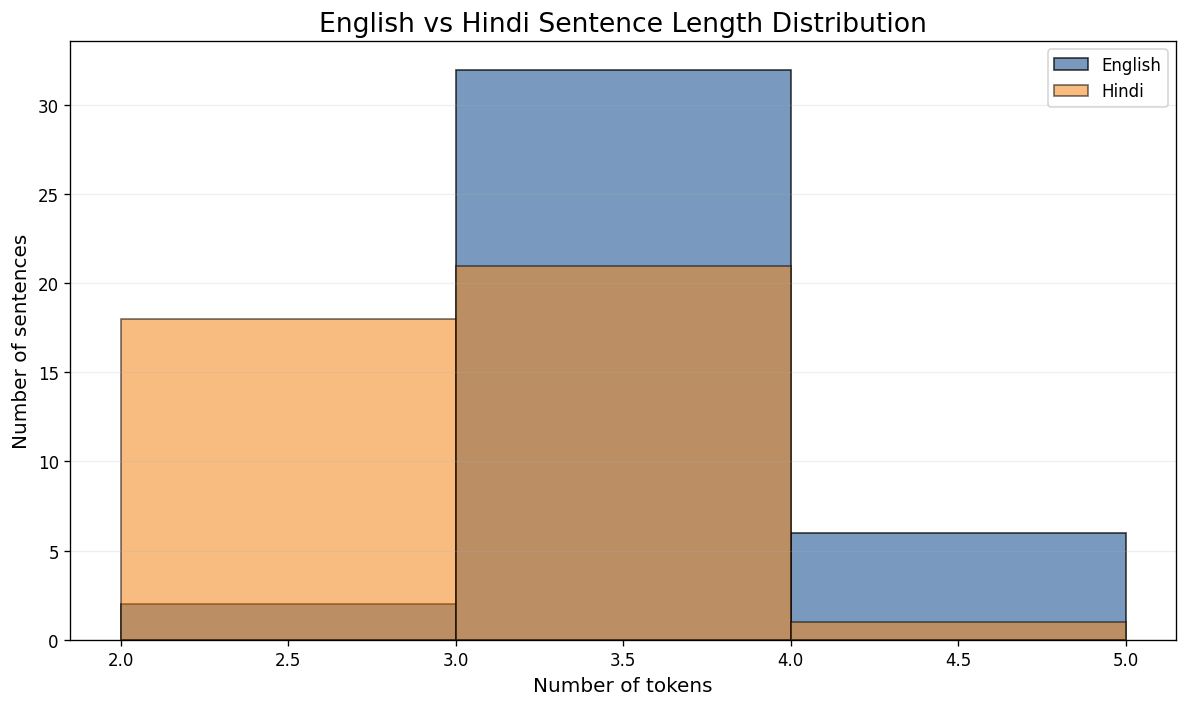

In [8]:


plt.figure(figsize=(10, 6))
bins = np.arange(
    min(df["english_len"].min(), df["hindi_len"].min()),
    max(df["english_len"].max(), df["hindi_len"].max()) + 2
)

plt.hist(df["english_len"], bins=bins, alpha=0.75,
         label="English", color="#4C78A8", edgecolor="black")
plt.hist(df["hindi_len"], bins=bins, alpha=0.55,
         label="Hindi", color="#F58518", edgecolor="black")

plt.xlabel("Number of tokens")
plt.ylabel("Number of sentences")
plt.title("English vs Hindi Sentence Length Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_9.png", dpi=180, bbox_inches="tight")
plt.show()


In [9]:


english_counts = Counter(tok for row in df["english_tokens"] for tok in row)
hindi_counts = Counter(tok for row in df["hindi_tokens"] for tok in row)

eng_freq = pd.Series(english_counts).sort_values(ascending=False).head(20)
hi_freq = pd.Series(hindi_counts).sort_values(ascending=False).head(20)

print("Top English words:")
display(eng_freq.to_frame("frequency"))

print("Top Hindi words:")
display(hi_freq.to_frame("frequency"))

Top English words:


,frequency
the,32
turn,4
open,4
door,3
close,3
window,3
on,2
light,2
off,2
stop,2


Top Hindi words:


,frequency
करो,16
बंद,8
रखो,3
दरवाज़ा,3
खोलो,3
खिड़की,3
रोशनी,2
चालू,2
पढ़ो,2
चलाओ,2


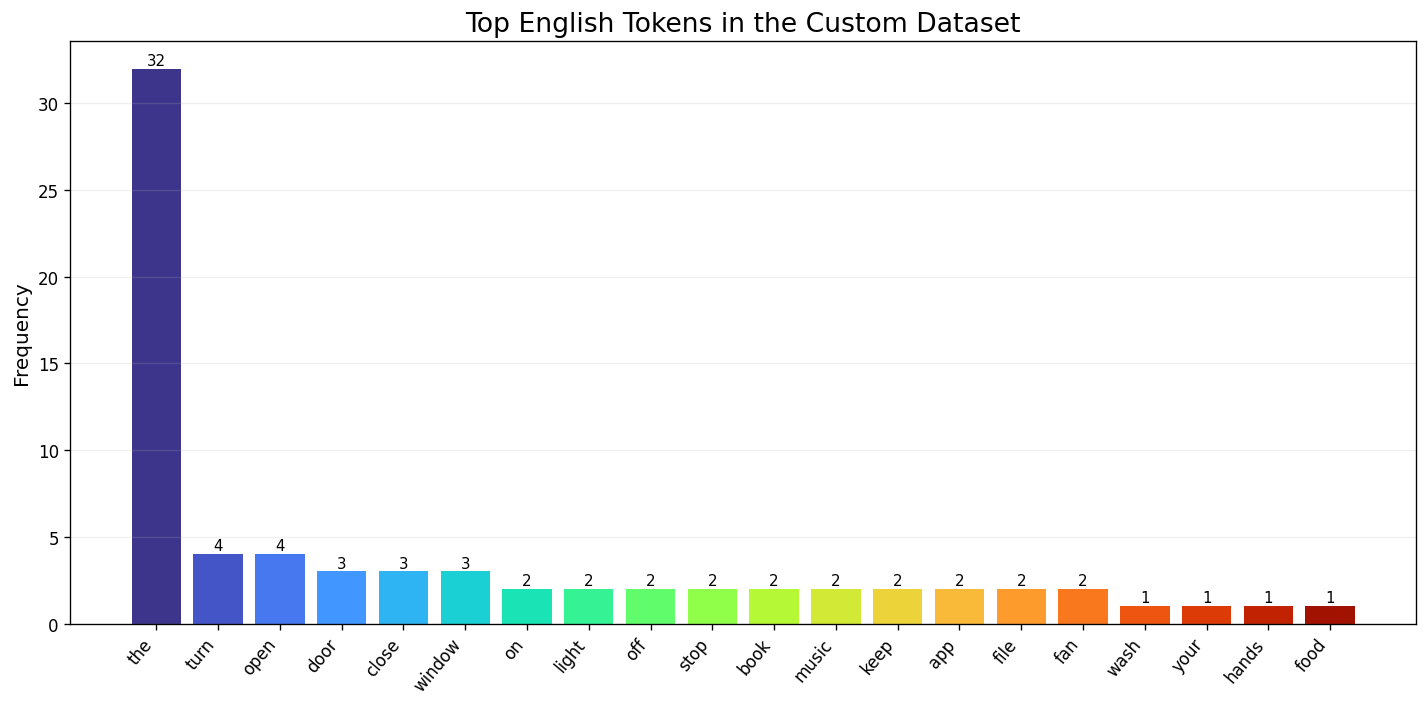

In [10]:


plt.figure(figsize=(12, 6))
colors = plt.cm.turbo(np.linspace(0.05, 0.95, len(eng_freq)))
bars = plt.bar(eng_freq.index, eng_freq.values, color=colors)

plt.xticks(rotation=50, ha="right")
plt.ylabel("Frequency")
plt.title("Top English Tokens in the Custom Dataset")
plt.grid(axis="y", alpha=0.2)

for bar, value in zip(bars, eng_freq.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.05,
        str(value),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_11.png", dpi=180, bbox_inches="tight")
plt.show()


# 2. Tokenization and vocabulary

A sequence model ultimately receives numbers, not words.

We therefore move through:

**text → tokens → token IDs → vectors**

The notebook keeps this part deliberately transparent.

In [11]:


special_tokens = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]

english_vocab = sorted(set(
    tok for row in df["english_tokens"] for tok in row
))
hindi_vocab = sorted(set(
    tok for row in df["hindi_tokens"] for tok in row
))

english_vocab_full = special_tokens + english_vocab
hindi_vocab_full = special_tokens + hindi_vocab

en_to_id = {tok: i for i, tok in enumerate(english_vocab_full)}
hi_to_id = {tok: i for i, tok in enumerate(hindi_vocab_full)}

id_to_en = {i: tok for tok, i in en_to_id.items()}
id_to_hi = {i: tok for tok, i in hi_to_id.items()}

print("English vocabulary size:", len(en_to_id))
print("Hindi vocabulary size:", len(hi_to_id))

English vocabulary size: 75
Hindi vocabulary size: 69


In [12]:


def encode_sentence(tokens, vocab):
    unk = vocab["<UNK>"]
    return [vocab.get(tok, unk) for tok in tokens]

def decode_ids(ids, reverse_vocab):
    return [reverse_vocab[i] for i in ids]

sample_tokens = df.loc[1, "english_tokens"]
sample_ids = encode_sentence(sample_tokens, en_to_id)

print("Tokens:", sample_tokens)
print("IDs   :", sample_ids)
print("Back  :", decode_ids(sample_ids, id_to_en))

Tokens: ['turn', 'off', 'the', 'light']
IDs   : [65, 42, 63, 34]
Back  : ['turn', 'off', 'the', 'light']


In [13]:


def one_hot(index, vocab_size):
    vec = np.zeros(vocab_size)
    vec[index] = 1.0
    return vec

sample_id = sample_ids[0]
sample_one_hot = one_hot(sample_id, len(en_to_id))

print("Token:", id_to_en[sample_id])
print("One-hot shape:", sample_one_hot.shape)
print("One-hot sum:", sample_one_hot.sum())
print(sample_one_hot)

Token: turn
One-hot shape: (75,)
One-hot sum: 1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]


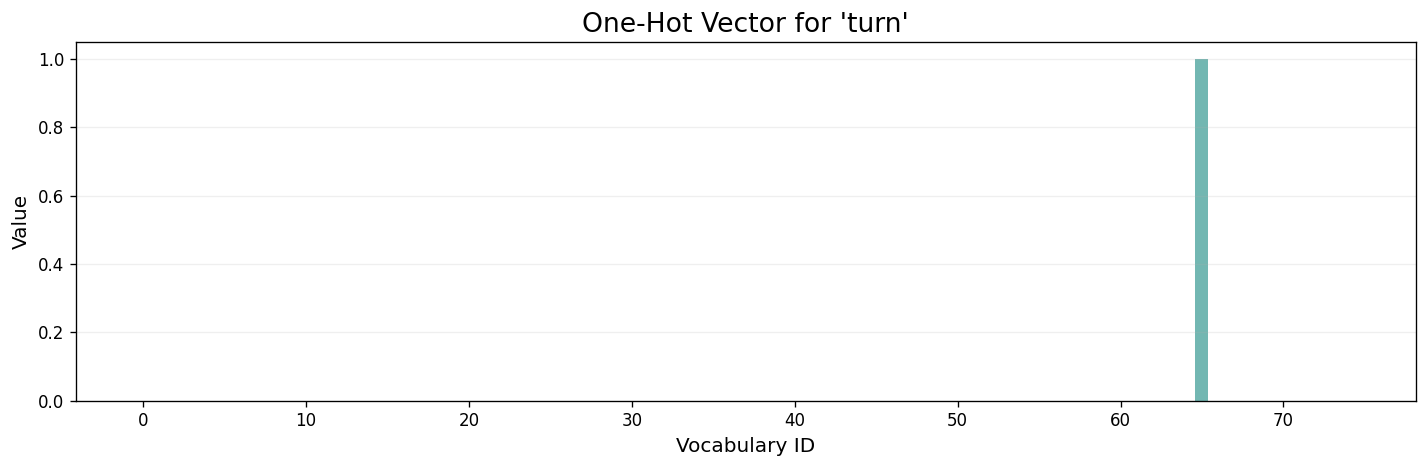

In [14]:


plt.figure(figsize=(12, 4))
plt.bar(np.arange(len(sample_one_hot)), sample_one_hot, color="#72B7B2")
plt.xlabel("Vocabulary ID")
plt.ylabel("Value")
plt.title(f"One-Hot Vector for '{id_to_en[sample_id]}'")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_16.png", dpi=180, bbox_inches="tight")
plt.show()


# 3. Embedding-style vectors

Real NLP systems normally learn dense word representations. Here we create deterministic dense vectors so we can isolate the attention mathematics.

A critical distinction:

> These are **lab representations**, not a trained translation embedding model.

In [15]:


embedding_dim = 16
rng = np.random.default_rng(42)

english_embeddings = {
    tok: rng.normal(0, 1, embedding_dim)
    for tok in english_vocab_full
}

hindi_embeddings = {
    tok: rng.normal(0, 1, embedding_dim)
    for tok in hindi_vocab_full
}

print("Embedding dimension:", embedding_dim)
print("Example English vector:")
print(np.round(english_embeddings["light"], 3))

Embedding dimension: 16
Example English vector:
[-0.253 -0.159  0.203 -1.009  0.707  0.663  0.385  0.557  0.296  2.035
 -0.087 -0.307 -0.754 -1.032 -1.244 -0.889]


In [16]:


light_vec = english_embeddings["light"]

print("L2 norm:", round(np.linalg.norm(light_vec), 4))
print("Mean   :", round(light_vec.mean(), 4))
print("Std    :", round(light_vec.std(), 4))

L2 norm: 3.2936
Mean   : -0.0555
Std    : 0.8215


In [17]:


a = np.array([1.0, 2.0, 3.0])
b = np.array([2.0, 1.0, 0.5])

dot = np.dot(a, b)

print("a · b =", dot)
print("Manual calculation =", 1*2 + 2*1 + 3*0.5)

a · b = 5.5
Manual calculation = 5.5


In [18]:


def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

print("Cosine(a,b) =", round(cosine_similarity(a, b), 4))

Cosine(a,b) = 0.6415


# 4. Encoder hidden states

The source material repeatedly describes `h1, h2, ...` as the encoder's intermediate hidden states and explains that attention keeps them available to the decoder instead of throwing them away after creating one final summary. fileciteturn0file0L132-L160

We now construct a controlled sequence of hidden states `H`.

In [19]:



semantic_dim = 16
rng = np.random.default_rng(123)

concept_map = {
    "turn": "TURN", "on": "ON", "off": "OFF",
    "light": "LIGHT", "open": "OPEN", "close": "CLOSE",
    "door": "DOOR", "read": "READ", "book": "BOOK",
    "write": "WRITE", "note": "NOTE", "drink": "DRINK",
    "water": "WATER", "eat": "EAT", "food": "FOOD",
    "wash": "WASH", "your": "YOUR", "hands": "HANDS",
    "clean": "CLEAN", "room": "ROOM", "start": "START",
    "computer": "COMPUTER", "stop": "STOP", "machine": "MACHINE",
    "charge": "CHARGE", "phone": "PHONE", "window": "WINDOW",
    "play": "PLAY", "music": "MUSIC", "watch": "WATCH",
    "movie": "MOVIE", "learn": "LEARN", "python": "PYTHON",
    "practice": "PRACTICE", "coding": "CODING", "solve": "SOLVE",
    "problem": "PROBLEM", "check": "CHECK", "email": "EMAIL",
    "send": "SEND", "message": "MESSAGE", "take": "TAKE",
    "picture": "PICTURE", "app": "APP", "save": "SAVE",
    "file": "FILE", "delete": "DELETE", "run": "RUN",
    "code": "CODE", "fix": "FIX", "error": "ERROR",
    "book": "BOOK", "ticket": "TICKET", "buy": "BUY",
    "fresh": "FRESH", "fruit": "FRUIT", "visit": "VISIT",
    "museum": "MUSEUM", "study": "STUDY", "every": "EVERY",
    "day": "DAY", "work": "WORK", "very": "VERY", "hard": "HARD",
    "keep": "KEEP", "closed": "CLOSED", "fan": "FAN",
    "make": "MAKE", "some": "SOME", "tea": "TEA", "the": "THE",
}

concept_vectors = {}
for concept in sorted(set(concept_map.values())):
    concept_vectors[concept] = rng.normal(0, 1, semantic_dim)

print("Number of semantic prototypes:", len(concept_vectors))

Number of semantic prototypes: 70


In [20]:


hindi_to_concept = {
    "रोशनी": "LIGHT", "चालू": "ON", "बंद": "OFF",
    "करो": "DO", "खोलो": "OPEN", "दरवाज़ा": "DOOR",
    "किताब": "BOOK", "पढ़ो": "READ", "नोट": "NOTE",
    "लिखो": "WRITE", "पानी": "WATER", "पियो": "DRINK",
    "खाना": "FOOD", "खाओ": "EAT", "अपने": "YOUR",
    "हाथ": "HANDS", "धोओ": "WASH", "कमरा": "ROOM",
    "साफ़": "CLEAN", "कंप्यूटर": "COMPUTER", "शुरू": "START",
    "मशीन": "MACHINE", "चार्ज": "CHARGE", "फ़ोन": "PHONE",
    "खिड़की": "WINDOW", "संगीत": "MUSIC", "चलाओ": "PLAY",
    "फ़िल्म": "MOVIE", "देखो": "WATCH", "पाइथन": "PYTHON",
    "सीखो": "LEARN", "कोडिंग": "CODING", "अभ्यास": "PRACTICE",
    "समस्या": "PROBLEM", "हल": "SOLVE", "ईमेल": "EMAIL",
    "जाँचो": "CHECK", "संदेश": "MESSAGE", "भेजो": "SEND",
    "तस्वीर": "PICTURE", "लो": "TAKE", "ऐप": "APP",
    "फ़ाइल": "FILE", "सहेजो": "SAVE", "हटाओ": "DELETE",
    "कोड": "CODE", "त्रुटि": "ERROR", "ठीक": "FIX",
    "टिकट": "TICKET", "बुक": "BOOK", "खरीदो": "BUY",
    "ताज़े": "FRESH", "फल": "FRUIT", "संग्रहालय": "MUSEUM",
    "जाओ": "VISIT", "हर": "EVERY", "दिन": "DAY",
    "मेहनत": "WORK", "बहुत": "VERY", "रखो": "KEEP",
    "खुला": "OPEN", "बनाओ": "MAKE", "चाय": "TEA",
    "पंखा": "FAN", "कुछ": "SOME", "का": "THE"
}

def get_source_vector(token):
    concept = concept_map.get(token)
    if concept in concept_vectors:
        return concept_vectors[concept]
    return np.zeros(semantic_dim)

def get_target_vector(token):
    concept = hindi_to_concept.get(token)
    if concept in concept_vectors:
        return concept_vectors[concept]
    return np.zeros(semantic_dim)

In [21]:


def make_encoder_states(tokens, noise_scale=0.025):
    states = []
    for j, tok in enumerate(tokens):
        base = get_source_vector(tok)


        pos = np.sin((j + 1) * np.linspace(0.1, 1.4, semantic_dim))

        noise = rng.normal(0, noise_scale, semantic_dim)

        h_j = base + 0.12 * pos + noise
        states.append(h_j)

    return np.vstack(states)

sample_source = df.loc[1, "english_tokens"]
H = make_encoder_states(sample_source)

print("Source:", sample_source)
print("H shape:", H.shape)

Source: ['turn', 'off', 'the', 'light']
H shape: (4, 16)


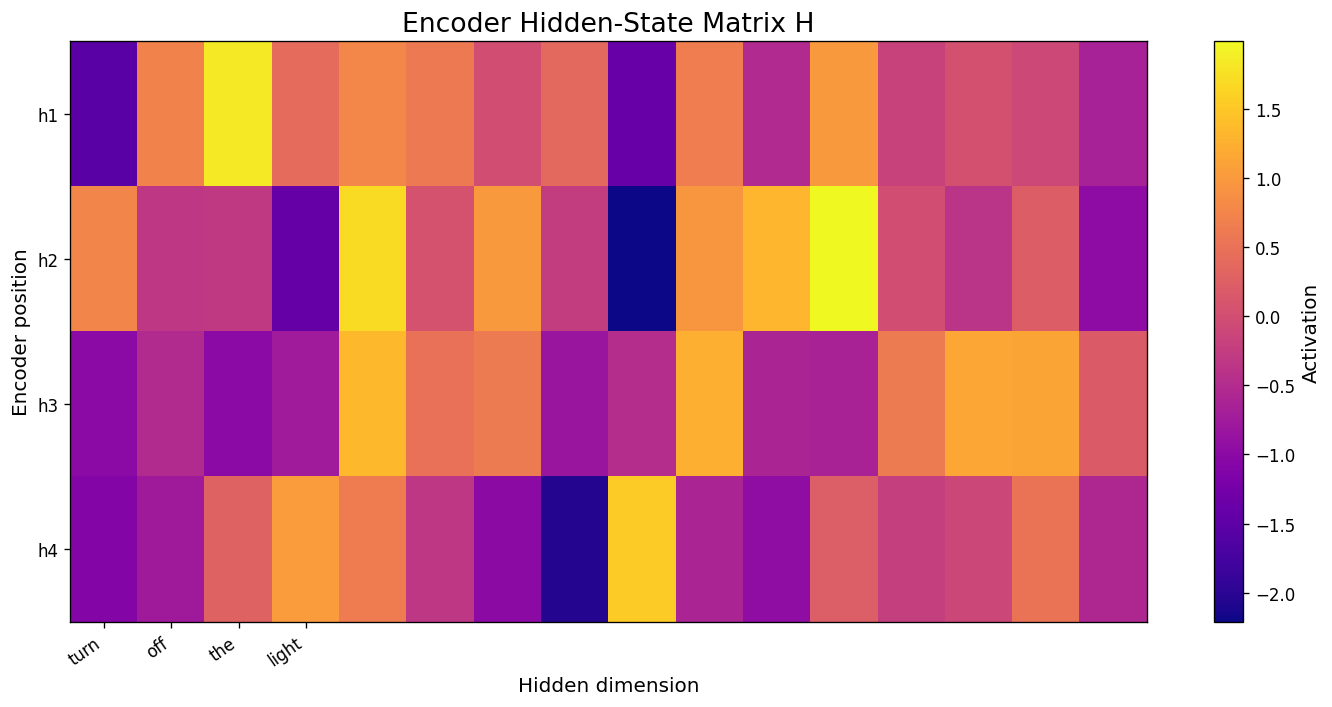

In [22]:


plt.figure(figsize=(12, 6))
im = plt.imshow(H, cmap="plasma", aspect="auto")
plt.xticks(range(len(sample_source)), sample_source, rotation=35, ha="right")
plt.yticks(range(H.shape[0]), [f"h{i+1}" for i in range(H.shape[0])])
plt.xlabel("Hidden dimension")
plt.ylabel("Encoder position")
plt.title("Encoder Hidden-State Matrix H")
plt.colorbar(im, label="Activation")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_26.png", dpi=180, bbox_inches="tight")
plt.show()


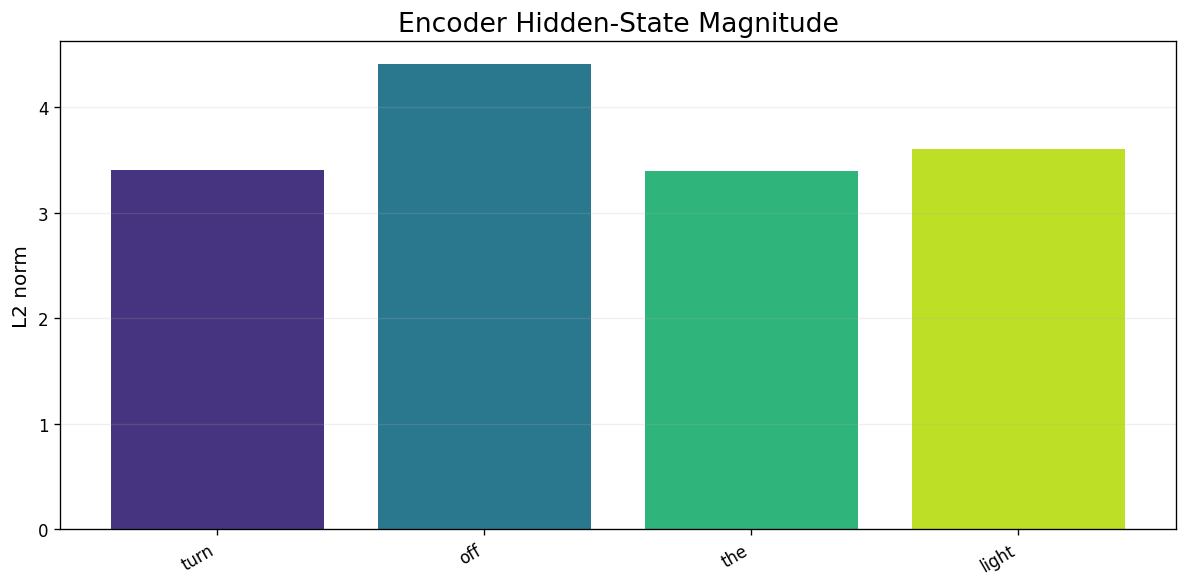

In [23]:


norms = np.linalg.norm(H, axis=1)

plt.figure(figsize=(10, 5))
bars = plt.bar(sample_source, norms, color=plt.cm.viridis(
    np.linspace(0.15, 0.9, len(norms))
))

plt.xticks(rotation=30, ha="right")
plt.ylabel("L2 norm")
plt.title("Encoder Hidden-State Magnitude")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_27.png", dpi=180, bbox_inches="tight")
plt.show()


# 5. Decoder states

For the target side we generate controlled decoder representations.

In classic Bahdanau-style scoring, the material describes alignment as depending on the encoder hidden state and the **previous decoder hidden state**. fileciteturn0file0L293-L343

In classic Luong dot-product attention, the material describes using the **current decoder hidden state** for scoring. fileciteturn0file0L738-L747

In [24]:


def make_decoder_states(tokens, noise_scale=0.025):
    states = []

    for i, tok in enumerate(tokens):
        base = get_target_vector(tok)
        pos = np.cos((i + 1) * np.linspace(0.1, 1.25, semantic_dim))
        noise = rng.normal(0, noise_scale, semantic_dim)

        s_i = base + 0.12 * pos + noise
        states.append(s_i)

    return np.vstack(states)

sample_target = df.loc[1, "hindi_tokens"]
S = make_decoder_states(sample_target)

print("Target:", sample_target)
print("S shape:", S.shape)

Target: ['रोशनी', 'बंद', 'करो']
S shape: (3, 16)


/tmp/ipykernel_814/939943012.py:9: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/939943012.py:9: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/939943012.py:9: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/939943012.py:9: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/939943012.py:9: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/939943012.py:9: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/939943012.py:9: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814

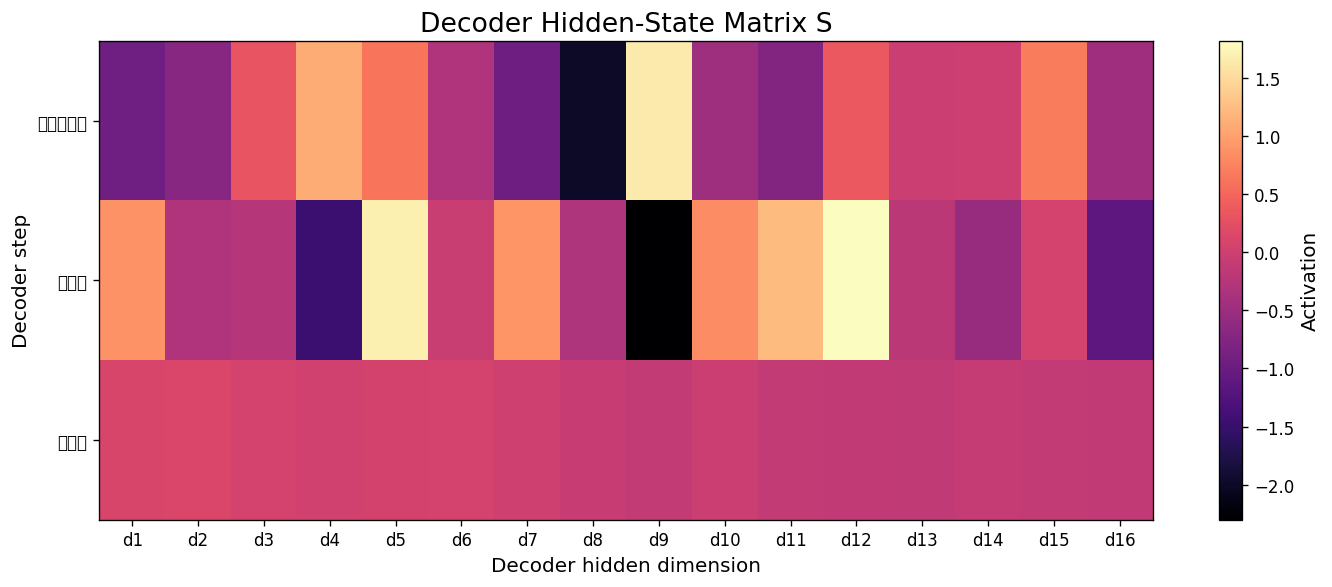

In [25]:


plt.figure(figsize=(12, 5))
im = plt.imshow(S, cmap="magma", aspect="auto")
plt.xticks(range(S.shape[1]), [f"d{k+1}" for k in range(S.shape[1])])
plt.yticks(range(len(sample_target)), sample_target)
plt.xlabel("Decoder hidden dimension")
plt.ylabel("Decoder step")
plt.title("Decoder Hidden-State Matrix S")
plt.colorbar(im, label="Activation")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_30.png", dpi=180, bbox_inches="tight")
plt.show()


# 6. Softmax from scratch

Before implementing attention, we isolate the normalization step.

The core formula is:

`softmax(e_j) = exp(e_j) / sum(exp(e_k))`

This is the exact step that turns alignment scores into the `alpha` attention weights.

In [26]:


def softmax_naive(x):
    x = np.asarray(x)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

scores = np.array([1.0, 2.0, 3.0])
print(softmax_naive(scores))

[0.09003057 0.24472847 0.66524096]


In [27]:


def softmax_stable(x, temperature=1.0, axis=-1):
    x = np.asarray(x, dtype=float) / temperature
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

stable = softmax_stable(scores)
print(stable)
print("Sum:", stable.sum())

[0.09003057 0.24472847 0.66524096]
Sum: 0.9999999999999999


In [28]:


large_scores = np.array([1000.0, 1001.0, 1002.0])

print("Stable softmax:", softmax_stable(large_scores))
print("Sum:", softmax_stable(large_scores).sum())

Stable softmax: [0.09003057 0.24472847 0.66524096]
Sum: 0.9999999999999999


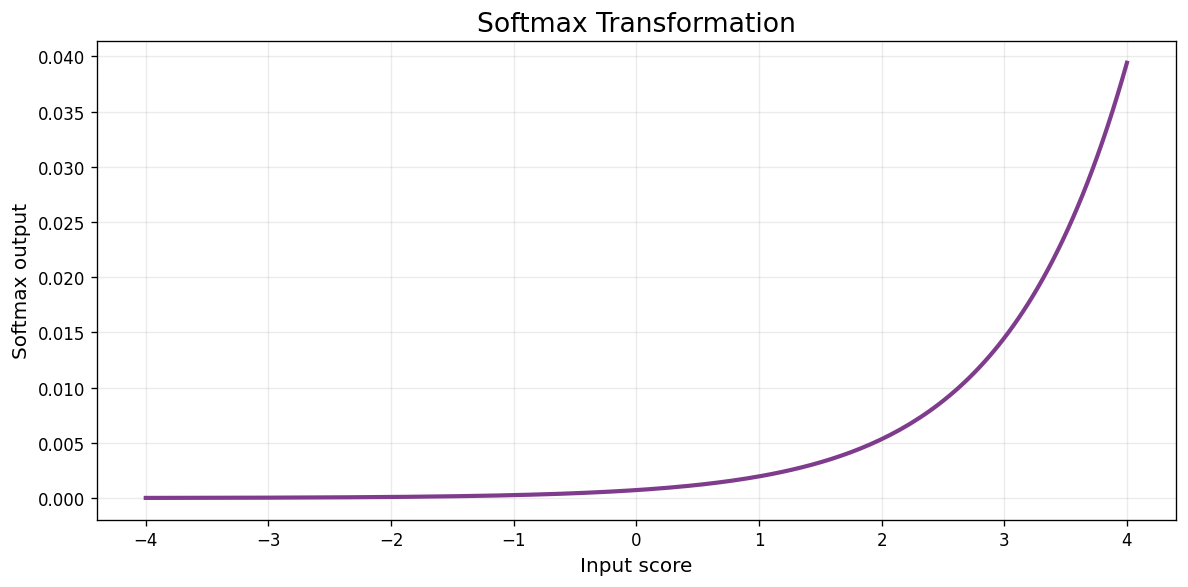

In [29]:


score_grid = np.linspace(-4, 4, 200)
weights = softmax_stable(score_grid)

plt.figure(figsize=(10, 5))
plt.plot(score_grid, weights, linewidth=2.5, color="#7F3C8D")
plt.xlabel("Input score")
plt.ylabel("Softmax output")
plt.title("Softmax Transformation")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_35.png", dpi=180, bbox_inches="tight")
plt.show()


# 7. Bahdanau Attention — build it one step at a time

The source presents Bahdanau alignment as a learned feed-forward function operating on encoder and decoder representations, followed by softmax and then a weighted sum of encoder hidden states. fileciteturn0file0L349-L381

We implement each stage separately so there is no “black box”.

In [30]:


def initialize_bahdanau(hidden_dim, alignment_dim=24, seed=7):
    local_rng = np.random.default_rng(seed)

    W_h = local_rng.normal(0, 0.22, size=(alignment_dim, hidden_dim))
    W_s = local_rng.normal(0, 0.22, size=(alignment_dim, hidden_dim))
    b = np.zeros(alignment_dim)

    v = local_rng.normal(0, 0.22, size=(alignment_dim,))

    return W_h, W_s, b, v

W_h, W_s, b, v = initialize_bahdanau(semantic_dim)

print("W_h:", W_h.shape)
print("W_s:", W_s.shape)
print("b  :", b.shape)
print("v  :", v.shape)

W_h: (24, 16)
W_s: (24, 16)
b  : (24,)
v  : (24,)


In [31]:


def bahdanau_score(h_j, s_prev, W_h, W_s, b, v):
    z = W_h @ h_j + W_s @ s_prev + b
    hidden = np.tanh(z)
    score = np.dot(v, hidden)
    return float(score), z, hidden

s_prev = S[0]
score, z, alignment_hidden = bahdanau_score(
    H[0], s_prev, W_h, W_s, b, v
)

print("Raw score e_11:", score)
print("Intermediate z shape:", z.shape)
print("Nonlinear representation shape:", alignment_hidden.shape)

Raw score e_11: 0.07564238687122249
Intermediate z shape: (24,)
Nonlinear representation shape: (24,)


In [32]:


def bahdanau_scores_one_step(H, s_prev, W_h, W_s, b, v):
    result = []
    for h_j in H:
        score, _, _ = bahdanau_score(h_j, s_prev, W_h, W_s, b, v)
        result.append(score)
    return np.array(result)

raw_bah_step1 = bahdanau_scores_one_step(
    H, S[0], W_h, W_s, b, v
)

display(pd.DataFrame({
    "source_token": sample_source,
    "e_1j": raw_bah_step1
}).round(4))

,source_token,e_1j
0,turn,0.0756
1,off,-0.2967
2,the,-0.7259
3,light,-0.2550


In [33]:


alpha_bah_step1 = softmax_stable(raw_bah_step1)

display(pd.DataFrame({
    "source_token": sample_source,
    "attention_weight": alpha_bah_step1
}).round(4))

print("Weight sum:", alpha_bah_step1.sum())

,source_token,attention_weight
0,turn,0.3501
1,off,0.2413
2,the,0.1571
3,light,0.2516


Weight sum: 1.0


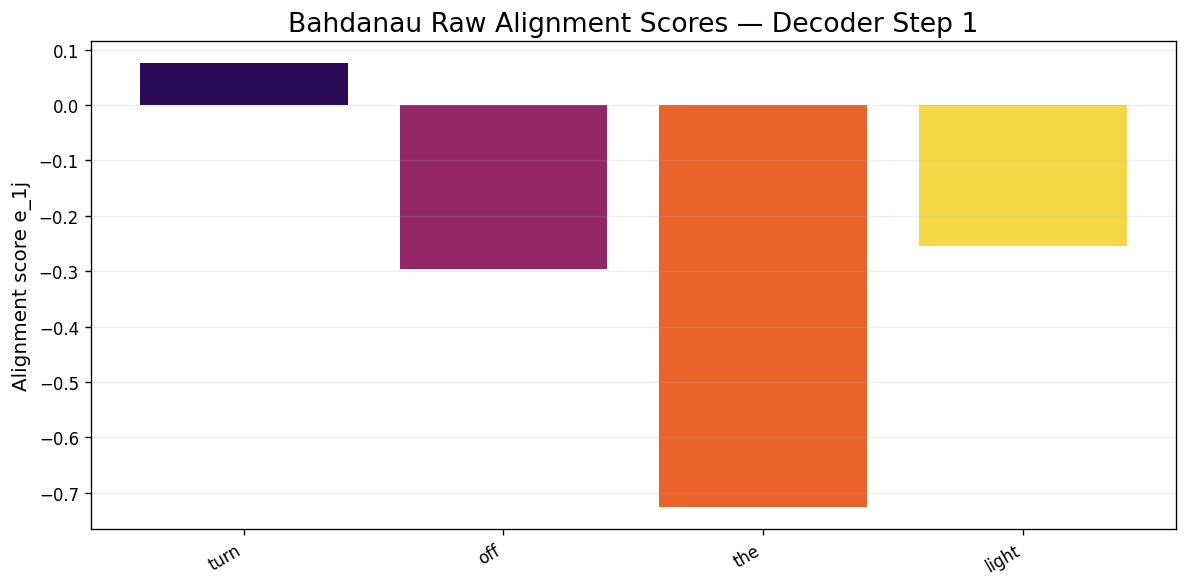

In [34]:


plt.figure(figsize=(10, 5))
bars = plt.bar(
    sample_source,
    raw_bah_step1,
    color=plt.cm.inferno(
        np.linspace(0.15, 0.9, len(raw_bah_step1))
    )
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Alignment score e_1j")
plt.title("Bahdanau Raw Alignment Scores — Decoder Step 1")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_41.png", dpi=180, bbox_inches="tight")
plt.show()


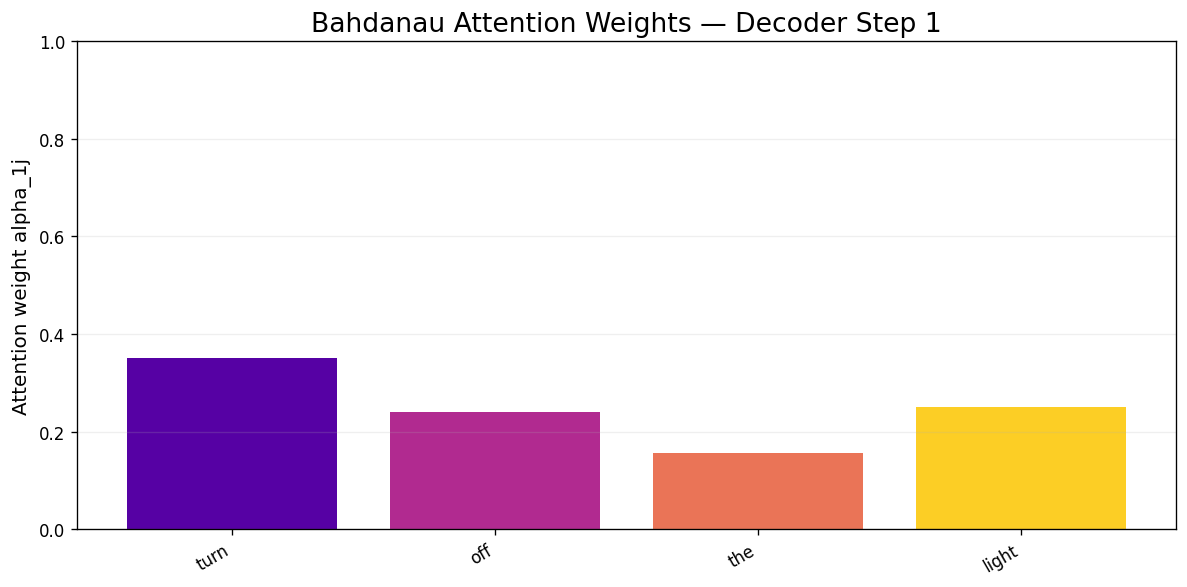

In [35]:


plt.figure(figsize=(10, 5))
bars = plt.bar(
    sample_source,
    alpha_bah_step1,
    color=plt.cm.plasma(
        np.linspace(0.15, 0.9, len(alpha_bah_step1))
    )
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Attention weight alpha_1j")
plt.ylim(0, 1)
plt.title("Bahdanau Attention Weights — Decoder Step 1")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_42.png", dpi=180, bbox_inches="tight")
plt.show()


In [36]:


c1_bah_manual = np.sum(
    alpha_bah_step1[:, None] * H,
    axis=0
)

c1_bah_matrix = alpha_bah_step1 @ H

print("Manual weighted-sum vector:")
print(np.round(c1_bah_manual, 4))

print("\nMatrix multiplication result:")
print(np.round(c1_bah_matrix, 4))

print("\nDifference:",
      np.max(np.abs(c1_bah_manual - c1_bah_matrix)))

Manual weighted-sum vector:
[-0.7891 -0.0997  0.4845 -0.0542  1.052   0.2206  0.0867 -0.5729 -0.7136
  0.505  -0.1996  0.7844 -0.0147  0.0822  0.3326 -0.5784]

Matrix multiplication result:
[-0.7891 -0.0997  0.4845 -0.0542  1.052   0.2206  0.0867 -0.5729 -0.7136
  0.505  -0.1996  0.7844 -0.0147  0.0822  0.3326 -0.5784]

Difference: 2.220446049250313e-16


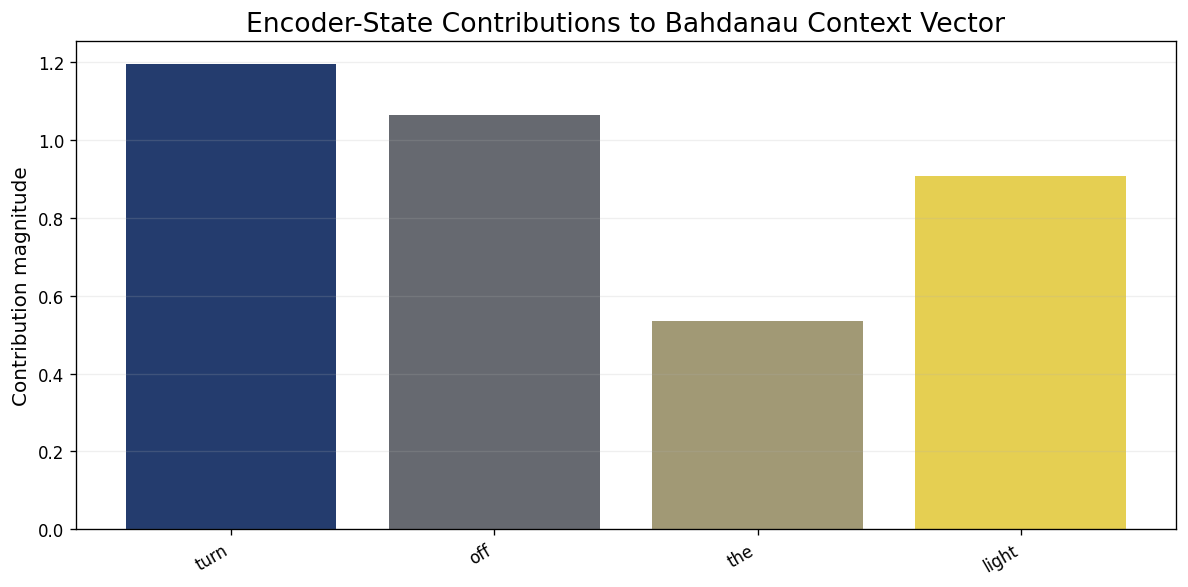

In [37]:


contributions = alpha_bah_step1[:, None] * H

contrib_norms = np.linalg.norm(contributions, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(
    sample_source,
    contrib_norms,
    color=plt.cm.cividis(
        np.linspace(0.15, 0.9, len(contrib_norms))
    )
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Contribution magnitude")
plt.title("Encoder-State Contributions to Bahdanau Context Vector")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_44.png", dpi=180, bbox_inches="tight")
plt.show()


In [38]:


def bahdanau_attention(H, S_prev, alignment_dim=24,
                       temperature=1.0, seed=7):
    hidden_dim = H.shape[1]
    W_h, W_s, b, v = initialize_bahdanau(
        hidden_dim, alignment_dim=alignment_dim, seed=seed
    )

    scores = np.zeros((S_prev.shape[0], H.shape[0]))

    for i, s_prev in enumerate(S_prev):
        for j, h_j in enumerate(H):
            scores[i, j], _, _ = bahdanau_score(
                h_j, s_prev, W_h, W_s, b, v
            )

    alpha = softmax_stable(
        scores, temperature=temperature, axis=1
    )

    context = alpha @ H

    return scores, alpha, context

bah_scores, bah_alpha, bah_context = bahdanau_attention(
    H, S, alignment_dim=24
)

print("Bahdanau scores:", bah_scores.shape)
print("Bahdanau alpha :", bah_alpha.shape)
print("Context        :", bah_context.shape)

Bahdanau scores: (3, 4)
Bahdanau alpha : (3, 4)
Context        : (3, 16)


# 8. Luong Attention

The source describes Luong attention as a simpler alignment computation based on the current decoder state and encoder state, using dot-product similarity in the simplest version. fileciteturn0file0L738-L780

We implement three useful forms:

1. **Dot**
2. **General**
3. **Concat-style**

The core notebook comparison will use **dot-product Luong attention**.

In [39]:


def luong_dot_score(s_i, h_j):
    return float(np.dot(s_i, h_j))

one_luong_score = luong_dot_score(S[0], H[0])
print("Luong e_11 =", round(one_luong_score, 5))

Luong e_11 = -0.08189


In [40]:


def luong_dot_scores_one_step(H, s_i):
    return np.array([
        luong_dot_score(s_i, h_j)
        for h_j in H
    ])

raw_luong_step1 = luong_dot_scores_one_step(H, S[0])

display(pd.DataFrame({
    "source_token": sample_source,
    "dot_product_score": raw_luong_step1
}).round(4))

,source_token,dot_product_score
0,turn,-0.0819
1,off,-5.3319
2,the,1.4461
3,light,12.6033


In [41]:


alpha_luong_step1 = softmax_stable(raw_luong_step1)

display(pd.DataFrame({
    "source_token": sample_source,
    "attention_weight": alpha_luong_step1
}).round(4))

print("Weight sum:", alpha_luong_step1.sum())

,source_token,attention_weight
0,turn,0.0
1,off,0.0
2,the,0.0
3,light,1.0


Weight sum: 1.0


In [42]:


c1_luong = alpha_luong_step1 @ H

print("Luong context vector:")
print(np.round(c1_luong, 4))

Luong context vector:
[-1.0852 -0.7587  0.2971  1.0391  0.6424 -0.3383 -0.9949 -2.0489  1.5387
 -0.6074 -0.9509  0.2269 -0.2216 -0.1049  0.5277 -0.5551]


In [43]:


def initialize_luong_general(hidden_dim, seed=13):
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(0, 0.20, size=(hidden_dim, hidden_dim))
    return W

W_luong = initialize_luong_general(semantic_dim)

def luong_general_score(s_i, h_j, W):
    return float(s_i @ W @ h_j)

general_scores_step1 = np.array([
    luong_general_score(S[0], h, W_luong)
    for h in H
])

print(np.round(general_scores_step1, 4))

[-2.4552 -7.8892 -0.7495  2.576 ]


In [44]:


def initialize_luong_concat(hidden_dim, alignment_dim=24, seed=17):
    local_rng = np.random.default_rng(seed)
    W = local_rng.normal(
        0, 0.20, size=(alignment_dim, hidden_dim * 2)
    )
    v = local_rng.normal(0, 0.20, size=(alignment_dim,))
    return W, v

W_concat, v_concat = initialize_luong_concat(semantic_dim)

def luong_concat_score(s_i, h_j, W, v):
    combined = np.concatenate([s_i, h_j])
    return float(v @ np.tanh(W @ combined))

concat_scores_step1 = np.array([
    luong_concat_score(S[0], h, W_concat, v_concat)
    for h in H
])

print(np.round(concat_scores_step1, 4))

[-0.2552 -0.5041 -0.1291  0.6211]


In [45]:


variant_df = pd.DataFrame({
    "source_token": sample_source,
    "dot": raw_luong_step1,
    "general": general_scores_step1,
    "concat": concat_scores_step1
})

display(variant_df.round(4))

,source_token,dot,general,concat
0,turn,-0.0819,-2.4552,-0.2552
1,off,-5.3319,-7.8892,-0.5041
2,the,1.4461,-0.7495,-0.1291
3,light,12.6033,2.5760,0.6211


In [46]:


def luong_attention(H, S_current, temperature=1.0, scale=False):
    scores = S_current @ H.T

    if scale:
        scores = scores / np.sqrt(H.shape[1])

    alpha = softmax_stable(
        scores,
        temperature=temperature,
        axis=1
    )

    context = alpha @ H

    return scores, alpha, context

luo_scores, luo_alpha, luo_context = luong_attention(
    H, S, scale=True
)

print("Scores :", luo_scores.shape)
print("Alpha  :", luo_alpha.shape)
print("Context:", luo_context.shape)

Scores : (3, 4)
Alpha  : (3, 4)
Context: (3, 16)


# 9. The complete attention pipeline

For both mechanisms the structural pipeline is the same:

**alignment score**
→ **softmax**
→ **attention distribution**
→ **weighted encoder states**
→ **context vector**

The major difference is the **scoring function**.

In [47]:


bah_row_sums = bah_alpha.sum(axis=1)
luo_row_sums = luo_alpha.sum(axis=1)

print("Bahdanau row sums:", np.round(bah_row_sums, 6))
print("Luong row sums   :", np.round(luo_row_sums, 6))

assert np.allclose(bah_row_sums, 1.0)
assert np.allclose(luo_row_sums, 1.0)

print("✓ All attention rows sum to 1.")

Bahdanau row sums: [1. 1. 1.]
Luong row sums   : [1. 1. 1.]
✓ All attention rows sum to 1.


In [48]:


assert np.all(bah_alpha >= 0)
assert np.all(luo_alpha >= 0)

print("✓ Bahdanau weights are non-negative.")
print("✓ Luong weights are non-negative.")

✓ Bahdanau weights are non-negative.
✓ Luong weights are non-negative.


In [49]:


bah_table = pd.DataFrame(
    bah_alpha,
    index=sample_target,
    columns=sample_source
)

luo_table = pd.DataFrame(
    luo_alpha,
    index=sample_target,
    columns=sample_source
)

print("Bahdanau:")
display(bah_table.round(3))

print("Luong:")
display(luo_table.round(3))

Bahdanau:


,turn,off,the,light
रोशनी,0.350,0.241,0.157,0.252
बंद,0.399,0.257,0.175,0.169
करो,0.400,0.268,0.130,0.201


Luong:


,turn,off,the,light
रोशनी,0.038,0.010,0.055,0.897
बंद,0.022,0.959,0.017,0.002
करो,0.267,0.252,0.232,0.249


/tmp/ipykernel_814/3354154834.py:29: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3354154834.py:29: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/3354154834.py:29: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3354154834.py:29: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3354154834.py:29: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3354154834.py:29: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3354154834.py:29: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

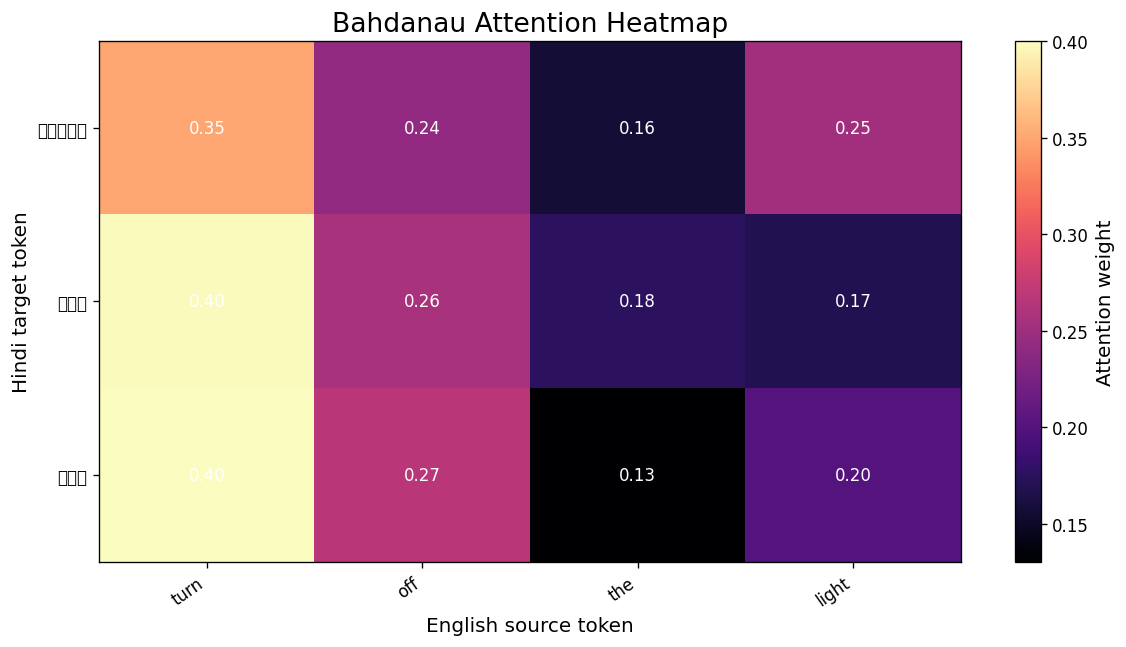

In [50]:


plt.figure(figsize=(10, 5.5))
im = plt.imshow(bah_alpha, cmap="magma", aspect="auto")

plt.xticks(
    np.arange(len(sample_source)),
    sample_source,
    rotation=35,
    ha="right"
)
plt.yticks(
    np.arange(len(sample_target)),
    sample_target
)

plt.xlabel("English source token")
plt.ylabel("Hindi target token")
plt.title("Bahdanau Attention Heatmap")
plt.colorbar(im, label="Attention weight")

for i in range(bah_alpha.shape[0]):
    for j in range(bah_alpha.shape[1]):
        plt.text(
            j, i, f"{bah_alpha[i,j]:.2f}",
            ha="center", va="center",
            color="white" if bah_alpha[i,j] < 0.55 else "black",
            fontsize=10
        )

plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_59.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_814/1513297602.py:29: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1513297602.py:29: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/1513297602.py:29: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1513297602.py:29: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1513297602.py:29: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1513297602.py:29: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1513297602.py:29: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

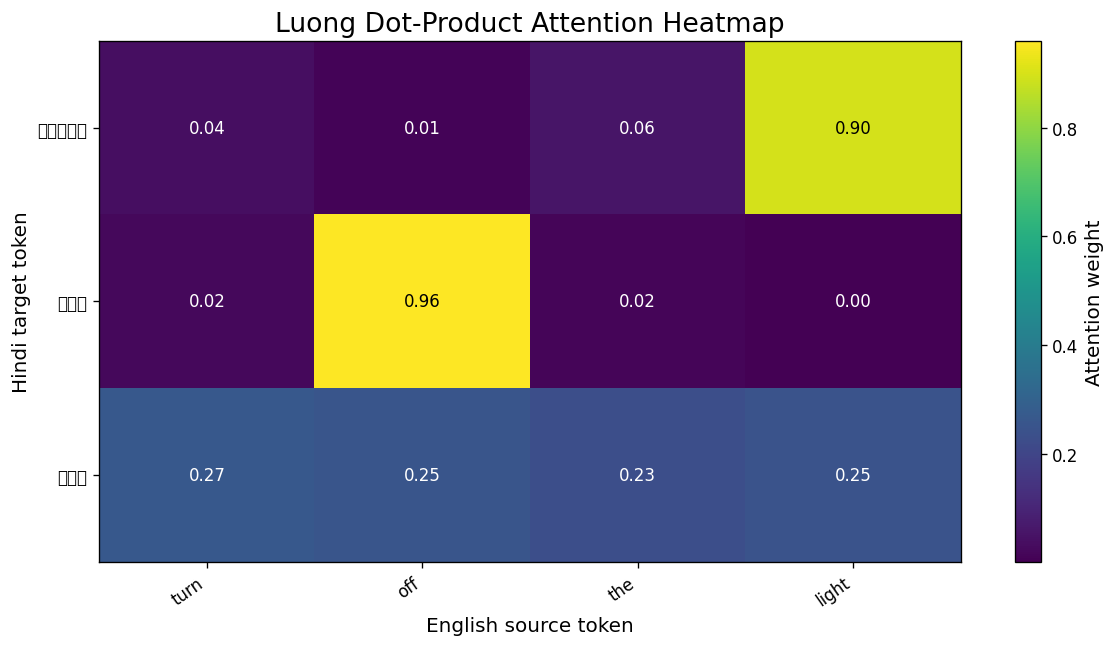

In [51]:


plt.figure(figsize=(10, 5.5))
im = plt.imshow(luo_alpha, cmap="viridis", aspect="auto")

plt.xticks(
    np.arange(len(sample_source)),
    sample_source,
    rotation=35,
    ha="right"
)
plt.yticks(
    np.arange(len(sample_target)),
    sample_target
)

plt.xlabel("English source token")
plt.ylabel("Hindi target token")
plt.title("Luong Dot-Product Attention Heatmap")
plt.colorbar(im, label="Attention weight")

for i in range(luo_alpha.shape[0]):
    for j in range(luo_alpha.shape[1]):
        plt.text(
            j, i, f"{luo_alpha[i,j]:.2f}",
            ha="center", va="center",
            color="white" if luo_alpha[i,j] < 0.55 else "black",
            fontsize=10
        )

plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_60.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_814/1628349687.py:19: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1628349687.py:19: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/1628349687.py:19: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1628349687.py:19: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1628349687.py:19: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1628349687.py:19: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1628349687.py:19: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

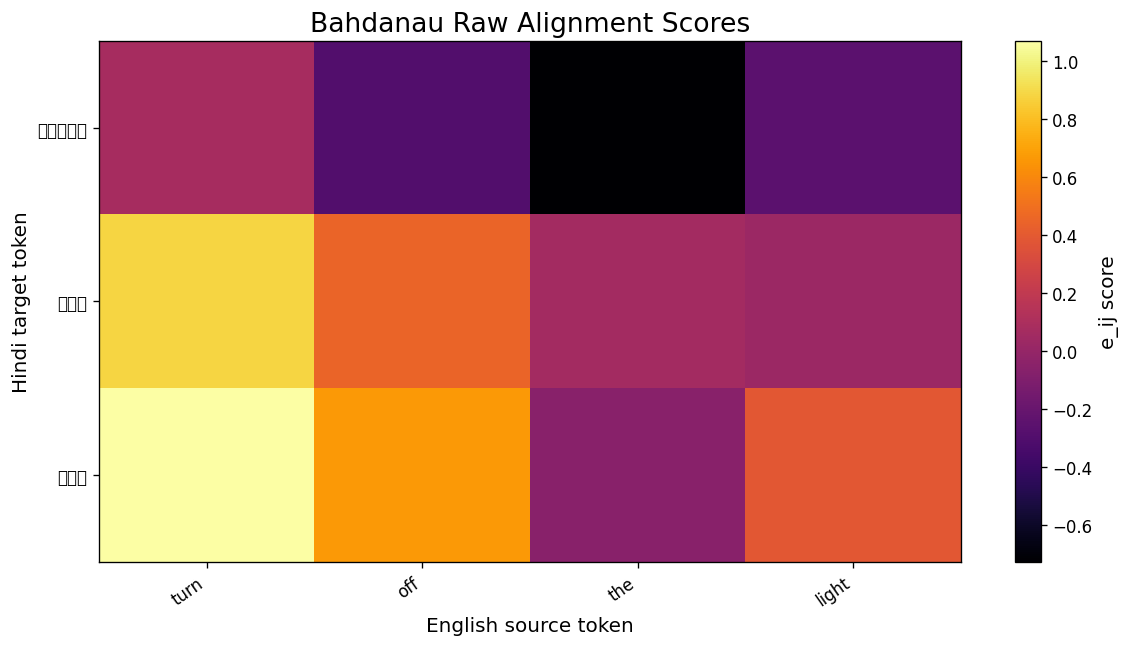

In [52]:


plt.figure(figsize=(10, 5.5))
im = plt.imshow(bah_scores, cmap="inferno", aspect="auto")

plt.xticks(
    np.arange(len(sample_source)),
    sample_source,
    rotation=35,
    ha="right"
)
plt.yticks(
    np.arange(len(sample_target)),
    sample_target
)

plt.xlabel("English source token")
plt.ylabel("Hindi target token")
plt.title("Bahdanau Raw Alignment Scores")
plt.colorbar(im, label="e_ij score")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_61.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_814/296735619.py:19: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/296735619.py:19: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/296735619.py:19: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/296735619.py:19: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/296735619.py:19: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/296735619.py:19: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/296735619.py:19: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyker

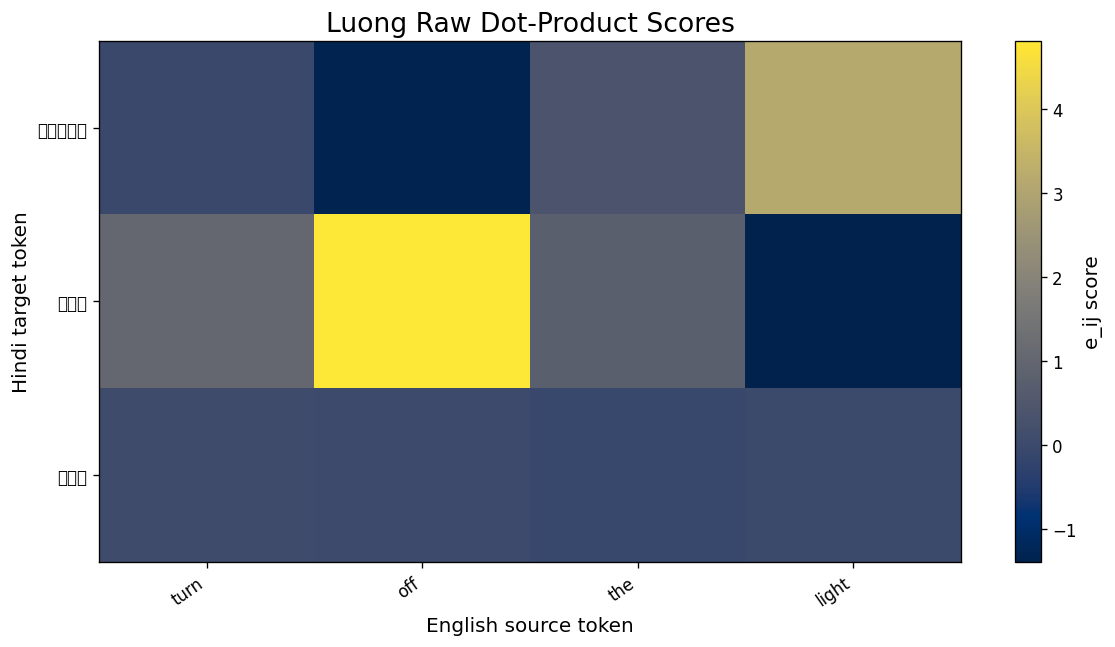

In [53]:


plt.figure(figsize=(10, 5.5))
im = plt.imshow(luo_scores, cmap="cividis", aspect="auto")

plt.xticks(
    np.arange(len(sample_source)),
    sample_source,
    rotation=35,
    ha="right"
)
plt.yticks(
    np.arange(len(sample_target)),
    sample_target
)

plt.xlabel("English source token")
plt.ylabel("Hindi target token")
plt.title("Luong Raw Dot-Product Scores")
plt.colorbar(im, label="e_ij score")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_62.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_814/2630129289.py:37: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2630129289.py:37: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/2630129289.py:37: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2630129289.py:37: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2630129289.py:37: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2630129289.py:37: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2630129289.py:37: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

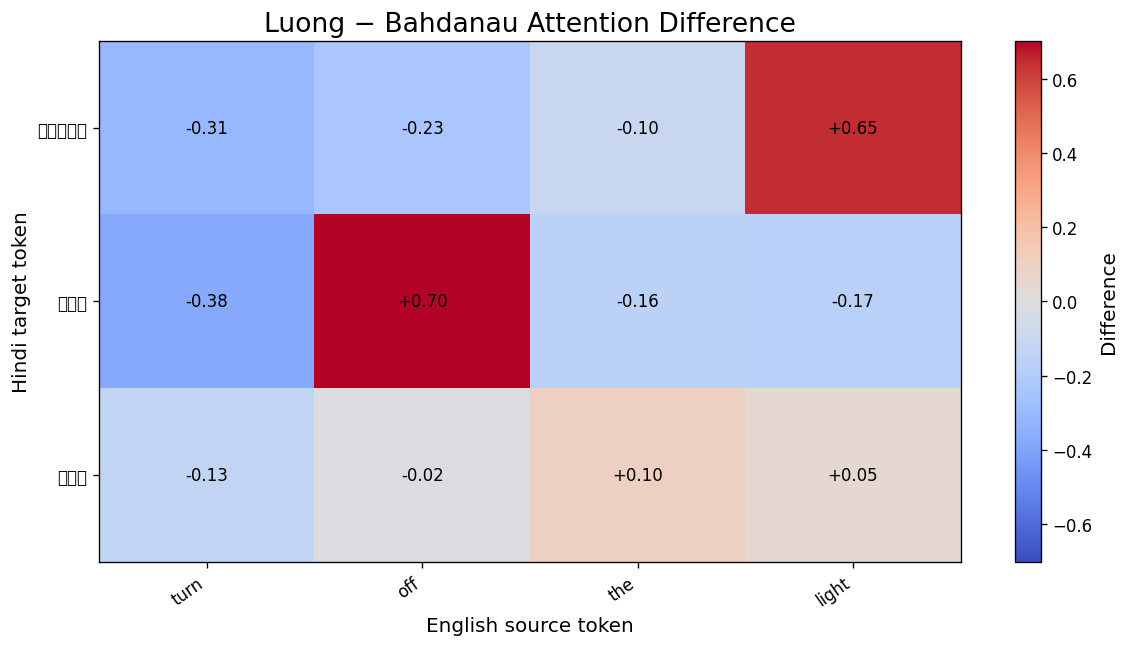

In [54]:


delta = luo_alpha - bah_alpha
limit = np.max(np.abs(delta))

plt.figure(figsize=(10, 5.5))
im = plt.imshow(
    delta,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
    aspect="auto"
)

plt.xticks(
    np.arange(len(sample_source)),
    sample_source,
    rotation=35,
    ha="right"
)
plt.yticks(
    np.arange(len(sample_target)),
    sample_target
)

plt.xlabel("English source token")
plt.ylabel("Hindi target token")
plt.title("Luong − Bahdanau Attention Difference")
plt.colorbar(im, label="Difference")

for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        plt.text(
            j, i, f"{delta[i,j]:+.2f}",
            ha="center", va="center",
            fontsize=10
        )

plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_63.png", dpi=180, bbox_inches="tight")
plt.show()


# 10. Alignment extraction

A useful practical operation is:

> For each output token, which source token currently has the maximum attention weight?

This is **argmax alignment**. It is not a perfect translation alignment algorithm, but it is a very useful diagnostic.

In [55]:


def top_alignment(alpha, source_tokens, target_tokens):
    rows = []

    for i, target in enumerate(target_tokens):
        j = int(np.argmax(alpha[i]))
        rows.append({
            "target_token": target,
            "best_source_token": source_tokens[j],
            "weight": alpha[i, j]
        })

    return pd.DataFrame(rows)

print("Bahdanau alignment:")
display(top_alignment(
    bah_alpha, sample_source, sample_target
).round(3))

print("Luong alignment:")
display(top_alignment(
    luo_alpha, sample_source, sample_target
).round(3))

Bahdanau alignment:


,target_token,best_source_token,weight
0,रोशनी,turn,0.350
1,बंद,turn,0.399
2,करो,turn,0.400


Luong alignment:


,target_token,best_source_token,weight
0,रोशनी,light,0.897
1,बंद,off,0.959
2,करो,turn,0.267


In [56]:


bah_source_importance = bah_alpha.sum(axis=0)
luo_source_importance = luo_alpha.sum(axis=0)

comparison_importance = pd.DataFrame({
    "source_token": sample_source,
    "Bahdanau_total_weight": bah_source_importance,
    "Luong_total_weight": luo_source_importance
})

display(comparison_importance.round(3))

,source_token,Bahdanau_total_weight,Luong_total_weight
0,turn,1.149,0.327
1,off,0.767,1.222
2,the,0.462,0.304
3,light,0.622,1.148


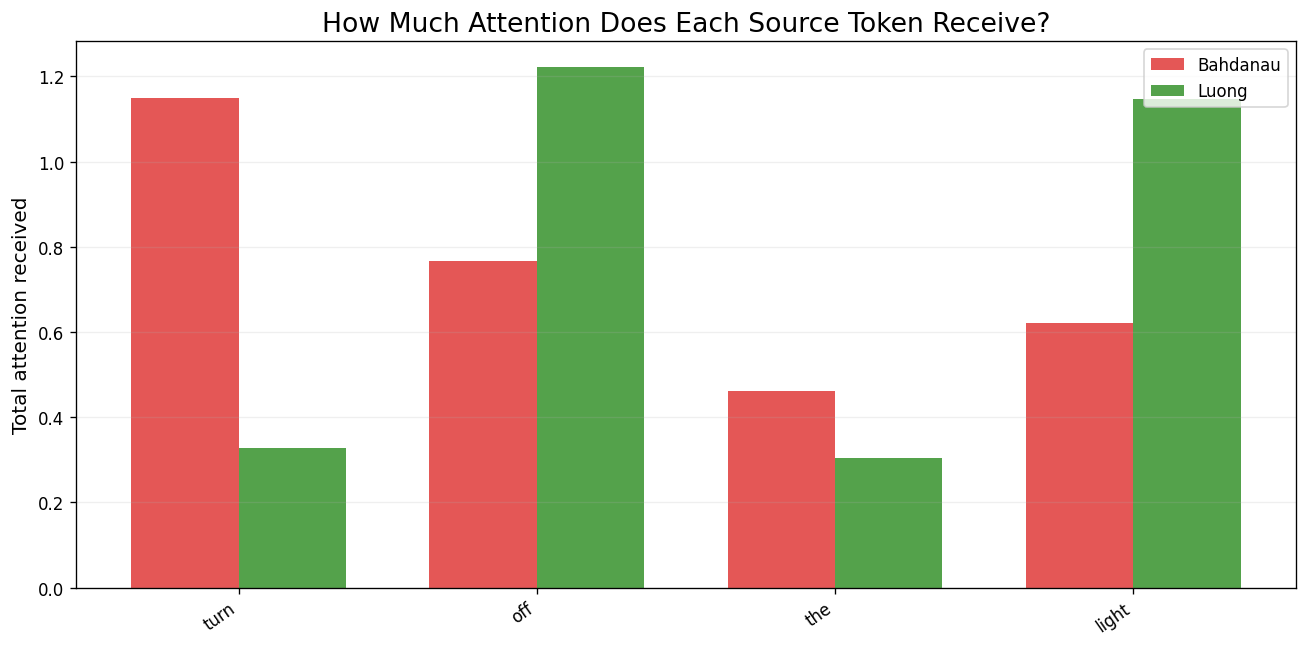

In [57]:


x = np.arange(len(sample_source))
width = 0.36

plt.figure(figsize=(11, 5.5))
plt.bar(
    x - width/2,
    bah_source_importance,
    width=width,
    label="Bahdanau",
    color="#E45756"
)
plt.bar(
    x + width/2,
    luo_source_importance,
    width=width,
    label="Luong",
    color="#54A24B"
)

plt.xticks(x, sample_source, rotation=35, ha="right")
plt.ylabel("Total attention received")
plt.title("How Much Attention Does Each Source Token Receive?")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_67.png", dpi=180, bbox_inches="tight")
plt.show()


# 11. Context vectors in detail

The source gives the central context-vector idea as a weighted sum of encoder hidden states:

`c_i = sum_j alpha_ij h_j`

The weights change by decoder step, so the context vector also changes over time. fileciteturn0file0L663-L705

/tmp/ipykernel_814/2072563716.py:14: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2072563716.py:14: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/2072563716.py:14: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2072563716.py:14: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2072563716.py:14: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2072563716.py:14: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2072563716.py:14: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

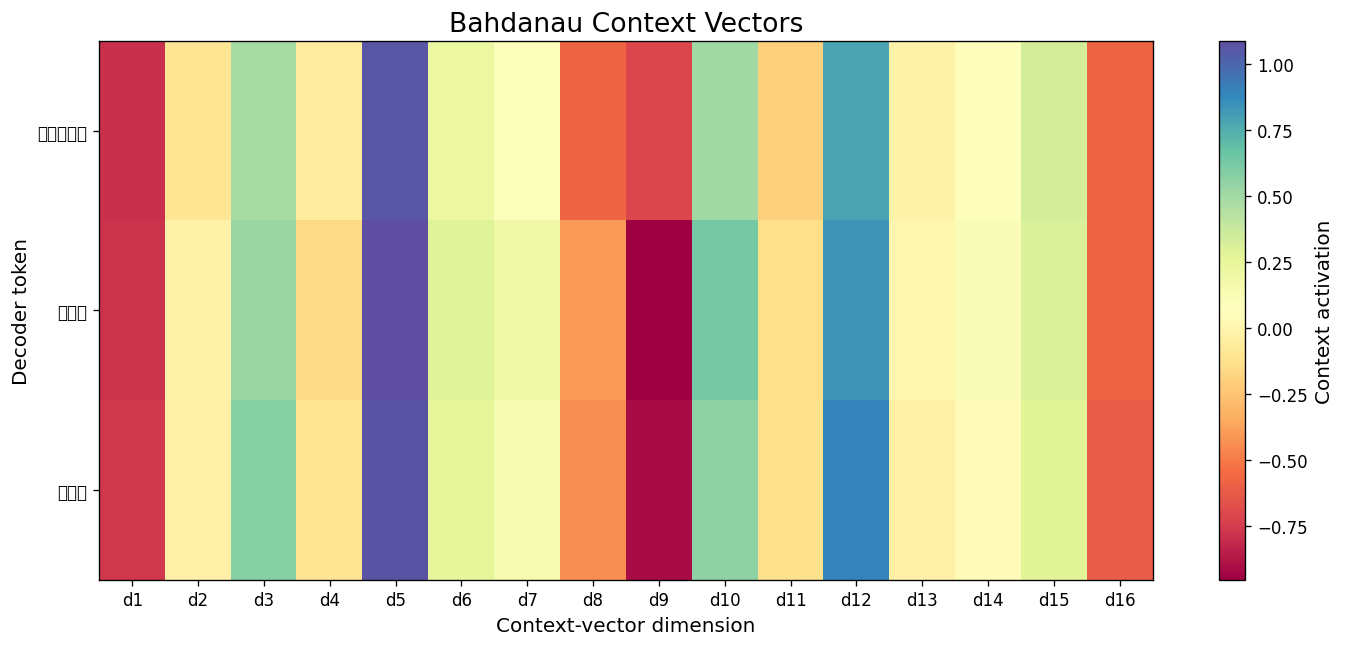

In [58]:


plt.figure(figsize=(12, 5.5))
im = plt.imshow(bah_context, cmap="Spectral", aspect="auto")

plt.yticks(np.arange(len(sample_target)), sample_target)
plt.xticks(
    np.arange(semantic_dim),
    [f"d{i+1}" for i in range(semantic_dim)]
)

plt.xlabel("Context-vector dimension")
plt.ylabel("Decoder token")
plt.title("Bahdanau Context Vectors")
plt.colorbar(im, label="Context activation")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_69.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_814/3309113912.py:14: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3309113912.py:14: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/3309113912.py:14: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3309113912.py:14: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3309113912.py:14: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3309113912.py:14: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3309113912.py:14: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

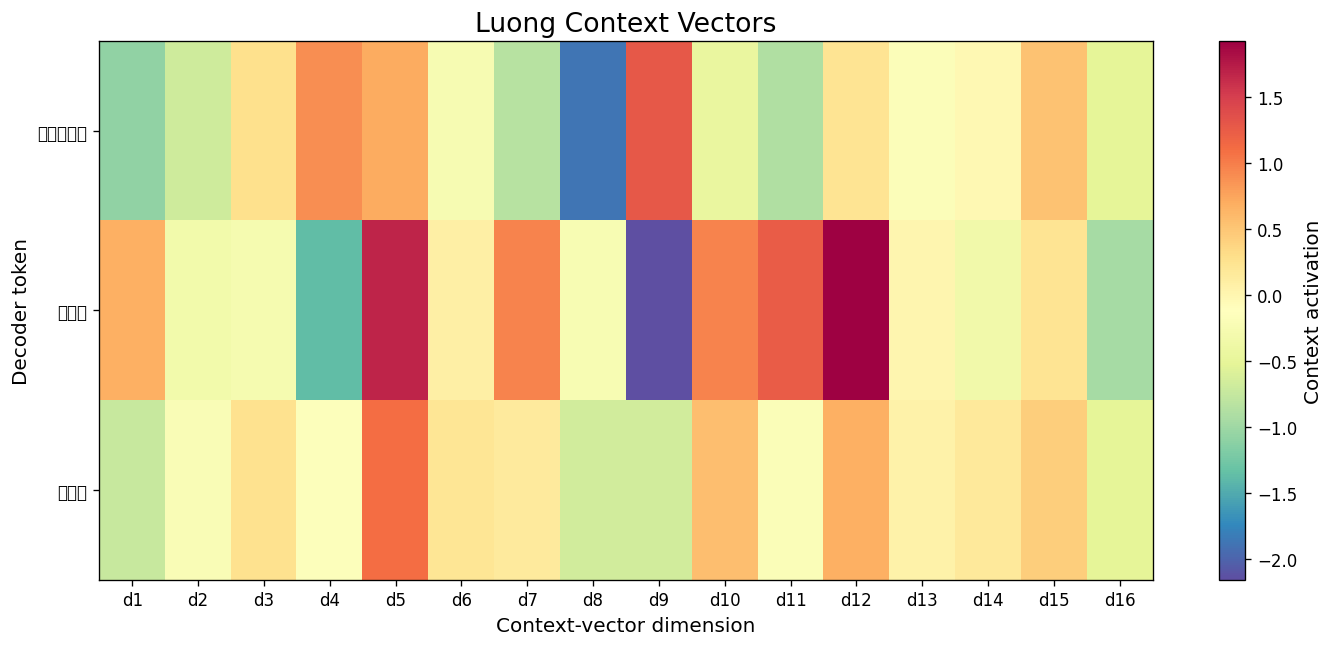

In [59]:


plt.figure(figsize=(12, 5.5))
im = plt.imshow(luo_context, cmap="Spectral_r", aspect="auto")

plt.yticks(np.arange(len(sample_target)), sample_target)
plt.xticks(
    np.arange(semantic_dim),
    [f"d{i+1}" for i in range(semantic_dim)]
)

plt.xlabel("Context-vector dimension")
plt.ylabel("Decoder token")
plt.title("Luong Context Vectors")
plt.colorbar(im, label="Context activation")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_70.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_814/1284885398.py:22: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1284885398.py:22: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/1284885398.py:22: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1284885398.py:22: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1284885398.py:22: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1284885398.py:22: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/1284885398.py:22: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

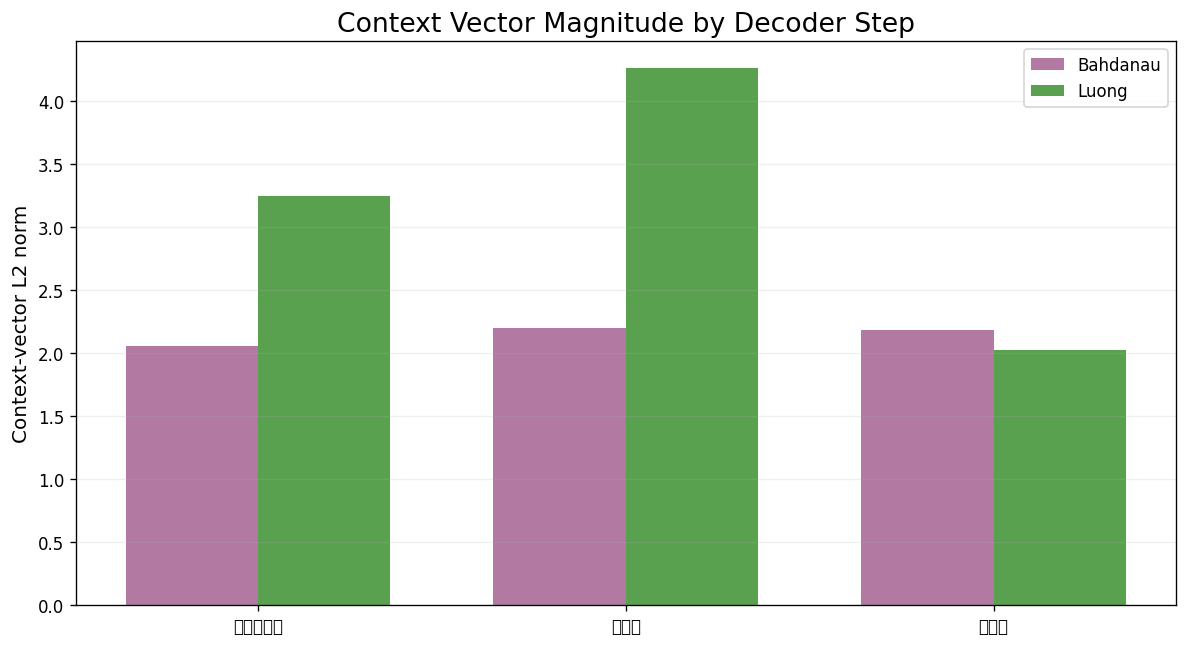

In [60]:


bah_context_norm = np.linalg.norm(bah_context, axis=1)
luo_context_norm = np.linalg.norm(luo_context, axis=1)

x = np.arange(len(sample_target))
width = 0.36

plt.figure(figsize=(10, 5.5))
plt.bar(
    x - width/2, bah_context_norm,
    width=width, label="Bahdanau", color="#B279A2"
)
plt.bar(
    x + width/2, luo_context_norm,
    width=width, label="Luong", color="#59A14F"
)

plt.xticks(x, sample_target)
plt.ylabel("Context-vector L2 norm")
plt.title("Context Vector Magnitude by Decoder Step")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_71.png", dpi=180, bbox_inches="tight")
plt.show()


# 12. Entropy and confidence diagnostics

Attention does more than pick a position. It creates a distribution.

Entropy lets us quantify how **focused** or **spread out** that distribution is.

In [61]:


def attention_entropy(alpha):
    eps = 1e-12
    return -np.sum(alpha * np.log(alpha + eps), axis=1)

bah_entropy = attention_entropy(bah_alpha)
luo_entropy = attention_entropy(luo_alpha)

entropy_df = pd.DataFrame({
    "target_token": sample_target,
    "Bahdanau_entropy": bah_entropy,
    "Luong_entropy": luo_entropy,
    "Bahdanau_max_weight": bah_alpha.max(axis=1),
    "Luong_max_weight": luo_alpha.max(axis=1),
})

display(entropy_df.round(4))

,target_token,Bahdanau_entropy,Luong_entropy,Bahdanau_max_weight,Luong_max_weight
0,रोशनी,1.3484,0.4271,0.3501,0.8971
1,बंद,1.3211,0.2050,0.3990,0.9592
2,करो,1.3076,1.3850,0.4002,0.2671


/tmp/ipykernel_814/3602646365.py:19: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3602646365.py:19: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/3602646365.py:19: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3602646365.py:19: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3602646365.py:19: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3602646365.py:19: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3602646365.py:19: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

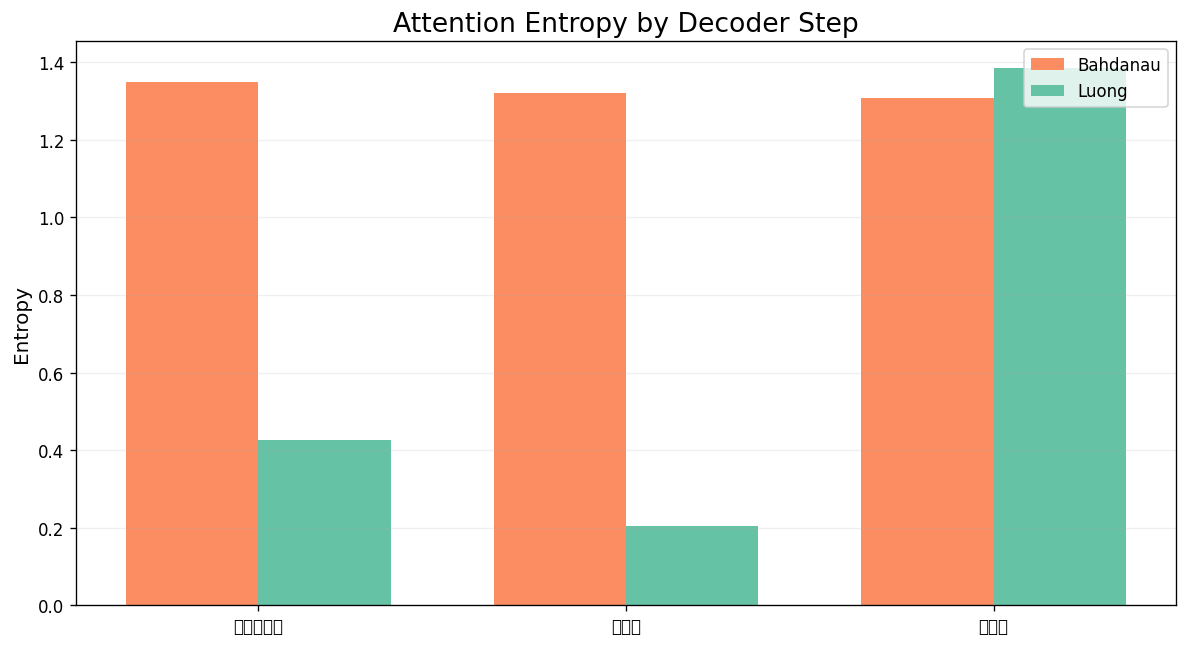

In [62]:


x = np.arange(len(sample_target))
width = 0.36

plt.figure(figsize=(10, 5.5))
plt.bar(
    x - width/2, bah_entropy,
    width=width, label="Bahdanau", color="#FC8D62"
)
plt.bar(
    x + width/2, luo_entropy,
    width=width, label="Luong", color="#66C2A5"
)

plt.xticks(x, sample_target)
plt.ylabel("Entropy")
plt.title("Attention Entropy by Decoder Step")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_74.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_814/2781761117.py:25: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2781761117.py:25: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/2781761117.py:25: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2781761117.py:25: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2781761117.py:25: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2781761117.py:25: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2781761117.py:25: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

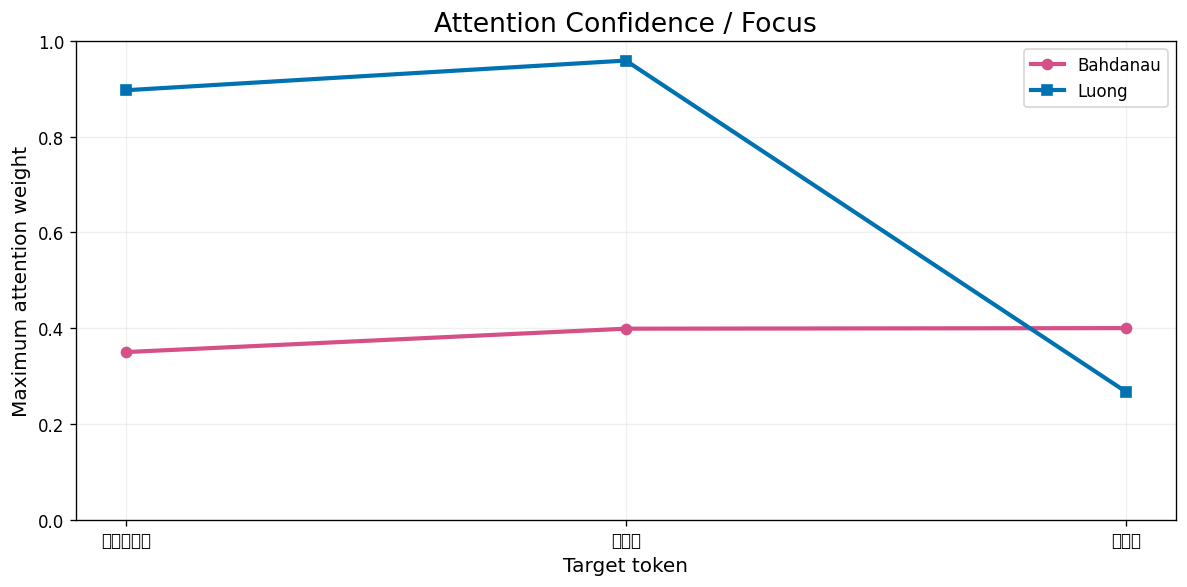

In [63]:


plt.figure(figsize=(10, 5))
plt.plot(
    sample_target,
    bah_alpha.max(axis=1),
    marker="o",
    linewidth=2.5,
    label="Bahdanau",
    color="#D45087"
)
plt.plot(
    sample_target,
    luo_alpha.max(axis=1),
    marker="s",
    linewidth=2.5,
    label="Luong",
    color="#0072B2"
)

plt.ylim(0, 1)
plt.ylabel("Maximum attention weight")
plt.xlabel("Target token")
plt.title("Attention Confidence / Focus")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_75.png", dpi=180, bbox_inches="tight")
plt.show()


# 13. Temperature experiment

Temperature is useful for building intuition.

Lower values make softmax distributions sharper; higher values flatten them.

In [64]:


temperatures = [0.25, 0.5, 1.0, 1.5, 2.5]

temperature_summary = []

for t in temperatures:
    _, alpha_t, _ = luong_attention(
        H, S, temperature=t, scale=True
    )

    temperature_summary.append({
        "temperature": t,
        "mean_max_weight": alpha_t.max(axis=1).mean(),
        "mean_entropy": attention_entropy(alpha_t).mean()
    })

temp_df = pd.DataFrame(temperature_summary)
display(temp_df.round(4))

,temperature,mean_max_weight,mean_entropy
0,0.25,0.7737,0.4556
1,0.50,0.7594,0.4758
2,1.00,0.7078,0.6724
3,1.50,0.6246,0.9108
4,2.50,0.4951,1.1721


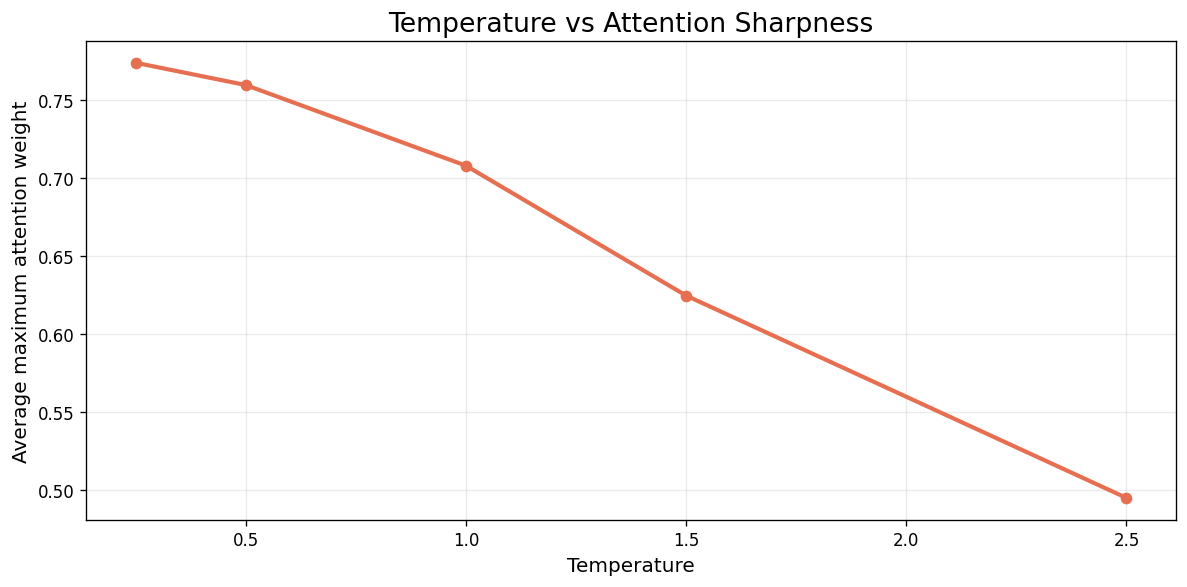

In [65]:


plt.figure(figsize=(10, 5))
plt.plot(
    temp_df["temperature"],
    temp_df["mean_max_weight"],
    marker="o",
    linewidth=2.5,
    color="#E76F51"
)

plt.xlabel("Temperature")
plt.ylabel("Average maximum attention weight")
plt.title("Temperature vs Attention Sharpness")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_78.png", dpi=180, bbox_inches="tight")
plt.show()


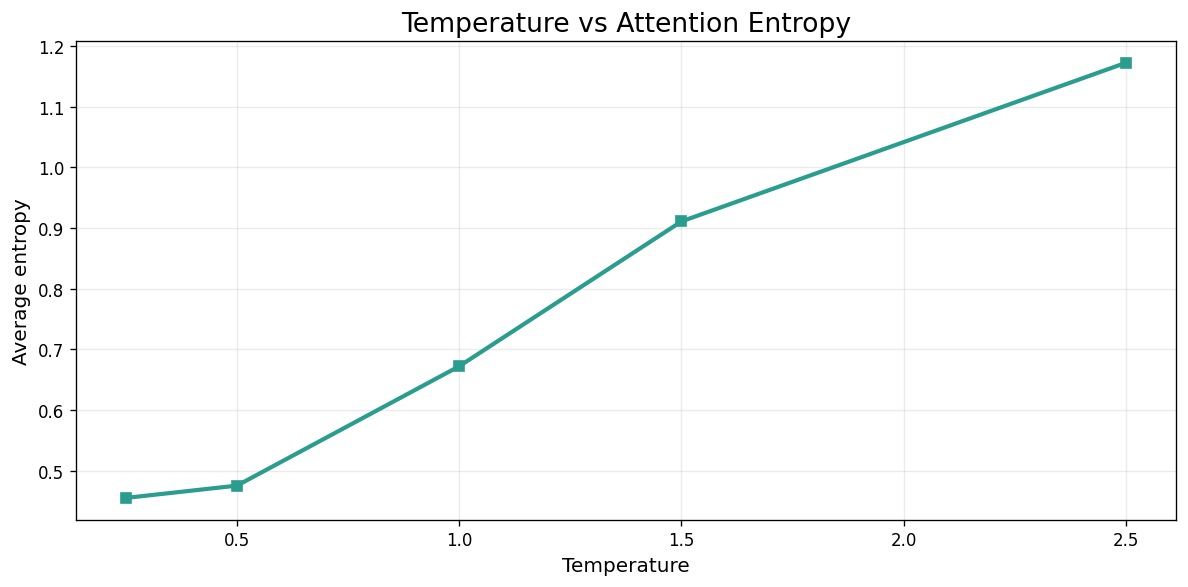

In [66]:


plt.figure(figsize=(10, 5))
plt.plot(
    temp_df["temperature"],
    temp_df["mean_entropy"],
    marker="s",
    linewidth=2.5,
    color="#2A9D8F"
)

plt.xlabel("Temperature")
plt.ylabel("Average entropy")
plt.title("Temperature vs Attention Entropy")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_79.png", dpi=180, bbox_inches="tight")
plt.show()


# 14. Padding and masking

Real batches usually contain sequences of different lengths.

We therefore pad shorter sequences.

The problem:

> The model must **not attend to `<PAD>` positions**.

This is where attention masks become critical.

In [67]:


PAD = "<PAD>"

def pad_tokens(tokens, max_len, pad_token=PAD):
    tokens = list(tokens)
    return tokens + [pad_token] * (max_len - len(tokens))

examples = [
    tokenize_en("open the door"),
    tokenize_en("turn off the light"),
    tokenize_en("run the code"),
]

max_len = max(map(len, examples))
padded = [pad_tokens(x, max_len) for x in examples]

display(pd.DataFrame(padded))

,0,1,2,3
0,open,the,door,<PAD>
1,turn,off,the,light
2,run,the,code,<PAD>


In [68]:


def make_padding_mask(tokens, pad_token=PAD):
    return np.array([
        token != pad_token
        for token in tokens
    ])

mask_examples = [
    make_padding_mask(seq)
    for seq in padded
]

display(pd.DataFrame(mask_examples))

,0,1,2,3
0,True,True,True,False
1,True,True,True,True
2,True,True,True,False


In [69]:


def masked_softmax(scores, mask, temperature=1.0):
    scores = np.asarray(scores, dtype=float).copy()

    mask = np.asarray(mask).astype(bool)

    scores[~mask] = -1e9
    return softmax_stable(scores, temperature=temperature)

demo_scores = np.array([1.5, 2.0, 0.5, -0.2])
demo_mask = np.array([True, True, False, False])

masked_alpha = masked_softmax(demo_scores, demo_mask)

print("Masked softmax:", np.round(masked_alpha, 4))
print("Sum:", masked_alpha.sum())
print("Masked positions:", masked_alpha[~demo_mask])

Masked softmax: [0.3775 0.6225 0.     0.    ]
Sum: 1.0
Masked positions: [0. 0.]


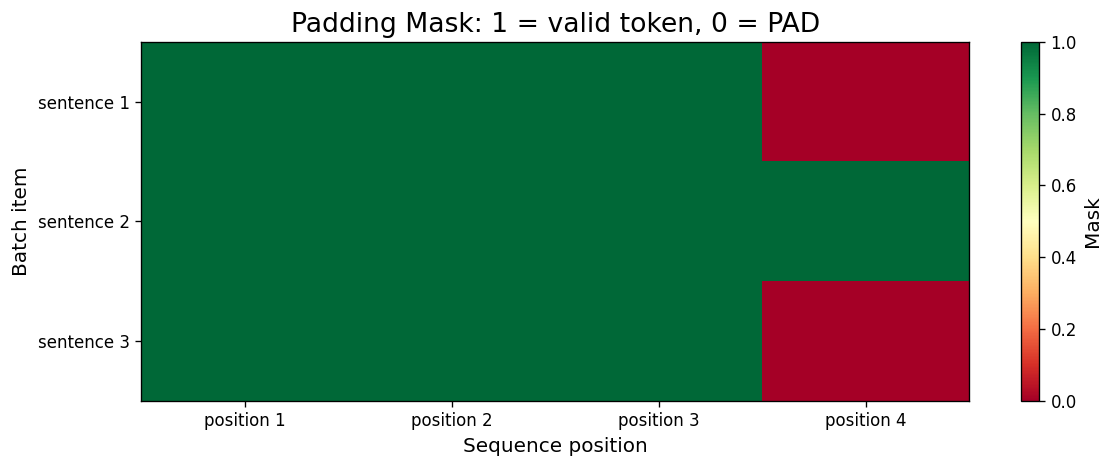

In [70]:


plt.figure(figsize=(10, 4))
mask_matrix = np.array(mask_examples, dtype=int)

im = plt.imshow(mask_matrix, cmap="RdYlGn", aspect="auto")
plt.xticks(
    np.arange(max_len),
    [f"position {i+1}" for i in range(max_len)]
)
plt.yticks(
    np.arange(len(padded)),
    [f"sentence {i+1}" for i in range(len(padded))]
)
plt.xlabel("Sequence position")
plt.ylabel("Batch item")
plt.title("Padding Mask: 1 = valid token, 0 = PAD")
plt.colorbar(im, label="Mask")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_84.png", dpi=180, bbox_inches="tight")
plt.show()


# 15. Batch attention

A useful next step is to process several source/target pairs.

For a batch, conceptually:

`batch × target_length × source_length`

is the attention-weight tensor.

Our toy examples have different lengths, so we demonstrate the idea using a padded batch and masks.

In [71]:


batch_ids = [1, 2, 3, 4]

batch_rows = df[df["id"].isin(batch_ids)].copy()

for _, row in batch_rows.iterrows():
    print(f"{row['id']}: {row['english']} -> {row['hindi']}")

1: turn on the light -> रोशनी चालू करो
2: turn off the light -> रोशनी बंद करो
3: open the door -> दरवाज़ा खोलो
4: close the door -> दरवाज़ा बंद करो


,id,english_len,hindi_len
0,1,4,3
1,2,4,3
2,3,3,2
3,4,3,3


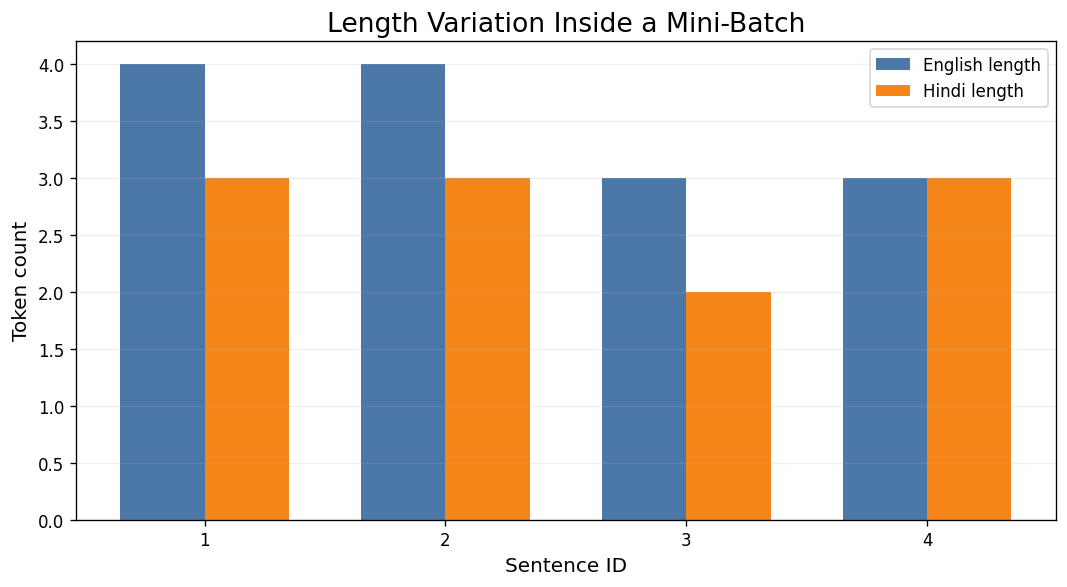

In [72]:


batch_lengths = batch_rows[["id", "english_len", "hindi_len"]].copy()
display(batch_lengths)

plt.figure(figsize=(9, 5))
x = np.arange(len(batch_lengths))
width = 0.35

plt.bar(
    x - width/2,
    batch_lengths["english_len"],
    width=width,
    label="English length",
    color="#4C78A8"
)
plt.bar(
    x + width/2,
    batch_lengths["hindi_len"],
    width=width,
    label="Hindi length",
    color="#F58518"
)

plt.xticks(x, batch_lengths["id"])
plt.xlabel("Sentence ID")
plt.ylabel("Token count")
plt.title("Length Variation Inside a Mini-Batch")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_87.png", dpi=180, bbox_inches="tight")
plt.show()


In [73]:


max_src = max(batch_rows["english_len"])
max_tgt = max(batch_rows["hindi_len"])

attention_tensor_shape = (
    len(batch_rows),
    max_tgt,
    max_src
)

print("Conceptual batch attention shape:")
print("(batch, target_length, source_length) =", attention_tensor_shape)

demo_tensor = np.zeros(attention_tensor_shape)
print("Demo tensor shape:", demo_tensor.shape)

Conceptual batch attention shape:
(batch, target_length, source_length) = (4, 3, 4)
Demo tensor shape: (4, 3, 4)


# 16. Scaling and numerical behavior

Dot products can become large as dimensionality increases.

A common modern stabilization is to divide dot-product scores by:

`sqrt(d)`

This notebook compares scaled and unscaled Luong scores so you can see how the softmax distribution changes.

In [74]:


_, alpha_unscaled, _ = luong_attention(
    H, S, scale=False
)

_, alpha_scaled, _ = luong_attention(
    H, S, scale=True
)

unscaled_entropy = attention_entropy(alpha_unscaled).mean()
scaled_entropy = attention_entropy(alpha_scaled).mean()

print("Mean entropy — unscaled:", round(unscaled_entropy, 4))
print("Mean entropy — scaled  :", round(scaled_entropy, 4))

Mean entropy — unscaled: 0.4556
Mean entropy — scaled  : 0.6724


/tmp/ipykernel_814/3474948015.py:14: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:14: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:14: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:14: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:14: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:14: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:14: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

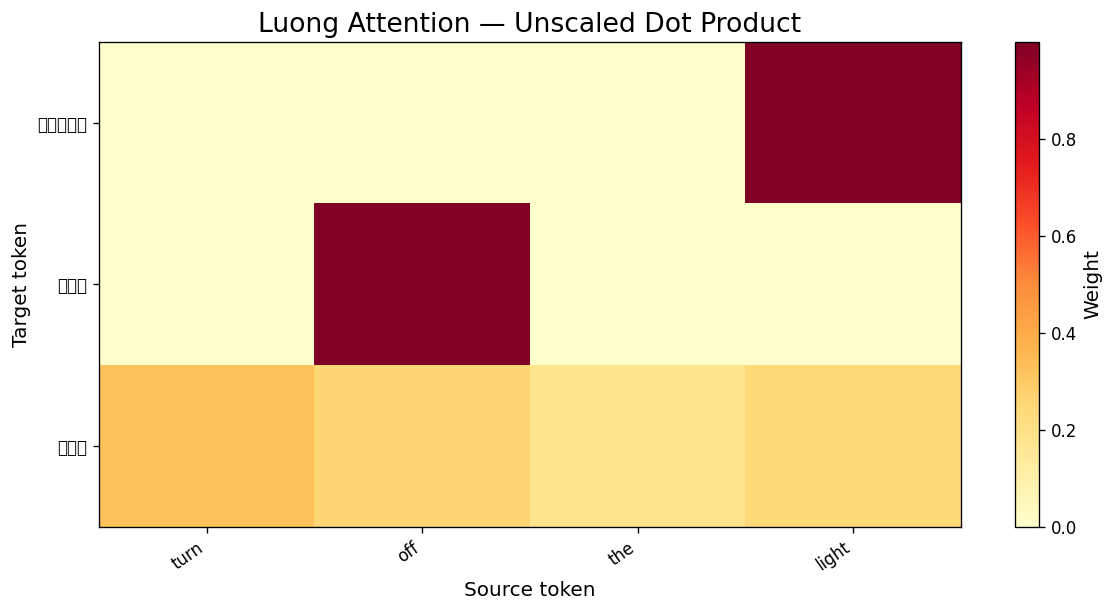

/tmp/ipykernel_814/3474948015.py:31: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:31: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:31: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:31: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:31: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:31: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3474948015.py:31: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

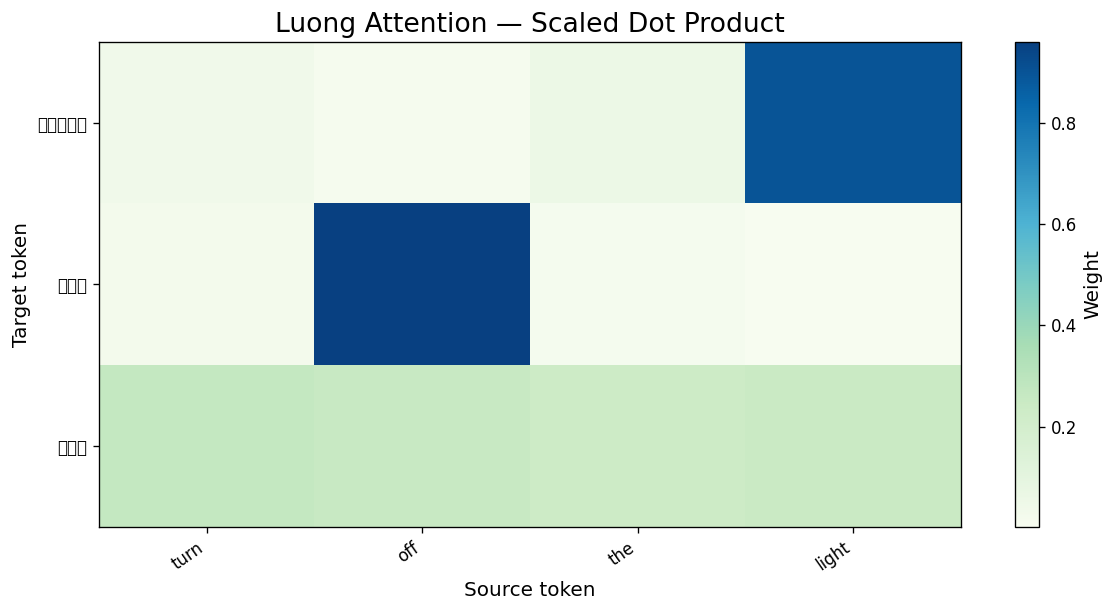

In [75]:


plt.figure(figsize=(10, 5.2))
im = plt.imshow(alpha_unscaled, cmap="YlOrRd", aspect="auto")
plt.xticks(
    np.arange(len(sample_source)),
    sample_source,
    rotation=35,
    ha="right"
)
plt.yticks(np.arange(len(sample_target)), sample_target)
plt.title("Luong Attention — Unscaled Dot Product")
plt.xlabel("Source token")
plt.ylabel("Target token")
plt.colorbar(im, label="Weight")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_91.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5.2))
im = plt.imshow(alpha_scaled, cmap="GnBu", aspect="auto")
plt.xticks(
    np.arange(len(sample_source)),
    sample_source,
    rotation=35,
    ha="right"
)
plt.yticks(np.arange(len(sample_target)), sample_target)
plt.title("Luong Attention — Scaled Dot Product")
plt.xlabel("Source token")
plt.ylabel("Target token")
plt.colorbar(im, label="Weight")
plt.tight_layout()
plt.show()


# 17. Automated sanity checks

A strong notebook should not only produce pretty graphs. It should also check its own mathematics.

In [76]:



assert np.allclose(bah_alpha.sum(axis=1), 1.0, atol=1e-8)
assert np.allclose(luo_alpha.sum(axis=1), 1.0, atol=1e-8)


assert np.all(bah_alpha >= 0)
assert np.all(luo_alpha >= 0)



assert bah_context.shape == (len(sample_target), H.shape[1])
assert luo_context.shape == (len(sample_target), H.shape[1])


test = softmax_stable(np.array([2.0, 0.1, -1.0]))
assert np.isclose(test.sum(), 1.0)

print("✓ Row normalization checks passed.")
print("✓ Non-negativity checks passed.")
print("✓ Context shape checks passed.")
print("✓ Softmax checks passed.")

✓ Row normalization checks passed.
✓ Non-negativity checks passed.
✓ Context shape checks passed.
✓ Softmax checks passed.


# 18. One compact visual summary

The next cells create a few “presentation-ready” plots you can use in a project notebook, report, or viva.

In [77]:


bah_winners = np.argmax(bah_alpha, axis=1)
luo_winners = np.argmax(luo_alpha, axis=1)

winner_df = pd.DataFrame({
    "Target token": sample_target,
    "Bahdanau winner": [sample_source[i] for i in bah_winners],
    "Bahdanau weight": bah_alpha[np.arange(len(sample_target)), bah_winners],
    "Luong winner": [sample_source[i] for i in luo_winners],
    "Luong weight": luo_alpha[np.arange(len(sample_target)), luo_winners],
})

display(winner_df.round(3))

,Target token,Bahdanau winner,Bahdanau weight,Luong winner,Luong weight
0,रोशनी,turn,0.350,light,0.897
1,बंद,turn,0.399,off,0.959
2,करो,turn,0.400,turn,0.267


/tmp/ipykernel_814/3457884170.py:29: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3457884170.py:29: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/3457884170.py:29: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3457884170.py:29: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3457884170.py:29: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3457884170.py:29: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/3457884170.py:29: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

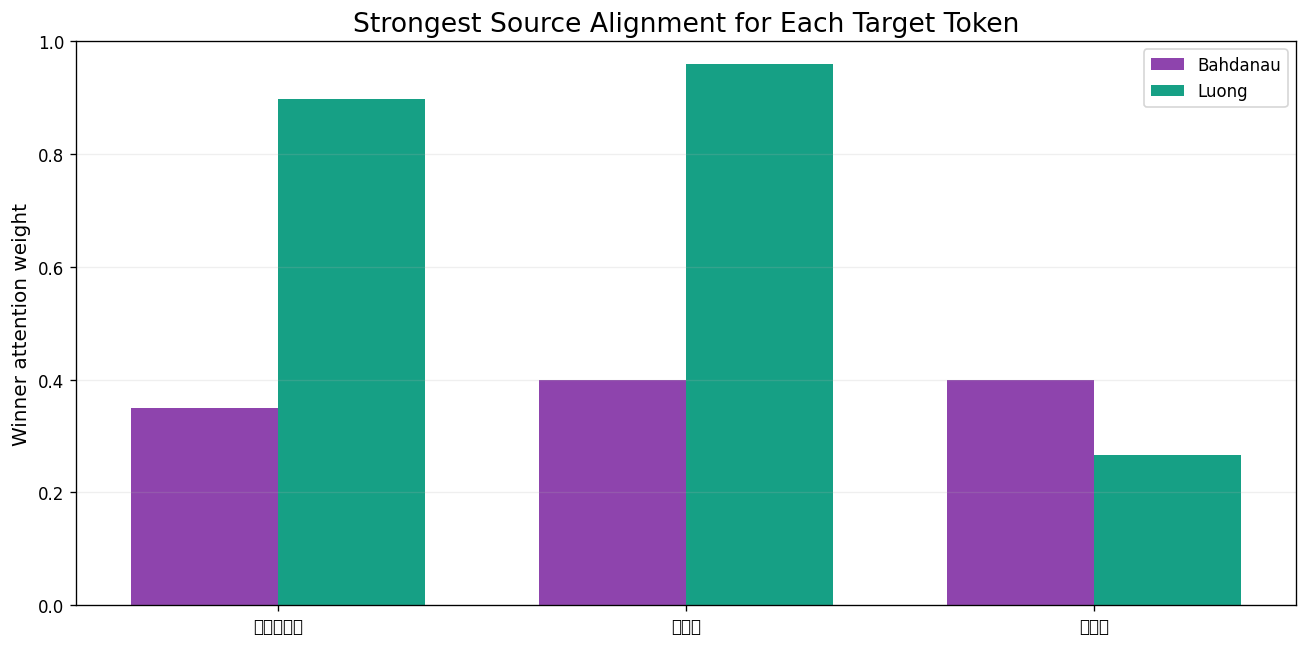

In [78]:


x = np.arange(len(sample_target))
width = 0.36

bah_winner_weights = winner_df["Bahdanau weight"].to_numpy()
luo_winner_weights = winner_df["Luong weight"].to_numpy()

plt.figure(figsize=(11, 5.5))
plt.bar(
    x - width/2,
    bah_winner_weights,
    width=width,
    label="Bahdanau",
    color="#8E44AD"
)
plt.bar(
    x + width/2,
    luo_winner_weights,
    width=width,
    label="Luong",
    color="#16A085"
)

plt.xticks(x, sample_target)
plt.ylim(0, 1)
plt.ylabel("Winner attention weight")
plt.title("Strongest Source Alignment for Each Target Token")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "auto_plot_96.png", dpi=180, bbox_inches="tight")
plt.show()


In [79]:


avg_bah_entropy = float(bah_entropy.mean())
avg_luo_entropy = float(luo_entropy.mean())
avg_bah_max = float(bah_alpha.max(axis=1).mean())
avg_luo_max = float(luo_alpha.max(axis=1).mean())

print("=" * 55)
print("ATTENTION LAB SUMMARY")
print("=" * 55)
print(f"Source length                : {len(sample_source)}")
print(f"Target length                : {len(sample_target)}")
print(f"Hidden dimension             : {semantic_dim}")
print(f"Bahdanau average entropy     : {avg_bah_entropy:.4f}")
print(f"Luong average entropy        : {avg_luo_entropy:.4f}")
print(f"Bahdanau average max weight  : {avg_bah_max:.4f}")
print(f"Luong average max weight     : {avg_luo_max:.4f}")
print("=" * 55)

ATTENTION LAB SUMMARY
Source length                : 4
Target length                : 3
Hidden dimension             : 16
Bahdanau average entropy     : 1.3257
Luong average entropy        : 0.6724
Bahdanau average max weight  : 0.3831
Luong average max weight     : 0.7078


# 19. Practical interpretation

Do not read an attention heatmap as:

> “The model definitely understands language here.”

That would be too strong.

Read it as:

> “Under this representation and scoring mechanism, the model is assigning this amount of attention mass to each source position.”

That distinction matters, especially when studying interpretability.

# 20. Exercises — now you drive the notebook

### Exercise A — inspect a different sentence

Change:

```python
example_id = 2
```

to another dataset ID and regenerate `H`, `S`, `bah_alpha`, and `luo_alpha`.

### Exercise B — alter alignment dimension

Try:

```python
alignment_dim=8
alignment_dim=16
alignment_dim=32
alignment_dim=64
```

Then compare the Bahdanau heatmaps.

### Exercise C — experiment with temperature

Try:

```python
0.25
0.5
1.0
2.0
```

Record the entropy.

### Exercise D — compare Luong variants

Compare `dot`, `general`, and `concat` scores for the same decoder step.

### Exercise E — add your own sentence

Add an English–Hindi pair to `pairs`, regenerate `df`, and inspect the attention.

### Exercise F — implement a decoder readout

Take:

```python
context_i
decoder_state_i
```

concatenate them and pass them through a small dense layer to produce a toy output score. The goal is to understand the architecture flow, not to build a production translator.

# 21. Viva / interview questions

### Conceptual
1. Why does a fixed context vector create a bottleneck?
2. Why does attention expose all encoder hidden states?
3. What does `alpha_ij` represent?
4. Why do the attention weights sum to 1?
5. What is the role of the context vector?

### Bahdanau
6. Why is Bahdanau called additive attention?
7. Why is a feed-forward network used for alignment?
8. Which decoder state appears in the classic scoring formulation?

### Luong
9. Why is dot product a useful similarity score?
10. What is the difference between dot and general Luong attention?
11. Why can multiplicative attention be computationally attractive?

### Implementation
12. Why subtract the maximum before exponentiating in softmax?
13. Why do padded tokens need masking?
14. What is the shape of an attention matrix?
15. What does a high-entropy attention row mean?

# 22. Final mental model

The entire classical attention story can be compressed into:

```text
Encoder
  |
  +--> h1
  +--> h2
  +--> h3
  +--> ...
  |
  v
Score relevance
  |
  v
e_ij
  |
  v
Softmax
  |
  v
alpha_ij
  |
  v
Weighted sum
  |
  v
c_i
  |
  v
Decoder
  |
  v
y_i
```

For Bahdanau:

`encoder state + previous decoder state → learned alignment network → score`

For Luong dot-product:

`current decoder state · encoder state → score`

The **purpose is the same**:

> dynamically decide where to look before producing the next output.

# 23. Connection to self-attention and Transformers

The provided material closes by emphasizing that understanding these classic attention architectures helps prepare for Transformer self-attention. fileciteturn0file0L915-L925

The bridge is worth remembering:

**Classical encoder–decoder attention**
- queries come from decoder states
- keys/values come from encoder states

**Self-attention**
- queries, keys, and values are produced from the same sequence representation

So the mathematical instinct you should carry forward is:

**compare → normalize → weighted combine**

That is the real transferable idea.

In [80]:


bah_table.to_csv(
    "bahdanau_attention_example.csv",
    encoding="utf-8-sig"
)

luo_table.to_csv(
    "luong_attention_example.csv",
    encoding="utf-8-sig"
)

winner_df.to_csv(
    "attention_alignment_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print("- bahdanau_attention_example.csv")
print("- luong_attention_example.csv")
print("- attention_alignment_summary.csv")

Saved:
- bahdanau_attention_example.csv
- luong_attention_example.csv
- attention_alignment_summary.csv


In [81]:


required_objects = [
    "df",
    "H",
    "S",
    "bah_alpha",
    "luo_alpha",
    "bah_context",
    "luo_context",
    "bah_table",
    "luo_table"
]

missing = [name for name in required_objects if name not in globals()]

if missing:
    print("Missing objects:", missing)
else:
    print("✓ All major notebook objects exist.")
    print("✓ Detailed Attention Lab completed successfully.")

✓ All major notebook objects exist.
✓ Detailed Attention Lab completed successfully.


# 20. Train Two Real Seq2Seq Attention Models

The earlier sections studied attention mathematically.

Now we train two actual sequence-to-sequence neural translation models on the same custom English → Hindi dataset.

The two models are:

1. **Bahdanau Attention**
2. **Luong Dot-Product Attention**

The models use the same:

- data split
- vocabulary
- embedding dimension
- GRU encoder
- GRU decoder
- optimizer
- learning rate
- batch size
- number of epochs
- masked cross-entropy loss
- teacher-forcing strategy

The controlled architectural difference is the attention scoring mechanism.

PyTorch is used for the trainable section so the notebook is runnable in this environment.

## Experimental hypothesis

Because Bahdanau attention uses a learned nonlinear compatibility function while Luong dot-product attention uses direct vector similarity, we expect differences in:

- parameter count
- computational cost
- convergence behavior
- validation loss
- token accuracy
- attention concentration
- generated translations

The experiment is deliberately controlled.

A fair comparison is more useful than changing the attention mechanism and the entire rest of the architecture at the same time.

In [82]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Images directory:", IMAGES_DIR.resolve())

PyTorch: 2.11.0+cu130
Device: cuda
Images directory: /content/images


In [83]:
def save_fig(filename):
    path = IMAGES_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("Saved:", path)

# 21. Build supervised training arrays

For every target sentence:

`<SOS> y1 y2 ... yn <EOS>`

teacher forcing creates:

`decoder_input = <SOS> y1 ... yn`

`decoder_target = y1 ... yn <EOS>`

The target is shifted by one position.

In [84]:
train_df = df[["id", "english", "hindi"]].copy()

def add_target_markers(tokens):
    return ["<SOS>"] + list(tokens) + ["<EOS>"]

train_df["target_tokens_marked"] = train_df["hindi"].apply(
    lambda x: add_target_markers(tokenize_hi(x))
)

english_tokens_all = [
    tok
    for row in train_df["english"]
    for tok in tokenize_en(row)
]

target_tokens_all = [
    tok
    for row in train_df["target_tokens_marked"]
    for tok in row
]

en_vocab = ["<PAD>", "<UNK>"] + sorted(set(english_tokens_all))
hi_vocab = ["<PAD>", "<UNK>"] + sorted(set(target_tokens_all))

en_token_to_id = {tok: i for i, tok in enumerate(en_vocab)}
hi_token_to_id = {tok: i for i, tok in enumerate(hi_vocab)}

en_id_to_token = {i: tok for tok, i in en_token_to_id.items()}
hi_id_to_token = {i: tok for tok, i in hi_token_to_id.items()}

PAD_ID_EN = en_token_to_id["<PAD>"]
PAD_ID_HI = hi_token_to_id["<PAD>"]
SOS_ID = hi_token_to_id["<SOS>"]
EOS_ID = hi_token_to_id["<EOS>"]

max_src_len = train_df["english"].apply(
    lambda x: len(tokenize_en(x))
).max()

max_tgt_len = train_df["target_tokens_marked"].apply(
    len
).max()

print("English vocabulary:", len(en_vocab))
print("Hindi vocabulary:", len(hi_vocab))
print("Maximum source length:", max_src_len)
print("Maximum target length:", max_tgt_len)

English vocabulary: 73
Hindi vocabulary: 69
Maximum source length: 4
Maximum target length: 6


In [85]:
def encode_source(text):
    tokens = tokenize_en(text)

    ids = [
        en_token_to_id.get(
            tok,
            en_token_to_id["<UNK>"]
        )
        for tok in tokens
    ]

    ids += [PAD_ID_EN] * (max_src_len - len(ids))

    return ids

def encode_target(text):
    tokens = add_target_markers(
        tokenize_hi(text)
    )

    ids = [
        hi_token_to_id.get(
            tok,
            hi_token_to_id["<UNK>"]
        )
        for tok in tokens
    ]

    ids += [PAD_ID_HI] * (max_tgt_len - len(ids))

    return ids

source_array = np.array(
    [encode_source(x) for x in train_df["english"]],
    dtype=np.int64
)

target_full_array = np.array(
    [encode_target(x) for x in train_df["hindi"]],
    dtype=np.int64
)

decoder_input_array = target_full_array[:, :-1]
decoder_target_array = target_full_array[:, 1:]

print("Source:", source_array.shape)
print("Decoder input:", decoder_input_array.shape)
print("Decoder target:", decoder_target_array.shape)

Source: (40, 4)
Decoder input: (40, 5)
Decoder target: (40, 5)


In [86]:
train_size = int(len(source_array) * 0.8)

all_indices = np.arange(len(source_array))
rng = np.random.default_rng(42)
rng.shuffle(all_indices)

train_indices = all_indices[:train_size]
val_indices = all_indices[train_size:]

X_train = torch.tensor(
    source_array[train_indices],
    dtype=torch.long
)

Yin_train = torch.tensor(
    decoder_input_array[train_indices],
    dtype=torch.long
)

Yout_train = torch.tensor(
    decoder_target_array[train_indices],
    dtype=torch.long
)

X_val = torch.tensor(
    source_array[val_indices],
    dtype=torch.long
)

Yin_val = torch.tensor(
    decoder_input_array[val_indices],
    dtype=torch.long
)

Yout_val = torch.tensor(
    decoder_target_array[val_indices],
    dtype=torch.long
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 32
Validation samples: 8


In [87]:
BATCH_SIZE = 8

train_dataset = TensorDataset(
    X_train,
    Yin_train,
    Yout_train
)

val_dataset = TensorDataset(
    X_val,
    Yin_val,
    Yout_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 4
Validation batches: 1


# 22. Padding-aware loss and accuracy

Padding is not a real target token.

Therefore:

`CrossEntropyLoss(ignore_index=PAD_ID_HI)`

ensures `<PAD>` positions do not affect learning.

In [88]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID_HI
)

def token_accuracy(logits, targets):
    predictions = logits.argmax(dim=-1)
    mask = targets != PAD_ID_HI

    correct = (
        predictions.eq(targets) &
        mask
    ).sum().item()

    total = mask.sum().item()

    return correct / max(total, 1)

# 23. GRU encoder

The encoder returns the full sequence of hidden states.

Attention needs the entire sequence:

`h1, h2, ..., hT`

rather than only the final state.

In [89]:
class Encoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_ID_EN
        )

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, source):
        embedded = self.embedding(source)

        outputs, hidden = self.gru(
            embedded
        )

        return outputs, hidden

# 24. Bahdanau attention

For every decoder step:

`score = v^T tanh(W_h h_j + W_s s_prev)`

The scores are masked, passed through softmax, and used to create the context vector.

In [90]:
class BahdanauAttention(nn.Module):
    def __init__(
        self,
        hidden_dim,
        attention_dim
    ):
        super().__init__()

        self.W_h = nn.Linear(
            hidden_dim,
            attention_dim,
            bias=True
        )

        self.W_s = nn.Linear(
            hidden_dim,
            attention_dim,
            bias=False
        )

        self.v = nn.Linear(
            attention_dim,
            1,
            bias=False
        )

    def forward(
        self,
        encoder_outputs,
        decoder_hidden,
        source_mask
    ):
        projected_h = self.W_h(
            encoder_outputs
        )

        projected_s = self.W_s(
            decoder_hidden
        ).unsqueeze(1)

        energy = torch.tanh(
            projected_h + projected_s
        )

        scores = self.v(
            energy
        ).squeeze(-1)

        scores = scores.masked_fill(
            ~source_mask,
            -1e9
        )

        weights = torch.softmax(
            scores,
            dim=1
        )

        context = torch.bmm(
            weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, weights, scores

# 25. Luong dot-product attention

The alignment score is:

`score = s_prev^T h_j`

A scaled version divides by `sqrt(hidden_dim)`.

The notebook uses the scaled form during training.

In [91]:
class LuongAttention(nn.Module):
    def __init__(
        self,
        hidden_dim,
        scale=True
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.scale = scale

    def forward(
        self,
        encoder_outputs,
        decoder_hidden,
        source_mask
    ):
        scores = torch.bmm(
            encoder_outputs,
            decoder_hidden.unsqueeze(2)
        ).squeeze(2)

        if self.scale:
            scores = scores / np.sqrt(
                self.hidden_dim
            )

        scores = scores.masked_fill(
            ~source_mask,
            -1e9
        )

        weights = torch.softmax(
            scores,
            dim=1
        )

        context = torch.bmm(
            weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, weights, scores

# 26. Decoder cell

The decoder takes:

`target embedding + attention context`

and feeds their concatenation into a GRU.

The resulting hidden state produces vocabulary logits.

In [92]:
class AttentionDecoder(nn.Module):
    def __init__(
        self,
        target_vocab_size,
        embedding_dim,
        hidden_dim,
        attention_type="bahdanau",
        attention_dim=64
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            target_vocab_size,
            embedding_dim
        )

        self.gru = nn.GRU(
            embedding_dim + hidden_dim,
            hidden_dim,
            batch_first=True
        )

        if attention_type == "bahdanau":
            self.attention = BahdanauAttention(
                hidden_dim,
                attention_dim
            )
        elif attention_type == "luong":
            self.attention = LuongAttention(
                hidden_dim,
                scale=True
            )
        else:
            raise ValueError(
                "attention_type must be bahdanau or luong"
            )

        self.output = nn.Linear(
            hidden_dim,
            target_vocab_size
        )

    def step(
        self,
        input_token,
        hidden,
        encoder_outputs,
        source_mask
    ):
        embedded = self.embedding(
            input_token
        ).unsqueeze(1)

        context, weights, scores = self.attention(
            encoder_outputs,
            hidden[-1],
            source_mask
        )

        context = context.unsqueeze(1)

        gru_input = torch.cat(
            [embedded, context],
            dim=-1
        )

        output, new_hidden = self.gru(
            gru_input,
            hidden
        )

        logits = self.output(
            output.squeeze(1)
        )

        return (
            logits,
            new_hidden,
            weights,
            scores
        )

# 27. Full sequence-to-sequence model

The encoder creates source representations.

The decoder repeatedly applies attention and predicts the next target token.

Attention weights are stored for every decoder step so they can be visualized later.

In [93]:
class Seq2SeqAttentionModel(nn.Module):
    def __init__(
        self,
        source_vocab_size,
        target_vocab_size,
        embedding_dim=64,
        hidden_dim=128,
        attention_type="bahdanau",
        attention_dim=64
    ):
        super().__init__()

        self.encoder = Encoder(
            source_vocab_size,
            embedding_dim,
            hidden_dim
        )

        self.decoder = AttentionDecoder(
            target_vocab_size,
            embedding_dim,
            hidden_dim,
            attention_type=attention_type,
            attention_dim=attention_dim
        )

        self.attention_type = attention_type

    def forward(
        self,
        source,
        decoder_inputs
    ):
        encoder_outputs, hidden = self.encoder(
            source
        )

        source_mask = source != PAD_ID_EN

        logits_steps = []
        attention_steps = []
        score_steps = []

        for t in range(
            decoder_inputs.size(1)
        ):
            token = decoder_inputs[:, t]

            logits, hidden, weights, scores = (
                self.decoder.step(
                    token,
                    hidden,
                    encoder_outputs,
                    source_mask
                )
            )

            logits_steps.append(
                logits.unsqueeze(1)
            )

            attention_steps.append(
                weights.unsqueeze(1)
            )

            score_steps.append(
                scores.unsqueeze(1)
            )

        logits = torch.cat(
            logits_steps,
            dim=1
        )

        attention = torch.cat(
            attention_steps,
            dim=1
        )

        scores = torch.cat(
            score_steps,
            dim=1
        )

        return logits, attention, scores

# 28. Create the two models

Everything is matched as closely as possible.

Only the attention layer changes.

In [94]:
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
ATTENTION_DIM = 64
LEARNING_RATE = 0.001
EPOCHS = 80

bahdanau_model = Seq2SeqAttentionModel(
    len(en_vocab),
    len(hi_vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_type="bahdanau",
    attention_dim=ATTENTION_DIM
).to(DEVICE)

luong_model = Seq2SeqAttentionModel(
    len(en_vocab),
    len(hi_vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_type="luong",
    attention_dim=ATTENTION_DIM
).to(DEVICE)

bahdanau_optimizer = torch.optim.Adam(
    bahdanau_model.parameters(),
    lr=LEARNING_RATE
)

luong_optimizer = torch.optim.Adam(
    luong_model.parameters(),
    lr=LEARNING_RATE
)

print("Bahdanau parameters:",
      sum(p.numel() for p in bahdanau_model.parameters()))

print("Luong parameters:",
      sum(p.numel() for p in luong_model.parameters()))

Bahdanau parameters: 232645
Luong parameters: 216133


,Model,Parameters
0,Bahdanau,232645
1,Luong,216133


Saved: images/13_trainable_parameter_count.png


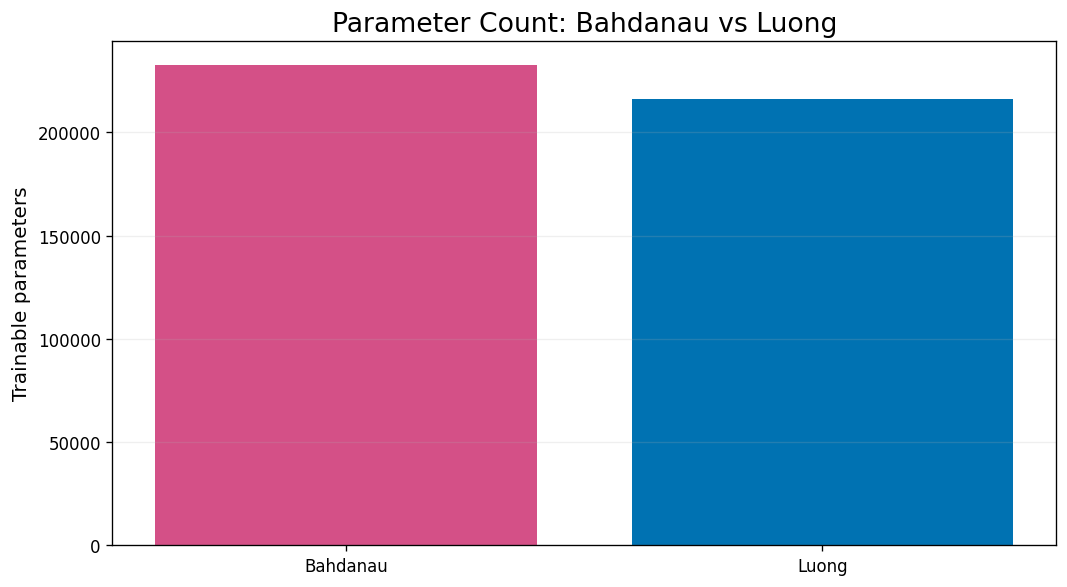

In [95]:
parameter_counts = pd.DataFrame({
    "Model": ["Bahdanau", "Luong"],
    "Parameters": [
        sum(p.numel() for p in bahdanau_model.parameters()),
        sum(p.numel() for p in luong_model.parameters())
    ]
})

display(parameter_counts)

plt.figure(figsize=(9, 5))
plt.bar(
    parameter_counts["Model"],
    parameter_counts["Parameters"],
    color=["#D45087", "#0072B2"]
)
plt.ylabel("Trainable parameters")
plt.title("Parameter Count: Bahdanau vs Luong")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("13_trainable_parameter_count.png")
plt.show()

# 29. Training and validation functions

In [96]:
def run_train_epoch(
    model,
    optimizer,
    loader
):
    model.train()

    losses = []
    accuracies = []

    for source, decoder_inputs, targets in loader:
        source = source.to(DEVICE)
        decoder_inputs = decoder_inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        logits, _, _ = model(
            source,
            decoder_inputs
        )

        loss = criterion(
            logits.reshape(
                -1,
                logits.size(-1)
            ),
            targets.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        acc = token_accuracy(
            logits.detach(),
            targets
        )

        losses.append(
            float(loss.detach().cpu())
        )

        accuracies.append(acc)

    return (
        float(np.mean(losses)),
        float(np.mean(accuracies))
    )

def run_validation_epoch(
    model,
    loader
):
    model.eval()

    losses = []
    accuracies = []

    with torch.no_grad():
        for source, decoder_inputs, targets in loader:
            source = source.to(DEVICE)
            decoder_inputs = decoder_inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            logits, _, _ = model(
                source,
                decoder_inputs
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    logits.size(-1)
                ),
                targets.reshape(-1)
            )

            acc = token_accuracy(
                logits,
                targets
            )

            losses.append(
                float(loss.cpu())
            )

            accuracies.append(acc)

    return (
        float(np.mean(losses)),
        float(np.mean(accuracies))
    )

# 30. Training controller

We store the complete learning history.

Early stopping is based on validation loss.

The best model weights are restored after training.

In [97]:
def fit_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    epochs,
    patience=10
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "epoch_seconds": []
    }

    best_val_loss = float("inf")
    best_state = None
    stale_epochs = 0

    for epoch in range(1, epochs + 1):
        start = time.perf_counter()

        train_loss, train_acc = run_train_epoch(
            model,
            optimizer,
            train_loader
        )

        val_loss, val_acc = run_validation_epoch(
            model,
            val_loader
        )

        duration = time.perf_counter() - start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["epoch_seconds"].append(duration)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_acc={val_acc:.4f} | "
                f"{duration:.2f}s"
            )

        if stale_epochs >= patience:
            print(
                f"Early stopping at epoch {epoch}."
            )
            break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return history

# 31. Train Bahdanau Attention model

In [98]:
bahdanau_start = time.perf_counter()

bahdanau_history = fit_model(
    bahdanau_model,
    bahdanau_optimizer,
    train_loader,
    val_loader,
    EPOCHS
)

bahdanau_training_time = (
    time.perf_counter() - bahdanau_start
)

print(
    "Bahdanau training time:",
    round(bahdanau_training_time, 2),
    "seconds"
)

Epoch 001 | train_loss=4.2266 | val_loss=4.1726 | train_acc=0.0526 | val_acc=0.1333 | 1.77s
Epoch 005 | train_loss=3.0323 | val_loss=3.3026 | train_acc=0.2833 | val_acc=0.2667 | 0.06s
Epoch 010 | train_loss=2.2785 | val_loss=2.8989 | train_acc=0.4576 | val_acc=0.4000 | 0.05s
Epoch 015 | train_loss=1.5993 | val_loss=2.6893 | train_acc=0.6195 | val_acc=0.4333 | 0.05s
Epoch 020 | train_loss=1.0027 | val_loss=2.5520 | train_acc=0.9035 | val_acc=0.4667 | 0.06s
Epoch 025 | train_loss=0.5496 | val_loss=2.5123 | train_acc=0.9821 | val_acc=0.4667 | 0.06s
Epoch 030 | train_loss=0.2806 | val_loss=2.5239 | train_acc=1.0000 | val_acc=0.4667 | 0.06s
Early stopping at epoch 34.
Bahdanau training time: 3.71 seconds


# 32. Train Luong Attention model

In [99]:
luong_start = time.perf_counter()

luong_history = fit_model(
    luong_model,
    luong_optimizer,
    train_loader,
    val_loader,
    EPOCHS
)

luong_training_time = (
    time.perf_counter() - luong_start
)

print(
    "Luong training time:",
    round(luong_training_time, 2),
    "seconds"
)

Epoch 001 | train_loss=4.2059 | val_loss=4.1379 | train_acc=0.0288 | val_acc=0.1333 | 0.07s
Epoch 005 | train_loss=3.0461 | val_loss=3.3066 | train_acc=0.2836 | val_acc=0.2667 | 0.05s
Epoch 010 | train_loss=2.2826 | val_loss=2.8916 | train_acc=0.4482 | val_acc=0.4000 | 0.05s
Epoch 015 | train_loss=1.5918 | val_loss=2.7500 | train_acc=0.6502 | val_acc=0.4333 | 0.06s
Epoch 020 | train_loss=0.9696 | val_loss=2.6631 | train_acc=0.9297 | val_acc=0.4333 | 0.05s
Epoch 025 | train_loss=0.5300 | val_loss=2.6915 | train_acc=0.9821 | val_acc=0.4333 | 0.05s
Epoch 030 | train_loss=0.2736 | val_loss=2.7544 | train_acc=1.0000 | val_acc=0.4333 | 0.05s
Early stopping at epoch 31.
Luong training time: 1.54 seconds


# 33. Save trained model weights

In [100]:
torch.save(
    bahdanau_model.state_dict(),
    "bahdanau_attention_pytorch.pt"
)

torch.save(
    luong_model.state_dict(),
    "luong_attention_pytorch.pt"
)

print("Bahdanau weights saved.")
print("Luong weights saved.")

Bahdanau weights saved.
Luong weights saved.


# 34. Training curves

Every plot is saved into the `images` folder.

Saved: images/14_training_loss_comparison.png


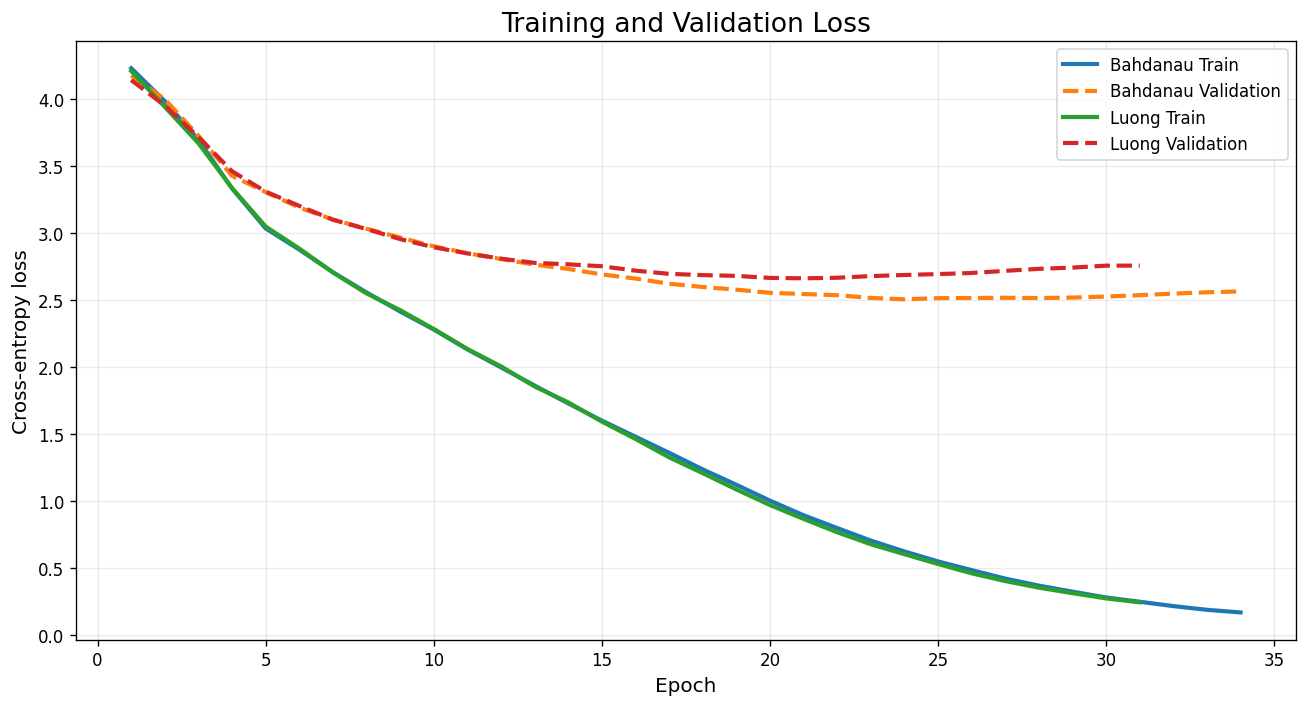

In [101]:
epochs_b = np.arange(
    1,
    len(bahdanau_history["train_loss"]) + 1
)

epochs_l = np.arange(
    1,
    len(luong_history["train_loss"]) + 1
)

plt.figure(figsize=(11, 6))

plt.plot(
    epochs_b,
    bahdanau_history["train_loss"],
    linewidth=2.5,
    label="Bahdanau Train"
)

plt.plot(
    epochs_b,
    bahdanau_history["val_loss"],
    linewidth=2.5,
    linestyle="--",
    label="Bahdanau Validation"
)

plt.plot(
    epochs_l,
    luong_history["train_loss"],
    linewidth=2.5,
    label="Luong Train"
)

plt.plot(
    epochs_l,
    luong_history["val_loss"],
    linewidth=2.5,
    linestyle="--",
    label="Luong Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_fig("14_training_loss_comparison.png")
plt.show()

Saved: images/15_training_accuracy_comparison.png


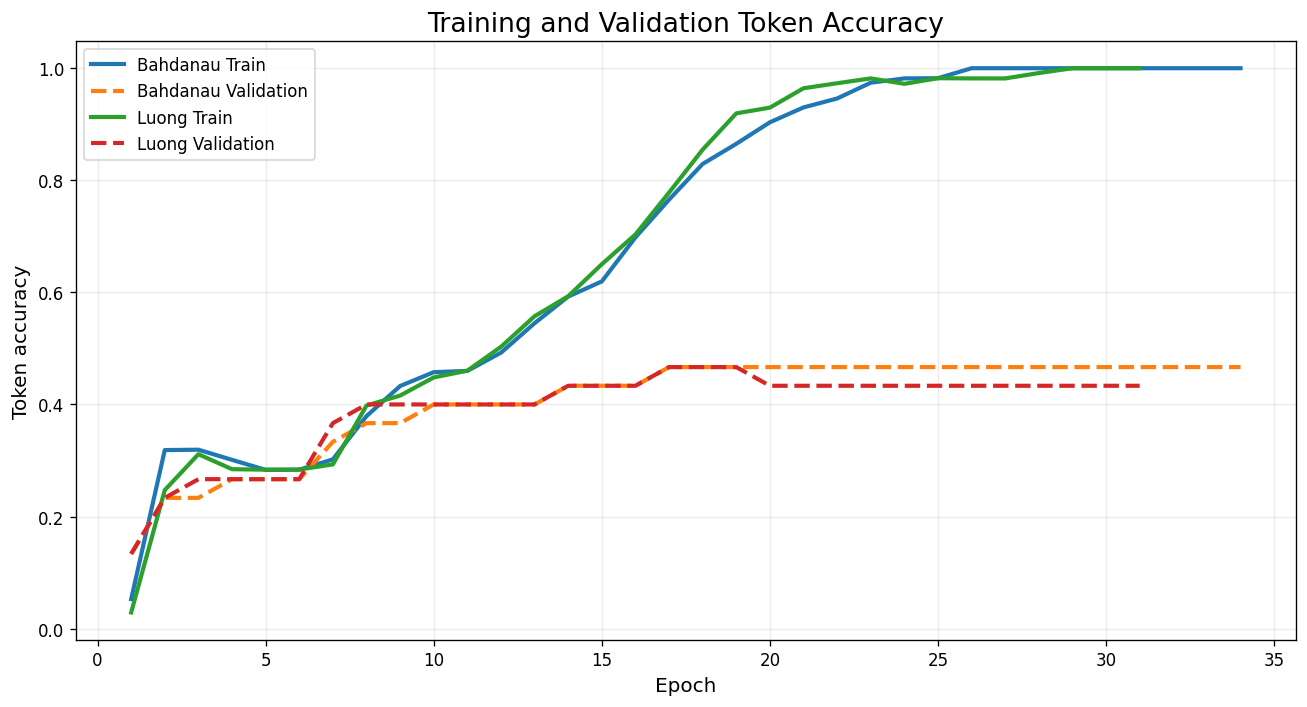

In [102]:
plt.figure(figsize=(11, 6))

plt.plot(
    epochs_b,
    bahdanau_history["train_accuracy"],
    linewidth=2.5,
    label="Bahdanau Train"
)

plt.plot(
    epochs_b,
    bahdanau_history["val_accuracy"],
    linewidth=2.5,
    linestyle="--",
    label="Bahdanau Validation"
)

plt.plot(
    epochs_l,
    luong_history["train_accuracy"],
    linewidth=2.5,
    label="Luong Train"
)

plt.plot(
    epochs_l,
    luong_history["val_accuracy"],
    linewidth=2.5,
    linestyle="--",
    label="Luong Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Token accuracy")
plt.title("Training and Validation Token Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_fig("15_training_accuracy_comparison.png")
plt.show()

Saved: images/16_cumulative_training_time.png


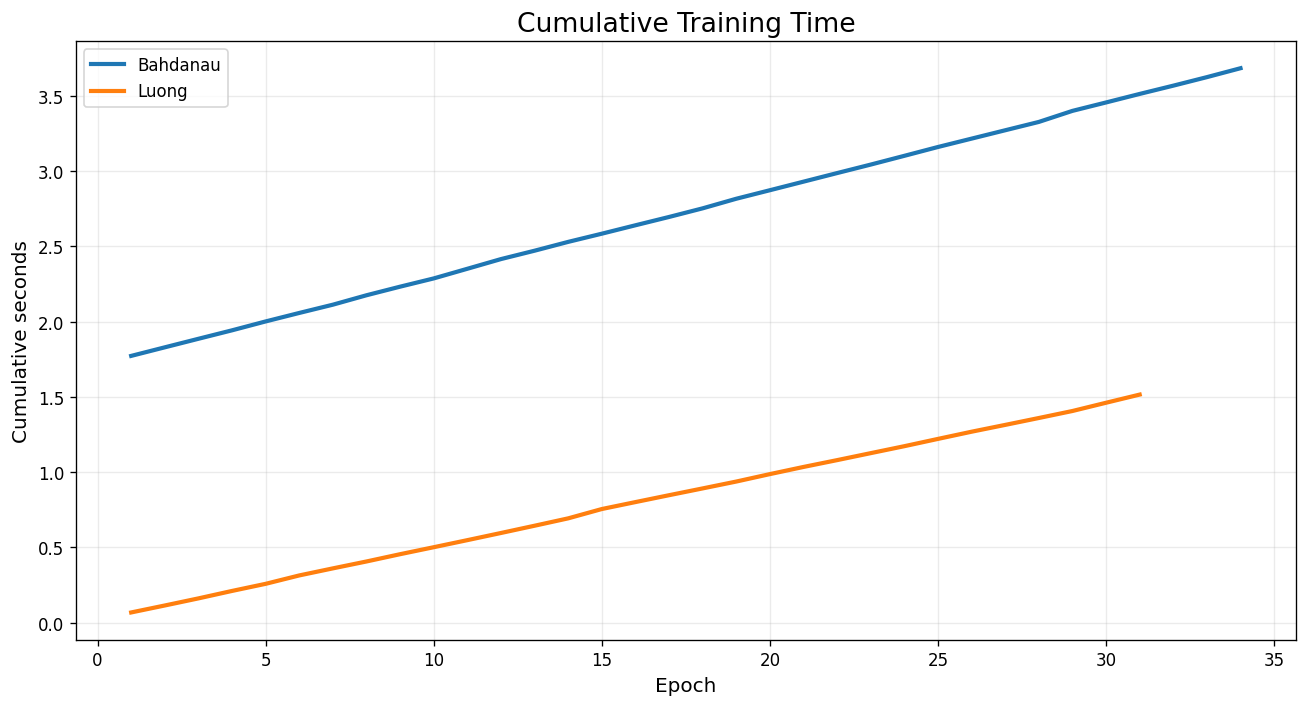

In [103]:
plt.figure(figsize=(11, 6))

plt.plot(
    epochs_b,
    np.cumsum(
        bahdanau_history["epoch_seconds"]
    ),
    linewidth=2.5,
    label="Bahdanau"
)

plt.plot(
    epochs_l,
    np.cumsum(
        luong_history["epoch_seconds"]
    ),
    linewidth=2.5,
    label="Luong"
)

plt.xlabel("Epoch")
plt.ylabel("Cumulative seconds")
plt.title("Cumulative Training Time")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
save_fig("16_cumulative_training_time.png")
plt.show()

In [104]:
def best_epoch(
    history,
    metric,
    lower_is_better=True
):
    values = np.array(history[metric])

    if lower_is_better:
        return int(
            np.argmin(values)
        ) + 1

    return int(
        np.argmax(values)
    ) + 1

training_summary = pd.DataFrame({
    "Model": ["Bahdanau", "Luong"],
    "Best val loss": [
        min(bahdanau_history["val_loss"]),
        min(luong_history["val_loss"])
    ],
    "Best val accuracy": [
        max(bahdanau_history["val_accuracy"]),
        max(luong_history["val_accuracy"])
    ],
    "Best loss epoch": [
        best_epoch(
            bahdanau_history,
            "val_loss",
            True
        ),
        best_epoch(
            luong_history,
            "val_loss",
            True
        )
    ],
    "Best accuracy epoch": [
        best_epoch(
            bahdanau_history,
            "val_accuracy",
            False
        ),
        best_epoch(
            luong_history,
            "val_accuracy",
            False
        )
    ],
    "Training time (s)": [
        bahdanau_training_time,
        luong_training_time
    ]
})

display(training_summary.round(4))

,Model,Best val loss,Best val accuracy,Best loss epoch,Best accuracy epoch,Training time (s)
0,Bahdanau,2.5035,0.4667,24,17,3.7086
1,Luong,2.6602,0.4667,21,17,1.5368


Saved: images/17_best_validation_loss.png


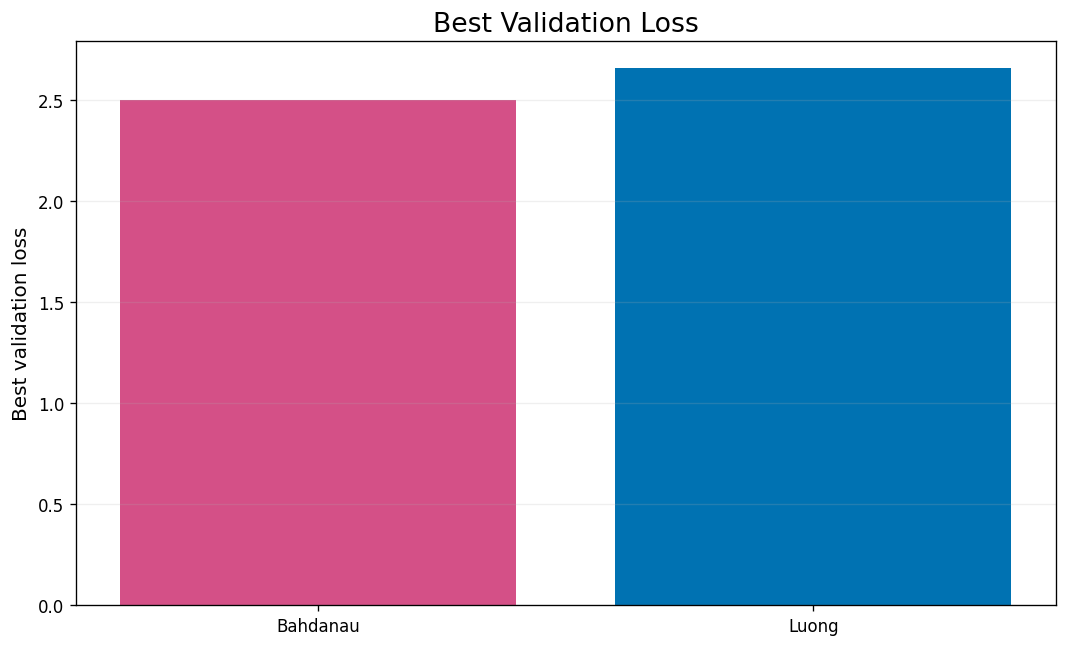

In [105]:
plt.figure(figsize=(9, 5.5))

plt.bar(
    training_summary["Model"],
    training_summary["Best val loss"],
    color=["#D45087", "#0072B2"]
)

plt.ylabel("Best validation loss")
plt.title("Best Validation Loss")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("17_best_validation_loss.png")
plt.show()

Saved: images/18_best_validation_accuracy.png


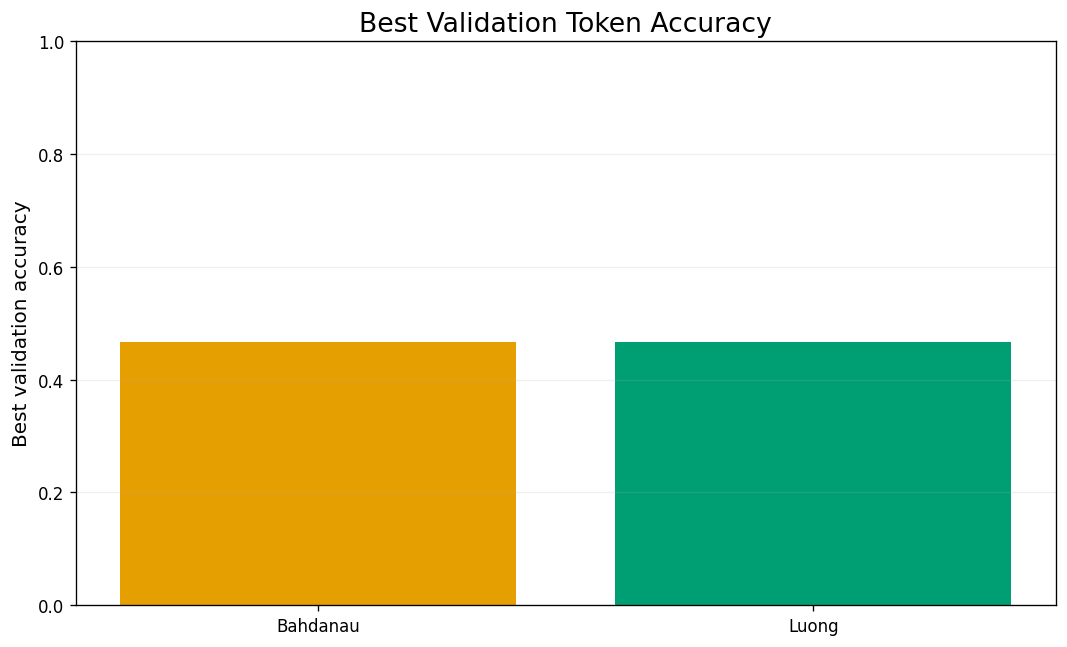

In [106]:
plt.figure(figsize=(9, 5.5))

plt.bar(
    training_summary["Model"],
    training_summary["Best val accuracy"],
    color=["#E69F00", "#009E73"]
)

plt.ylabel("Best validation accuracy")
plt.ylim(0, 1)
plt.title("Best Validation Token Accuracy")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("18_best_validation_accuracy.png")
plt.show()

# 35. Autoregressive inference

Training feeds the correct previous target token.

Inference does not.

The generated prediction is fed back into the decoder:

`SOS → prediction → prediction → ...`

This lets us compare the actual behavior of the trained models.

In [107]:
def prepare_source_tensor(text):
    ids = encode_source(text)

    return torch.tensor(
        [ids],
        dtype=torch.long,
        device=DEVICE
    )

def decode_autoregressive(
    model,
    text,
    max_steps=None
):
    if max_steps is None:
        max_steps = max_tgt_len

    model.eval()

    source = prepare_source_tensor(
        text
    )

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(
            source
        )

        source_mask = (
            source != PAD_ID_EN
        )

        current_token = torch.tensor(
            [SOS_ID],
            dtype=torch.long,
            device=DEVICE
        )

        generated_ids = []
        attention_rows = []
        score_rows = []

        for _ in range(max_steps):
            logits, hidden, weights, scores = (
                model.decoder.step(
                    current_token,
                    hidden,
                    encoder_outputs,
                    source_mask
                )
            )

            next_id = int(
                logits.argmax(dim=-1).item()
            )

            generated_ids.append(
                next_id
            )

            attention_rows.append(
                weights[0].detach().cpu().numpy()
            )

            score_rows.append(
                scores[0].detach().cpu().numpy()
            )

            if next_id == EOS_ID:
                break

            current_token = torch.tensor(
                [next_id],
                dtype=torch.long,
                device=DEVICE
            )

    tokens = [
        hi_id_to_token.get(
            token_id,
            "<UNK>"
        )
        for token_id in generated_ids
        if token_id not in {
            PAD_ID_HI,
            EOS_ID,
            SOS_ID
        }
    ]

    return (
        tokens,
        np.array(attention_rows),
        np.array(score_rows)
    )

# 36. Compare translations on held-out examples

In [108]:
eval_samples = train_df.loc[
    val_indices,
    "english"
].tolist()

if len(eval_samples) == 0:
    eval_samples = [
        "turn on the light",
        "turn off the light",
        "open the door",
        "close the door"
    ]

eval_samples = eval_samples[:8]

prediction_rows = []

for text in eval_samples:
    matches = df.loc[
        df["english"] == text,
        "hindi"
    ]

    expected = matches.iloc[0] if len(matches) else ""

    bah_tokens, _, _ = decode_autoregressive(
        bahdanau_model,
        text
    )

    luo_tokens, _, _ = decode_autoregressive(
        luong_model,
        text
    )

    prediction_rows.append({
        "English": text,
        "Expected": expected,
        "Bahdanau": " ".join(bah_tokens),
        "Luong": " ".join(luo_tokens)
    })

predictions_df = pd.DataFrame(
    prediction_rows
)

display(predictions_df)

,English,Expected,Bahdanau,Luong
0,charge the phone,फ़ोन चार्ज करो,फ़ाइल हटाओ,दरवाज़ा बंद करो
1,close the window,खिड़की बंद रखो,दरवाज़ा बंद करो,ऐप बंद करो
2,turn off the fan,पंखा बंद करो,पंखा चालू करो,पंखा चालू करो
3,open the door,दरवाज़ा खोलो,दरवाज़ा खुला रखो,दरवाज़ा बंद करो
4,study every day,हर दिन पढ़ो,बहुत मेहनत करो,ऐप खोलो
5,turn off the light,रोशनी बंद करो,रोशनी चालू करो,रोशनी चालू करो
6,open the window,खिड़की खोलो,दरवाज़ा खुला रखो,ऐप बंद करो
7,wash your hands,अपने हाथ धोओ,ऐप खोलो,बहुत मेहनत करो


# 37. Translation metrics

Because the dataset is tiny, exact sequence accuracy should not be treated as a production metric.

We use:

- exact match
- token precision
- token recall
- token F1

These are diagnostic metrics for this learning experiment.

In [109]:
def token_overlap_metrics(
    reference,
    prediction
):
    ref = tokenize_hi(
        reference
    )

    pred = prediction.split()

    ref_counter = Counter(ref)
    pred_counter = Counter(pred)

    overlap = sum(
        (ref_counter & pred_counter).values()
    )

    precision = overlap / max(
        len(pred),
        1
    )

    recall = overlap / max(
        len(ref),
        1
    )

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = (
            2 * precision * recall /
            (precision + recall)
        )

    exact = int(
        ref == pred
    )

    return (
        exact,
        precision,
        recall,
        f1
    )

In [110]:
evaluation_rows = []

for _, row in predictions_df.iterrows():
    for model_name in [
        "Bahdanau",
        "Luong"
    ]:
        metrics = token_overlap_metrics(
            row["Expected"],
            row[model_name]
        )

        evaluation_rows.append({
            "Model": model_name,
            "English": row["English"],
            "Expected": row["Expected"],
            "Prediction": row[model_name],
            "Exact": metrics[0],
            "Precision": metrics[1],
            "Recall": metrics[2],
            "F1": metrics[3]
        })

evaluation_df = pd.DataFrame(
    evaluation_rows
)

display(
    evaluation_df.round(4)
)

,Model,English,Expected,Prediction,Exact,Precision,Recall,F1
0,Bahdanau,charge the phone,फ़ोन चार्ज करो,फ़ाइल हटाओ,0,0.0000,0.0000,0.0000
1,Luong,charge the phone,फ़ोन चार्ज करो,दरवाज़ा बंद करो,0,0.3333,0.3333,0.3333
2,Bahdanau,close the window,खिड़की बंद रखो,दरवाज़ा बंद करो,0,0.3333,0.3333,0.3333
3,Luong,close the window,खिड़की बंद रखो,ऐप बंद करो,0,0.3333,0.3333,0.3333
4,Bahdanau,turn off the fan,पंखा बंद करो,पंखा चालू करो,0,0.6667,0.6667,0.6667
5,Luong,turn off the fan,पंखा बंद करो,पंखा चालू करो,0,0.6667,0.6667,0.6667
6,Bahdanau,open the door,दरवाज़ा खोलो,दरवाज़ा खुला रखो,0,0.3333,0.5000,0.4000
7,Luong,open the door,दरवाज़ा खोलो,दरवाज़ा बंद करो,0,0.3333,0.5000,0.4000
8,Bahdanau,study every day,हर दिन पढ़ो,बहुत मेहनत करो,0,0.0000,0.0000,0.0000
9,Luong,study every day,हर दिन पढ़ो,ऐप खोलो,0,0.0000,0.0000,0.0000


In [111]:
sequence_summary = (
    evaluation_df
    .groupby("Model")[
        ["Exact", "Precision", "Recall", "F1"]
    ]
    .mean()
    .reset_index()
)

display(
    sequence_summary.round(4)
)

,Model,Exact,Precision,Recall,F1
0,Bahdanau,0.0,0.2500,0.2708,0.2583
1,Luong,0.0,0.2917,0.3125,0.3000


Saved: images/19_translation_metrics.png


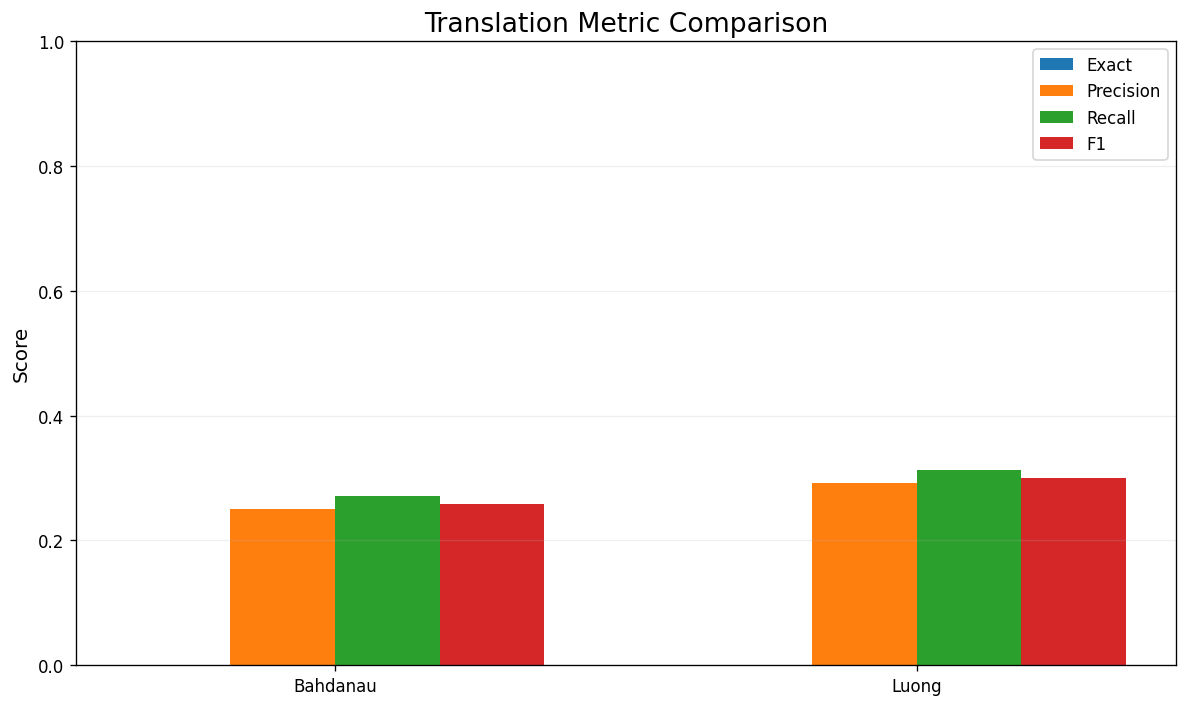

In [112]:
plt.figure(figsize=(10, 6))

x = np.arange(
    len(sequence_summary)
)

width = 0.18

for i, metric in enumerate(
    ["Exact", "Precision", "Recall", "F1"]
):
    plt.bar(
        x + (i - 1.5) * width,
        sequence_summary[metric],
        width=width,
        label=metric
    )

plt.xticks(
    x,
    sequence_summary["Model"]
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Translation Metric Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("19_translation_metrics.png")
plt.show()

# 38. Detailed attention diagnostics

We now examine what each trained model is doing internally.

For each generated target token we calculate:

- attention entropy
- maximum source attention
- source-token winner

These help compare the *shape* of attention, not just final output accuracy.

In [113]:
def attention_entropy_numpy(
    attention_matrix
):
    eps = 1e-12

    return -np.sum(
        attention_matrix *
        np.log(
            attention_matrix + eps
        ),
        axis=1
    )

In [114]:
attention_diagnostic_rows = []

for text in eval_samples:
    _, bah_attn, _ = decode_autoregressive(
        bahdanau_model,
        text
    )

    _, luo_attn, _ = decode_autoregressive(
        luong_model,
        text
    )

    attention_diagnostic_rows.append({
        "English": text,
        "Bahdanau entropy": (
            attention_entropy_numpy(
                bah_attn
            ).mean()
        ),
        "Luong entropy": (
            attention_entropy_numpy(
                luo_attn
            ).mean()
        ),
        "Bahdanau max weight": (
            bah_attn.max(
                axis=1
            ).mean()
        ),
        "Luong max weight": (
            luo_attn.max(
                axis=1
            ).mean()
        )
    })

attention_diagnostics = pd.DataFrame(
    attention_diagnostic_rows
)

display(
    attention_diagnostics.round(4)
)

,English,Bahdanau entropy,Luong entropy,Bahdanau max weight,Luong max weight
0,charge the phone,0.8032,0.9162,0.5901,0.5707
1,close the window,0.7791,0.9165,0.5308,0.5598
2,turn off the fan,0.7567,1.0567,0.6706,0.5406
3,open the door,0.8326,0.8983,0.5904,0.5605
4,study every day,1.0734,1.0781,0.4276,0.3945
5,turn off the light,0.8017,1.0185,0.6313,0.5742
6,open the window,0.8781,0.9095,0.5182,0.5643
7,wash your hands,0.6504,1.0926,0.7825,0.3718


In [115]:
attention_summary = pd.DataFrame({
    "Model": [
        "Bahdanau",
        "Luong"
    ],
    "Average attention entropy": [
        attention_diagnostics[
            "Bahdanau entropy"
        ].mean(),
        attention_diagnostics[
            "Luong entropy"
        ].mean()
    ],
    "Average maximum attention": [
        attention_diagnostics[
            "Bahdanau max weight"
        ].mean(),
        attention_diagnostics[
            "Luong max weight"
        ].mean()
    ]
})

display(
    attention_summary.round(4)
)

,Model,Average attention entropy,Average maximum attention
0,Bahdanau,0.8219,0.5927
1,Luong,0.9858,0.5170


Saved: images/20_attention_entropy.png


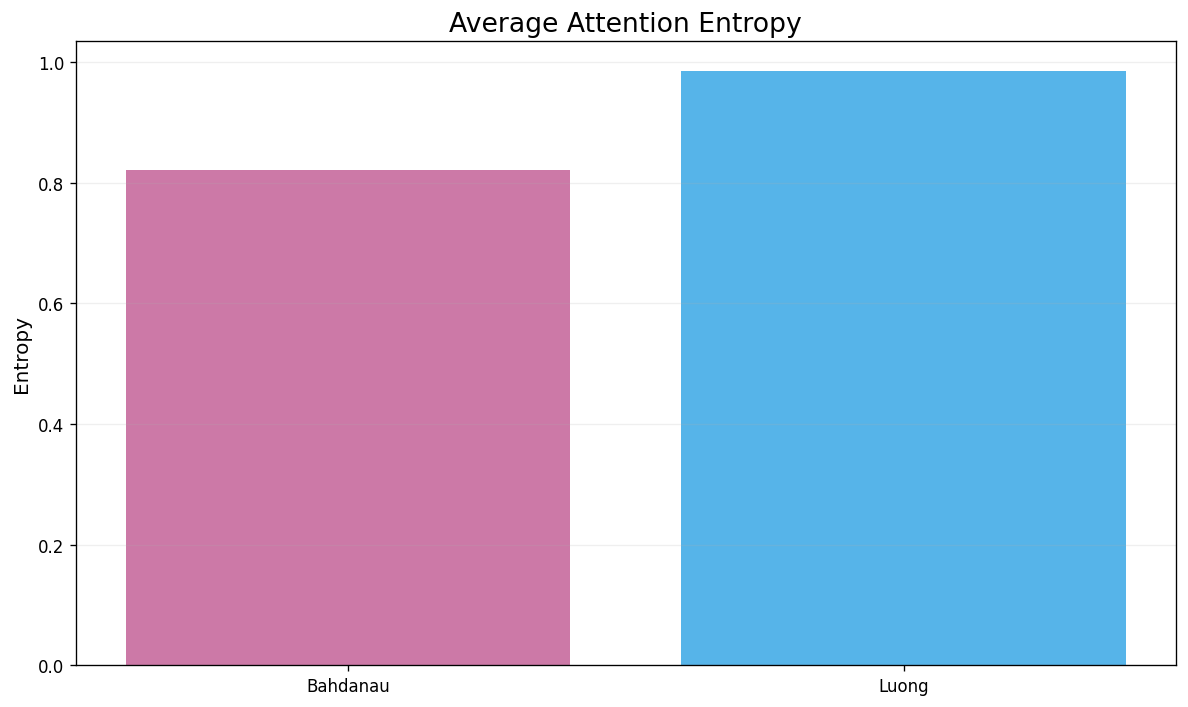

In [116]:
plt.figure(figsize=(10, 6))

plt.bar(
    attention_summary["Model"],
    attention_summary[
        "Average attention entropy"
    ],
    color=["#CC79A7", "#56B4E9"]
)

plt.ylabel("Entropy")
plt.title("Average Attention Entropy")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("20_attention_entropy.png")
plt.show()

Saved: images/21_attention_focus.png


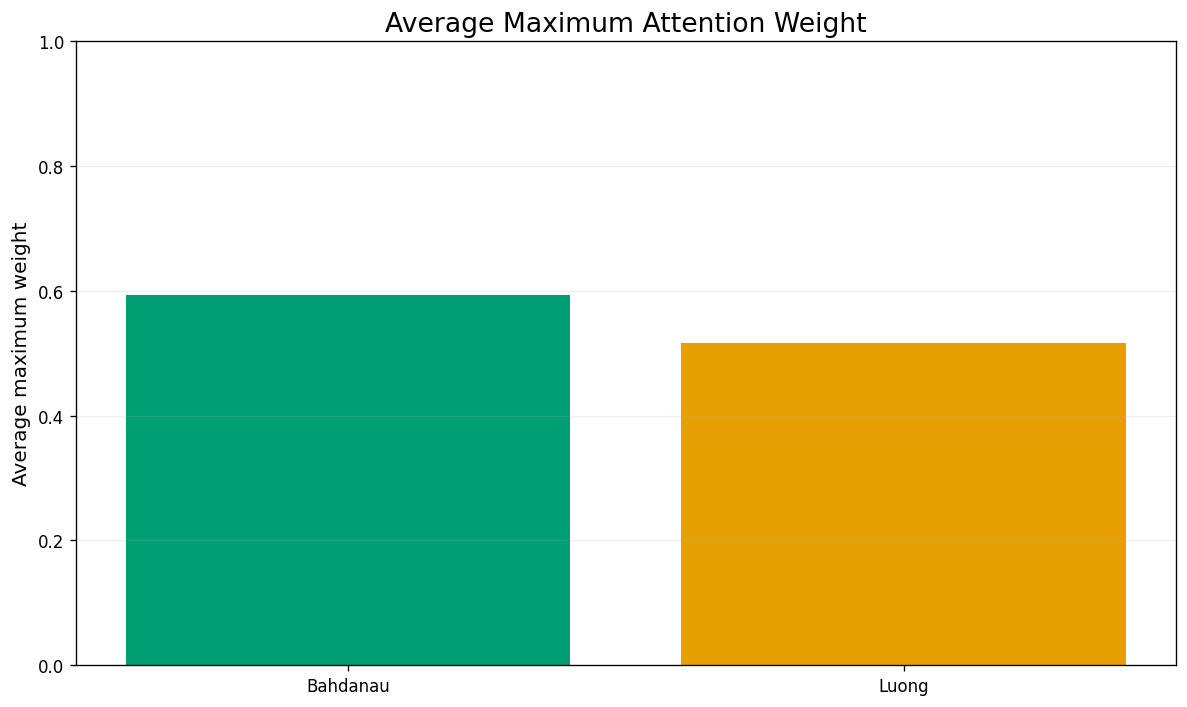

In [117]:
plt.figure(figsize=(10, 6))

plt.bar(
    attention_summary["Model"],
    attention_summary[
        "Average maximum attention"
    ],
    color=["#009E73", "#E69F00"]
)

plt.ylabel("Average maximum weight")
plt.ylim(0, 1)
plt.title("Average Maximum Attention Weight")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("21_attention_focus.png")
plt.show()

# 39. Direct attention comparison for one sentence

In [118]:
comparison_sentence = (
    "turn off the light"
)

matches = df.loc[
    df["english"] == comparison_sentence,
    "hindi"
]

expected_sentence = (
    matches.iloc[0]
    if len(matches)
    else ""
)

bah_output, bah_inf_attention, bah_scores = (
    decode_autoregressive(
        bahdanau_model,
        comparison_sentence
    )
)

luo_output, luo_inf_attention, luo_scores = (
    decode_autoregressive(
        luong_model,
        comparison_sentence
    )
)

print(
    "Source:",
    comparison_sentence
)

print(
    "Expected:",
    expected_sentence
)

print(
    "Bahdanau:",
    " ".join(bah_output)
)

print(
    "Luong:",
    " ".join(luo_output)
)

Source: turn off the light
Expected: रोशनी बंद करो
Bahdanau: रोशनी चालू करो
Luong: रोशनी चालू करो


In [119]:
def plot_attention_matrix(
    attention,
    source_tokens,
    target_tokens,
    title,
    cmap,
    filename
):
    plt.figure(figsize=(10, 6))

    im = plt.imshow(
        attention,
        cmap=cmap,
        aspect="auto"
    )

    plt.xticks(
        np.arange(
            len(source_tokens)
        ),
        source_tokens,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        np.arange(
            len(target_tokens)
        ),
        target_tokens
    )

    plt.xlabel(
        "English source token"
    )

    plt.ylabel(
        "Generated target token"
    )

    plt.title(title)

    plt.colorbar(
        im,
        label="Attention weight"
    )

    for i in range(
        attention.shape[0]
    ):
        for j in range(
            attention.shape[1]
        ):
            plt.text(
                j,
                i,
                f"{attention[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

    plt.tight_layout()
    save_fig(filename)
    plt.show()

/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

Saved: images/22_bahdanau_inference_attention.png


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib

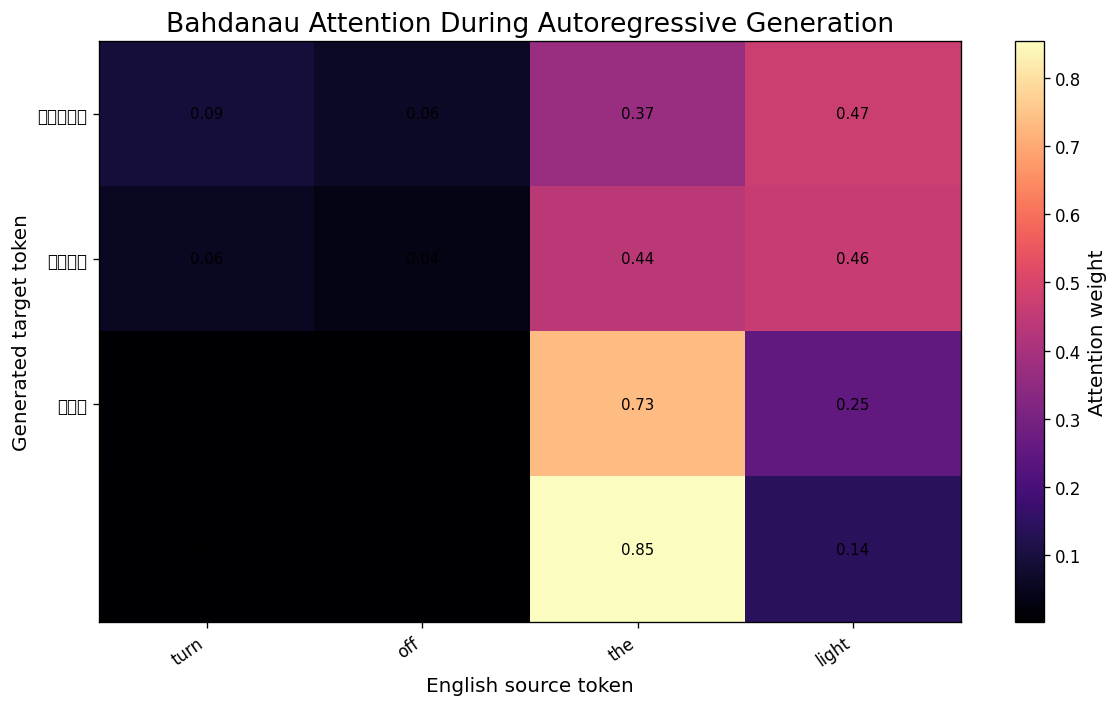

In [120]:
source_tokens_comparison = tokenize_en(
    comparison_sentence
)

plot_attention_matrix(
    bah_inf_attention,
    source_tokens_comparison,
    bah_output,
    "Bahdanau Attention During Autoregressive Generation",
    "magma",
    "22_bahdanau_inference_attention.png"
)

/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

Saved: images/23_luong_inference_attention.png


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib

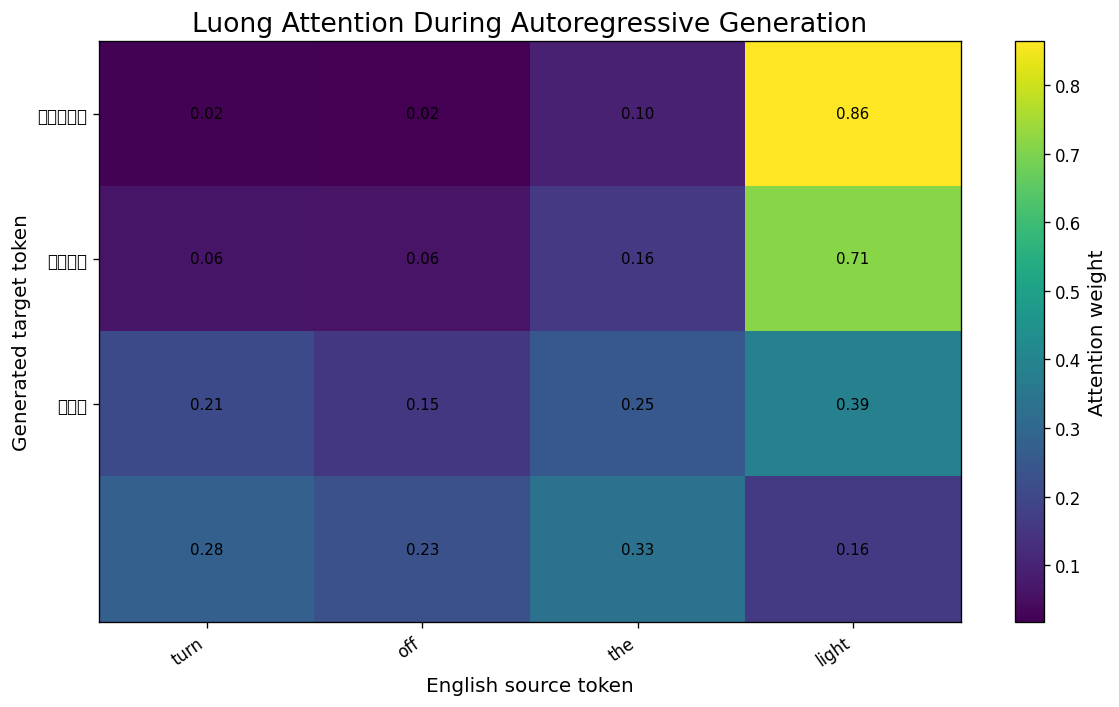

In [121]:
plot_attention_matrix(
    luo_inf_attention,
    source_tokens_comparison,
    luo_output,
    "Luong Attention During Autoregressive Generation",
    "viridis",
    "23_luong_inference_attention.png"
)

/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_814/2795840056.py:63: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

Saved: images/24_attention_difference.png


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib

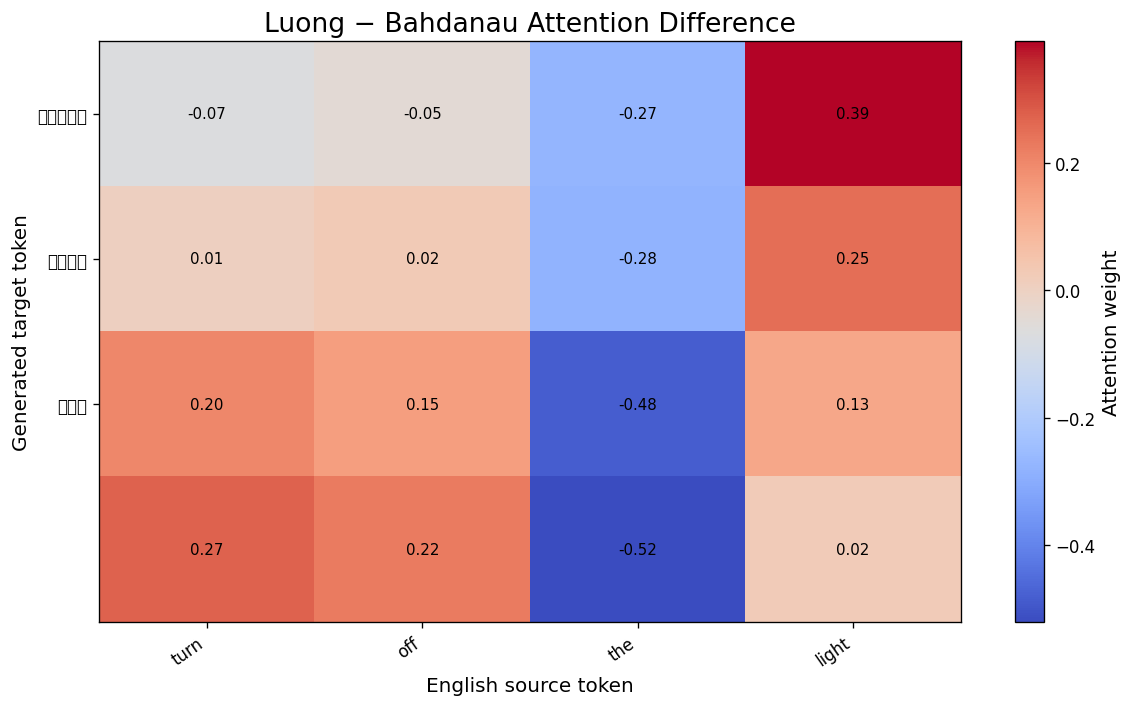

In [122]:
rows = min(
    bah_inf_attention.shape[0],
    luo_inf_attention.shape[0]
)

attention_delta = (
    luo_inf_attention[:rows] -
    bah_inf_attention[:rows]
)

target_labels = bah_output[:rows]

plot_attention_matrix(
    attention_delta,
    source_tokens_comparison,
    target_labels,
    "Luong − Bahdanau Attention Difference",
    "coolwarm",
    "24_attention_difference.png"
)

# 40. Source-token importance

A useful summary is to add attention received by each source word over the full generated sequence.

This gives a single importance score per source position.

In [123]:
bah_source_importance = (
    bah_inf_attention.sum(axis=0)
)

luo_source_importance = (
    luo_inf_attention.sum(axis=0)
)

importance_df = pd.DataFrame({
    "Source token": source_tokens_comparison,
    "Bahdanau": bah_source_importance,
    "Luong": luo_source_importance
})

display(
    importance_df.round(4)
)

,Source token,Bahdanau,Luong
0,turn,0.1637,0.5710
1,off,0.1082,0.4623
2,the,2.3965,0.8403
3,light,1.3316,2.1264


Saved: images/25_source_token_importance.png


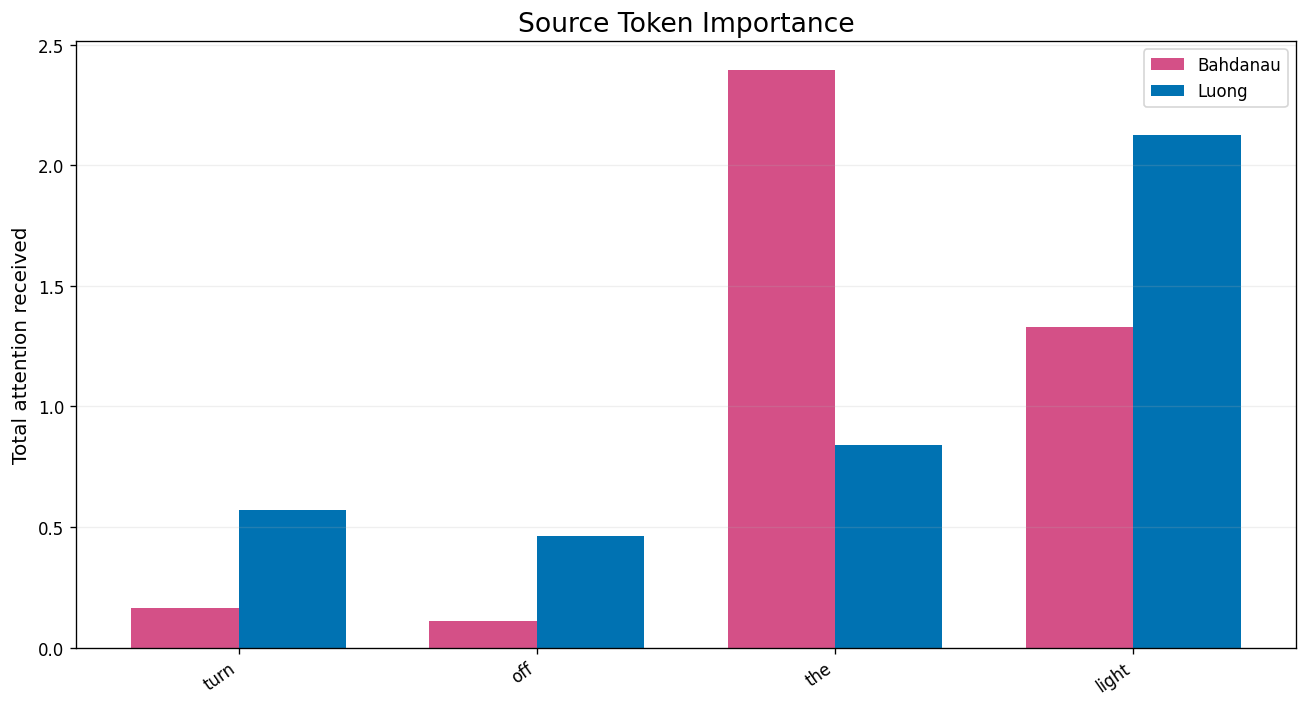

In [124]:
x = np.arange(
    len(source_tokens_comparison)
)

width = 0.36

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    bah_source_importance,
    width=width,
    label="Bahdanau",
    color="#D45087"
)

plt.bar(
    x + width/2,
    luo_source_importance,
    width=width,
    label="Luong",
    color="#0072B2"
)

plt.xticks(
    x,
    source_tokens_comparison,
    rotation=35,
    ha="right"
)

plt.ylabel(
    "Total attention received"
)

plt.title(
    "Source Token Importance"
)

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("25_source_token_importance.png")
plt.show()

# 41. Model comparison table

The final comparison combines:

### Training
- best validation loss
- best validation accuracy
- training time

### Model size
- trainable parameters

### Translation
- exact match
- precision
- recall
- F1

### Attention behavior
- entropy
- maximum attention weight

In [125]:
comparison = pd.DataFrame({
    "Metric": [
        "Best validation loss",
        "Best validation accuracy",
        "Training time (s)",
        "Parameter count",
        "Exact match",
        "Token precision",
        "Token recall",
        "Token F1",
        "Attention entropy",
        "Maximum attention weight"
    ],
    "Bahdanau": [
        training_summary.loc[
            training_summary["Model"]
            == "Bahdanau",
            "Best val loss"
        ].iloc[0],
        training_summary.loc[
            training_summary["Model"]
            == "Bahdanau",
            "Best val accuracy"
        ].iloc[0],
        bahdanau_training_time,
        parameter_counts.loc[
            parameter_counts["Model"]
            == "Bahdanau",
            "Parameters"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Bahdanau",
            "Exact"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Bahdanau",
            "Precision"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Bahdanau",
            "Recall"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Bahdanau",
            "F1"
        ].iloc[0],
        attention_summary.loc[
            attention_summary["Model"]
            == "Bahdanau",
            "Average attention entropy"
        ].iloc[0],
        attention_summary.loc[
            attention_summary["Model"]
            == "Bahdanau",
            "Average maximum attention"
        ].iloc[0]
    ],
    "Luong": [
        training_summary.loc[
            training_summary["Model"]
            == "Luong",
            "Best val loss"
        ].iloc[0],
        training_summary.loc[
            training_summary["Model"]
            == "Luong",
            "Best val accuracy"
        ].iloc[0],
        luong_training_time,
        parameter_counts.loc[
            parameter_counts["Model"]
            == "Luong",
            "Parameters"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Luong",
            "Exact"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Luong",
            "Precision"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Luong",
            "Recall"
        ].iloc[0],
        sequence_summary.loc[
            sequence_summary["Model"]
            == "Luong",
            "F1"
        ].iloc[0],
        attention_summary.loc[
            attention_summary["Model"]
            == "Luong",
            "Average attention entropy"
        ].iloc[0],
        attention_summary.loc[
            attention_summary["Model"]
            == "Luong",
            "Average maximum attention"
        ].iloc[0]
    ]
})

display(
    comparison.round(4)
)

,Metric,Bahdanau,Luong
0,Best validation loss,2.5035,2.6602
1,Best validation accuracy,0.4667,0.4667
2,Training time (s),3.7086,1.5368
3,Parameter count,232645.0000,216133.0000
4,Exact match,0.0000,0.0000
5,Token precision,0.2500,0.2917
6,Token recall,0.2708,0.3125
7,Token F1,0.2583,0.3000
8,Attention entropy,0.8219,0.9858
9,Maximum attention weight,0.5927,0.5170


Saved: images/26_overall_score_comparison.png


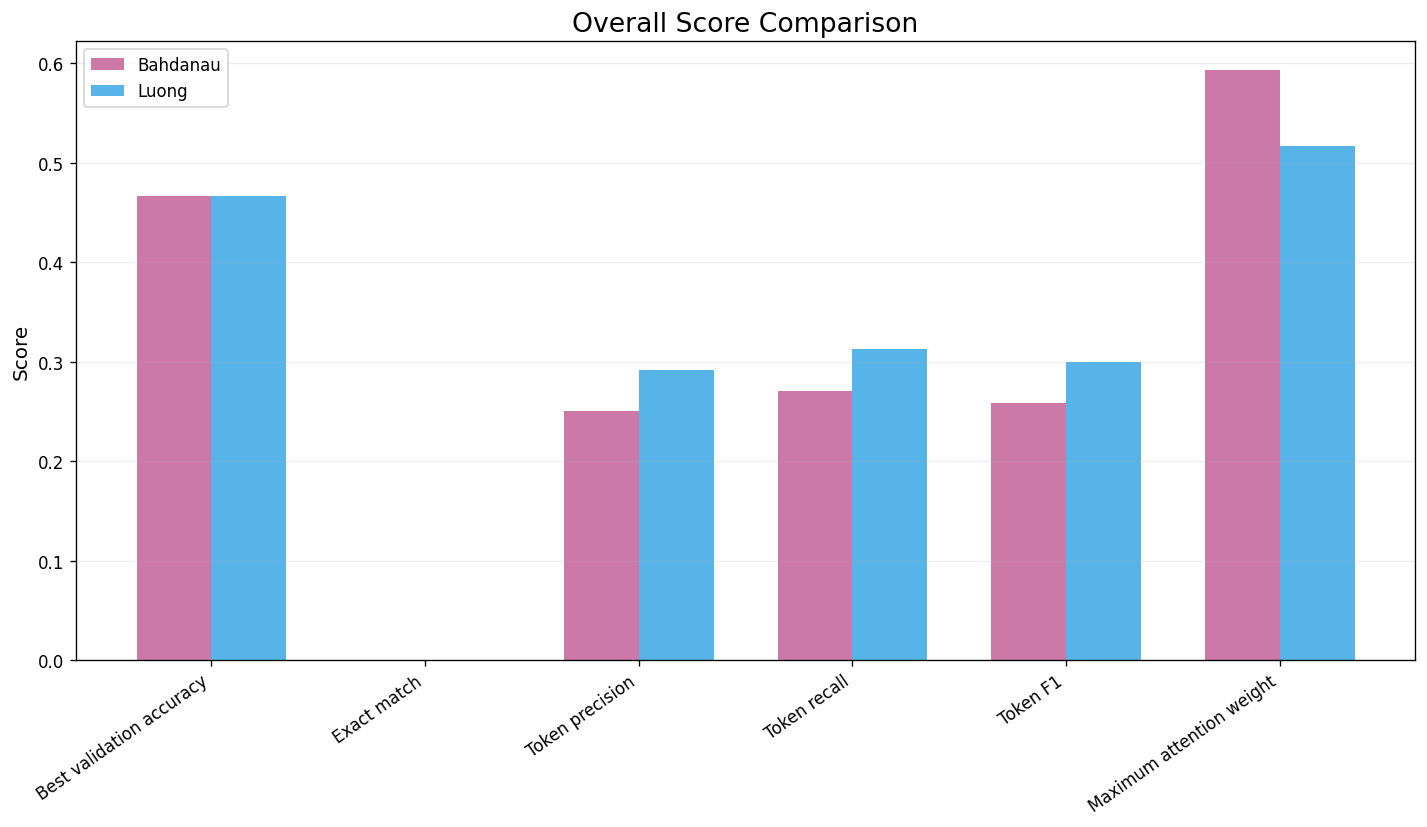

In [126]:
score_metrics = [
    "Best validation accuracy",
    "Exact match",
    "Token precision",
    "Token recall",
    "Token F1",
    "Maximum attention weight"
]

plot_df = comparison[
    comparison["Metric"].isin(
        score_metrics
    )
].copy()

x = np.arange(
    len(plot_df)
)

width = 0.35

plt.figure(figsize=(12, 7))

plt.bar(
    x - width/2,
    plot_df["Bahdanau"],
    width=width,
    label="Bahdanau",
    color="#CC79A7"
)

plt.bar(
    x + width/2,
    plot_df["Luong"],
    width=width,
    label="Luong",
    color="#56B4E9"
)

plt.xticks(
    x,
    plot_df["Metric"],
    rotation=35,
    ha="right"
)

plt.ylabel("Score")
plt.title("Overall Score Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("26_overall_score_comparison.png")
plt.show()

Saved: images/27_total_training_time.png


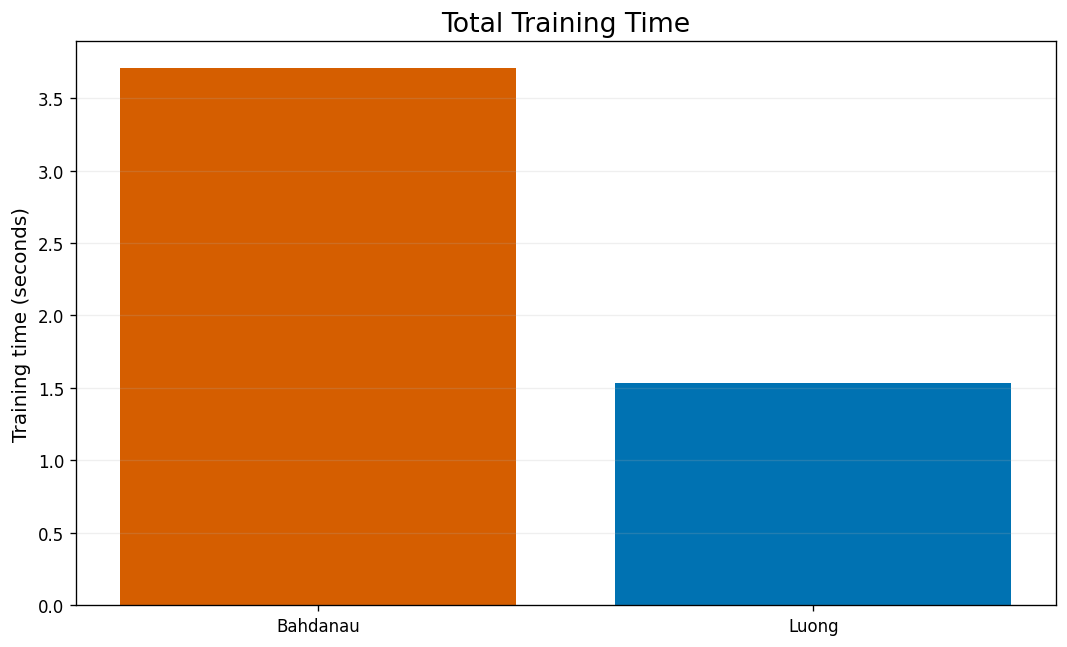

In [127]:
plt.figure(figsize=(9, 5.5))

plt.bar(
    ["Bahdanau", "Luong"],
    [
        bahdanau_training_time,
        luong_training_time
    ],
    color=["#D55E00", "#0072B2"]
)

plt.ylabel(
    "Training time (seconds)"
)

plt.title(
    "Total Training Time"
)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_fig("27_total_training_time.png")
plt.show()

# 42. Detailed interpretation

## Bahdanau

Bahdanau attention uses a learned compatibility function.

This adds parameters and a nonlinear transformation to the scoring calculation.

Its strength is expressive alignment modeling.

## Luong

Luong dot-product attention uses direct similarity.

This makes the scoring calculation simpler and often cheaper.

Its alignment mechanism is much more compact.

## How to decide which one won

Do not use only one number.

Read the experiment across:

**quality**
→ validation loss, token accuracy, translation F1

**efficiency**
→ training time, parameter count

**behavior**
→ entropy, attention focus, heatmaps

A model with slightly worse training loss may still be attractive if it trains substantially faster and produces comparable translations.

Likewise, sharper attention does not automatically mean better translation.

# 43. Important experimental limitation

This dataset contains only 40 short sentence pairs.

That makes it ideal for:

- learning the mechanism
- checking tensor dimensions
- visualizing attention
- understanding training
- comparing architectures

It is **not** sufficient for:

- real machine-translation benchmarking
- claiming one attention mechanism is universally superior
- estimating production translation quality
- comparing against Transformers or modern translation systems

The numerical results are useful as a laboratory demonstration, not as a scientific benchmark.

In [128]:
results_dir = Path(
    "attention_results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

comparison.to_csv(
    results_dir / "model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

predictions_df.to_csv(
    results_dir / "sample_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

evaluation_df.to_csv(
    results_dir / "sequence_evaluation.csv",
    index=False,
    encoding="utf-8-sig"
)

training_summary.to_csv(
    results_dir / "training_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

attention_summary.to_csv(
    results_dir / "attention_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

importance_df.to_csv(
    results_dir / "source_token_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Results saved to:",
    results_dir.resolve()
)

Results saved to: /content/attention_results


In [129]:
saved_images = sorted(
    IMAGES_DIR.glob("*.png")
)

print(
    "Saved graphs:",
    len(saved_images)
)

for image_path in saved_images:
    print(
        image_path.name
    )

Saved graphs: 42
13_trainable_parameter_count.png
14_training_loss_comparison.png
15_training_accuracy_comparison.png
16_cumulative_training_time.png
17_best_validation_loss.png
18_best_validation_accuracy.png
19_translation_metrics.png
20_attention_entropy.png
21_attention_focus.png
22_bahdanau_inference_attention.png
23_luong_inference_attention.png
24_attention_difference.png
25_source_token_importance.png
26_overall_score_comparison.png
27_total_training_time.png
auto_plot_11.png
auto_plot_16.png
auto_plot_26.png
auto_plot_27.png
auto_plot_30.png
auto_plot_35.png
auto_plot_41.png
auto_plot_42.png
auto_plot_44.png
auto_plot_59.png
auto_plot_60.png
auto_plot_61.png
auto_plot_62.png
auto_plot_63.png
auto_plot_67.png
auto_plot_69.png
auto_plot_70.png
auto_plot_71.png
auto_plot_74.png
auto_plot_75.png
auto_plot_78.png
auto_plot_79.png
auto_plot_84.png
auto_plot_87.png
auto_plot_9.png
auto_plot_91.png
auto_plot_96.png


In [130]:
final_checks = {
    "Bahdanau trained": len(bahdanau_history["train_loss"]) > 0,
    "Luong trained": len(luong_history["train_loss"]) > 0,
    "Bahdanau weights saved": Path(
        "bahdanau_attention_pytorch.pt"
    ).exists(),
    "Luong weights saved": Path(
        "luong_attention_pytorch.pt"
    ).exists(),
    "Comparison table created": len(comparison) > 0,
    "Graphs saved": len(
        list(IMAGES_DIR.glob("*.png"))
    ) > 0
}

for key, value in final_checks.items():
    print(
        f"{key}: {value}"
    )

assert all(
    final_checks.values()
)

print(
    "✓ Full training experiment completed."
)

Bahdanau trained: True
Luong trained: True
Bahdanau weights saved: True
Luong weights saved: True
Comparison table created: True
Graphs saved: True
✓ Full training experiment completed.


# 44. Final takeaway

The experiment now gives you a complete path from theory to trained models:

`dataset`

→ `tokenization`

→ `encoder`

→ `decoder`

→ `attention scores`

→ `softmax weights`

→ `context vectors`

→ `training`

→ `validation`

→ `autoregressive generation`

→ `attention visualization`

→ `quantitative comparison`

That is much closer to a real deep-learning project than a formula-only demonstration.

The central comparison remains:

### Bahdanau

`learned nonlinear compatibility`

versus

### Luong

`direct dot-product compatibility`

while everything else is intentionally kept as similar as practical.